# Augmented-Reference vOTU-Block Activity

This notebook consumes the single combined block selection from notebook 09 and
calculates block-versus-nonproviral-host coverage using mapping against the unified
2018-plus-source-isolate reference.


## Notebook Setup

A block is called active in a sample when it meets all PropagAtE-style criteria:
mean coverage >=1x, breadth >=0.80 at 1x, block:host mean-coverage ratio >=4,
Cohen's d >=0.70, after masking 150 bp at retained-contig ends. This is a
PropagAtE-style implementation based on the mapped-depth data. The host
background is the eligible bacterial-genome sequence outside the union of
all explicit geNomad `Provirus` intervals. Any tested vOTU-block sequence
outside those intervals is also excluded from its own background.

## Host-contig filter

09 first keeps only bacterial-reference contigs at least 100 kb long with <80%
merged geNomad viral coverage. This notebook reads that explicit 09 eligibility
table, so its host layouts, coverage backgrounds, and activity calls use the
same reference-contig set as vOTU-block selection.


In [1]:
# Load core libraries
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import math
import re
import gc
import hashlib
import json
import os
import subprocess

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory

plt.ioff()
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "svg.fonttype": "none",
})
from scipy.ndimage import gaussian_filter1d
import time


In [2]:
# Define paths, samples, thresholds, and plotting settings
VIRAL_FRACTION_DIR = Path("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION")
VIRAL_WORLD_DIR = VIRAL_FRACTION_DIR.parent
BACTERIAL_FRACTION_DIR = VIRAL_WORLD_DIR / "BACTERIAL_FRACTION"
MAPPING_DIR = VIRAL_FRACTION_DIR / "06_MAPPING"
REFERENCES_DIR = MAPPING_DIR / "REFERENCES"
SPLIT_DEPTH_DIR = REFERENCES_DIR / "STRAINS_IN_MICROBIAL_AUGMENTED_SELECTED_SPLIT"
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / "FIGURES_AND_TABLES"

SAMPLING = "tot"
REFERENCE_STEM = "strains_in_microbial_fraction_2018_augmented_with_phage_source_isolates"
MAPPING_REFERENCE_PREFIX = REFERENCE_STEM
PREPARE_SELECTED_SPLIT_DEPTH = True
# Parallelize independent sample scans. This step is disk-I/O limited;
# reduce to 1-2 workers if the mapping files are on shared or slow storage.
SPLIT_DEPTH_WORKERS = 36
RUN_INDEPENDENT_PROVIRUS_ACTIVITY = True
# FASTA extraction is lightweight; clustering is opt-in because it runs all-vs-all BLAST.
RUN_INDEPENDENT_PROVIRUS_CLUSTERING = True
PROVIRUS_CLUSTERING_THREADS = 64
TOP_N_GENOMES = 0
INCLUDE_CURATED_VOTU_BLOCK_GENOMES = True
INCLUDE_BLAST_VOTU_BLOCKS = True
PLOT_WORKERS = 36
NONPROVIRAL_ACTIVITY_WORKERS = 8
# Set this to True only when you want the large 36-sample per-genome coverage-profile SVGs.
# Activity calculations, tables, and compact summary figures still run when this is False.
MAKE_PER_GENOME_COVERAGE_PLOTS = True
PLOT_AVOTU_CATEGORIES = {"ubiquitous"}
SAVE_SVG = True
SAVE_PNG = False
# Rank the top genomes by a genome-level RPKM across all eligible host contigs.
# Within each sample this is a contig-length-weighted mean RPKM, equivalent to
# all eligible-contig reads / eligible-contig kb / library reads in millions.
# sum_genome_rpkm adds that genome RPKM across the 36 samples for ranking.
# single_sample_genome_rpkm instead ranks by the highest one-sample genome RPKM.
# The two *_contig_rpkm modes are retained only to inspect the former max-contig ranking.
RPKM_RANKING_MODE = "sum_genome_rpkm"
# These filters select only the extra top-RPKM genome profiles. They do not remove
# 09-selected vOTU-block genomes or alter any Notebook 10 PropagAtE-style activity calls.
TOP_RPKM_PROKARYOTIC_SUPERKINGDOMS = ["Bacteria", "Archaea"]
# A top-RPKM genome must reach >=10% breadth in at least one of the 36 samples.
# This rejects a genome whose high signal is confined to a narrow mapping hotspot.
TOP_RPKM_DISPLAY_MIN_BREADTH_PERCENT = 10.0
# Use the same bacterial-host contig screen as 09 before calculating host coverage.
# A contig must be >=100 kb and have <80% merged geNomad viral coverage.
MIN_REFERENCE_CONTIG_LENGTH = 100_000
MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION = 0.80
PLOT_BIN_SIZE = 1_000
# Plotting only: retain the 1-kb profile in gray and overlay a 10-kb Gaussian smooth.
# Activity statistics continue to use unsmoothed base-level coverage.
PROFILE_GAUSSIAN_SIGMA_BP = 10_000
PROFILE_RAW_COLOR = "#BDBDBD"
PROFILE_RAW_ALPHA = 0.55
PROFILE_SMOOTH_COLOR = "#7A5195"
PROFILE_ACTIVE_BLOCK_COLOR = "#C7B6E2"
PROFILE_ACTIVE_BLOCK_EDGE_COLOR = "#6A3D9A"
PROFILE_ACTIVE_BLOCK_ALPHA = 0.14
PROFILE_INACTIVE_BLOCK_COLOR = "#D9D9D9"
PROFILE_INACTIVE_BLOCK_EDGE_COLOR = "#8C8C8C"
PROFILE_INACTIVE_BLOCK_ALPHA = 0.08
Y_SCALE_MODE = "asinh"
LOG10_PSEUDOCOUNT = 1e-8
ASINH_COFACTOR = 1.0
LINEAR_CLIP_QUANTILE = 0.995
USE_T_COVSTATS = False
EPSILON = 1e-12
SAVE_PER_GENOME_BINNED_PROFILES = False
SAVE_COMBINED_BINNED_PROFILES = False
# Keep the geNomad, curated-vOTU, and BLAST annotation tracks together at the top of each sample panel.
ANNOTATION_TRACK_TOP = 0.965
ANNOTATION_TRACK_HEIGHT = 0.030
ANNOTATION_TRACK_GAP = 0.018
# Show one compact metric line per curated vOTU block in the right plot margin.
# cov is mean block coverage, br is coverage breadth, FC is block:host fold change, and d is Cohen's d.
SHOW_CURATED_VOTU_METRICS = True
CURATED_VOTU_METRICS_FONT_SIZE = 4.8
CURATED_VOTU_BLOCK_LABEL_FONT_SIZE = 4.6
CURATED_VOTU_METRICS_LINE_HEIGHT = 0.09
PLOT_RIGHT_MARGIN_WITH_VOTU_METRICS = 0.79

VOTU_MIN_PIDENT = 90.0
VOTU_MIN_ALIGNMENT_LENGTH = 1_000
VOTU_MIN_QUERY_COVERAGE = 0.10
VOTU_MERGE_DISTANCE_BP = 1_000
VOTU_LABEL_LIMIT = 5
# PropagAtE-compatible curated-block activity thresholds.
VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE = 1.0
VOTU_REGION_ACTIVE_MIN_BREADTH = 0.80
VOTU_REGION_ACTIVE_MIN_FOLD_CHANGE = 4.0
VOTU_REGION_ACTIVE_MIN_COHEN_D = 0.70
VOTU_REGION_EDGE_MASK_BP = 150
AVOTU_CATEGORY_ORDER = ["ubiquitous", "core", "common", "unique", "non_aVOTU"]
AVOTU_LEGEND_CATEGORY_ORDER = ["unique", "common", "core", "ubiquitous", "non_aVOTU"]
AVOTU_CATEGORY_COLORS = {
    "unique": "#6f6f6f",
    "common": "#cfcfcf",
    "core": "#36c99c",
    "ubiquitous": "#f4c400",
    "non_aVOTU": "#ffffff",
}
AVOTU_CATEGORY_LABELS = {
    "unique": "Low overlap/Unique avOTU",
    "common": "Common avOTU",
    "core": "Core avOTU",
    "ubiquitous": "Ubiquitous avOTU",
    "non_aVOTU": "curated vOTU, not in avOTU list",
}
GENOMAD_PROPHAGE_FACE_COLOR = "#ff3b30"
GENOMAD_PROPHAGE_EDGE_COLOR = "#b00020"
BLAST_VOTU_BRACKET_COLOR = "#303030"
BLAST_VOTU_BRACKET_LINEWIDTH = 0.55

OUTPUT_PREFIX = f"top{TOP_N_GENOMES}_rpkm_plus_curated_votu_block_genomes"
OUTPUT_DIR = FIGURES_TABLES_DIR / f"strain_depth_profiles"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STRAIN_REFERENCE_FASTA_PATH = VIRAL_FRACTION_DIR / f"{REFERENCE_STEM}.fasta"
STRAIN_CONTIG_METADATA_PATH = VIRAL_FRACTION_DIR / f"{REFERENCE_STEM}.seqtk_comp.with_source.tsv"
PROPHAGE_REGIONS_PATH = VIRAL_FRACTION_DIR / f"{REFERENCE_STEM}_geNomad_viral_regions.tsv"
SOURCE_ISOLATE_MANIFEST_PATH = VIRAL_FRACTION_DIR / f"{REFERENCE_STEM}.manifest.tsv"
VOTU_METADATA_PATH = VIRAL_FRACTION_DIR / "vOTU_metadata.csv"
STRAIN_METADATA_PATH = (
    BACTERIAL_FRACTION_DIR
    / "06_MAPPING"
    / "strains_in_microbial_fraction_metadata.csv"
)
VOTU_BLOCKS_PATH = (
    FIGURES_TABLES_DIR / "SUPPLEMENTARY"
    / "09_vOTU_block_test_set"
    / "09_vOTU_blocks_clustered_coverage_ranked.csv"
)
VOTU_BLAST_PATH = VIRAL_FRACTION_DIR / f"vOTUs_vs_{REFERENCE_STEM}_combined_blastout.tsv"
VOTU_PREVALENCE_METADATA_PATH = FIGURES_TABLES_DIR / "prevalence_metadata.csv"
ACTIVE_VOTU_LIST_PATH = FIGURES_TABLES_DIR / "active_vOTUs_threshold_1p5.csv"
DETECTED_BACTERIAL_GENOMES_PATH = (
    FIGURES_TABLES_DIR / "SUPPLEMENTARY"
    / "08_microbial_signal_in_viromes"
    / "08_detected_bacterial_reference_genomes_breadth30.csv"
)
INDEPENDENT_PROVIRUS_MIN_DETECTED_BREADTH = 0.30
SAMPLES_36 = [
    "vFL", "vOL", "vF23",
    "vN1", "vN2", "vN3",
    "vZ1", "vZ2", "vZ3",
    "vF1A", "vF2A", "vF3A",
    "vF1B", "vF2B", "vF3B",
    "vF1C", "vF2C", "vF3C",
    "vO1A", "vO2A", "vO3A",
    "vO1B", "vO2B", "vO3B",
    "vO1C", "vO2C", "vO3C",
    "vS1B", "vS2B", "vS3B",
    "vS1C", "vS2C", "vS3C",
    "vNWd", "vSWd", "vSEd",
]

SAMPLE_SORT = {sample: i for i, sample in enumerate(SAMPLES_36)}
CATEGORY_RANK = {category: i for i, category in enumerate(AVOTU_CATEGORY_ORDER)}
NON_AVOTU_CATEGORY = "non_aVOTU"
NON_AVOTU_CATEGORY_RANK = CATEGORY_RANK[NON_AVOTU_CATEGORY]


# 09 starts with shared clusters and retains direct vOTU-region placements with
# >=95% identity and >=85% reciprocal coverage. One region per vOTU is ranked by
# maximum bacterial-contig breadth across the 36 samples; breadth is not an 09
# eligibility criterion.
BLOCK_TEST_SET_OUTPUT_DIR = FIGURES_TABLES_DIR / "SUPPLEMENTARY" / "09_vOTU_block_test_set"
VOTU_BLOCKS_PATH = BLOCK_TEST_SET_OUTPUT_DIR / "09_vOTU_blocks_clustered_coverage_ranked.csv"
HOST_CONTIG_ELIGIBILITY_PATH = BLOCK_TEST_SET_OUTPUT_DIR / "09_host_contig_eligibility.csv"
SUPPLEMENTARY_PROFILE_ROOT = FIGURES_TABLES_DIR / "SUPPLEMENTARY" / "10_vOTU_block_activity"
OUTPUT_DIR = SUPPLEMENTARY_PROFILE_ROOT / "strain_depth_profiles"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PREFIX = f"10_augmented_votu_blocks_top{TOP_N_GENOMES}_rpkm_plus_votu_block_genomes"
INDEPENDENT_PROVIRUS_GENOMES_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_independent_provirus_genomes.csv"
INDEPENDENT_PROVIRUS_HOST_CONTIG_ELIGIBILITY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_independent_provirus_all_contigs.csv"
INDEPENDENT_PROVIRUS_EXACT_HOST_COVERAGE_STATISTICS_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_independent_provirus_all_contig_split_file_summary.csv"
VOTU_CLUSTERING_SCRIPT = Path("/home/lmf/scripts/vOTU_clustering.sh")
PROVIRUS_CLUSTERING_WORK_DIR = SUPPLEMENTARY_PROFILE_ROOT / "independent_provirus_clustering_work"
PROVIRUS_FASTA_PATH = PROVIRUS_CLUSTERING_WORK_DIR / "10_independent_provirus_regions.fasta"
PROVIRUS_CLUSTER_PATH = PROVIRUS_CLUSTERING_WORK_DIR / f"{PROVIRUS_FASTA_PATH.stem}_vOTUs_clusters.txt"
PROVIRUS_ANI_PATH = Path(f"{PROVIRUS_FASTA_PATH}_aniout")
PROVIRUS_CLUSTER_INPUT_SIGNATURE_PATH = PROVIRUS_CLUSTERING_WORK_DIR / "10_independent_provirus_cluster_input.sha256"
PROVIRUS_REGION_METADATA_PATH = OUTPUT_DIR / "10_independent_provirus_region_metadata.csv"
PROVIRUS_CLUSTER_MEMBERSHIP_PATH = OUTPUT_DIR / "10_independent_provirus_cluster_membership.csv"
PROVIRUS_CLUSTERED_MEMBER_ACTIVITY_PATH = OUTPUT_DIR / "10_nonproviral_background_genomad_provirus_activity_by_sample_clustered.csv"
PROVIRUS_CLUSTER_ACTIVITY_BY_SAMPLE_PATH = OUTPUT_DIR / "10_nonproviral_background_genomad_provirus_cluster_activity_by_sample.csv"
PROVIRUS_CLUSTER_ACTIVITY_SUMMARY_PATH = OUTPUT_DIR / "10_nonproviral_background_genomad_provirus_cluster_activity_summary.csv"
PROVIRUS_CLUSTER_ACTIVITY_OVERVIEW_PATH = OUTPUT_DIR / "10_nonproviral_background_genomad_provirus_cluster_activity_overview.csv"
HOST_CONTIG_ELIGIBILITY_OUTPUT_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_host_contig_eligibility.csv"
HOST_CONTIG_FILTER_SUMMARY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_host_contig_filter_summary.csv"
TOP_RPKM_FILTER_SUMMARY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_rpkm_filter_summary.csv"
TOP_RPKM_CANDIDATE_FLAGS_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_rpkm_candidate_flags.csv"

# Pass opt-in clustering settings to the Bash cell.
os.environ.update({
    "RUN_INDEPENDENT_PROVIRUS_CLUSTERING": str(RUN_INDEPENDENT_PROVIRUS_CLUSTERING).lower(),
    "PROVIRUS_CLUSTERING_THREADS": str(PROVIRUS_CLUSTERING_THREADS),
    "VOTU_CLUSTERING_SCRIPT": str(VOTU_CLUSTERING_SCRIPT),
    "PROVIRUS_CLUSTERING_WORK_DIR": str(PROVIRUS_CLUSTERING_WORK_DIR),
    "PROVIRUS_FASTA_PATH": str(PROVIRUS_FASTA_PATH),
})


## Reference Metadata and vOTU Blocks


In [3]:
# Define reference and taxonomy data readers
def pl_to_pandas(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())


def safe_name(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")


def sourmash_species_file_label(row) -> str:
    for field in ("species", "genus", "genome"):
        value = getattr(row, field, None)
        if value is None or pd.isna(value):
            continue
        value = str(value).strip()
        if value and value.lower() not in {"na", "nan", "none"}:
            return safe_name(value)
    return "unclassified"


def covstats_path(sample: str) -> Path:
    sample_part = f"{sample}_T" if USE_T_COVSTATS else sample
    return REFERENCES_DIR / f"bowtie2_{MAPPING_REFERENCE_PREFIX}_{sample_part}_{SAMPLING}_covstats.txt"


def read_covstats(sample: str) -> pl.DataFrame:
    path = covstats_path(sample)
    if not path.exists():
        raise FileNotFoundError(path)

    covstats_columns = [
        "contig", "mean_depth", "length", "covered_bases", "read_count",
        "variance", "trimmed_mean", "rpkm",
    ]
    df = pl.read_csv(
        path,
        separator="\t",
        has_header=True,
        new_columns=covstats_columns,
        schema_overrides={
            "contig": pl.Utf8,
            "mean_depth": pl.Float64,
            "length": pl.Int64,
            "covered_bases": pl.Int64,
            "read_count": pl.Float64,
            "variance": pl.Float64,
            "trimmed_mean": pl.Float64,
            "rpkm": pl.Float64,
        },
    )
    if df.width != 8:
        raise ValueError(f"Expected 8 covstats columns in {path}, found {df.width}")

    return (
        df
        .with_columns(
            pl.lit(sample).alias("sample"),
            pl.col("contig").cast(pl.Utf8).str.strip_chars().str.replace_all("-", "_"),
        )
        .select([
            "sample", "contig", "mean_depth", "length", "covered_bases",
            "read_count", "variance", "trimmed_mean", "rpkm",
        ])
    )


def read_strain_contig_metadata() -> pl.DataFrame:
    cols = [
        "seq", "seq_length", "A", "C", "G", "T", "#2", "#3", "#4",
        "#CpG", "#tv", "#ts", "#CpG-ts", "genome",
    ]
    all_contigs = (
        pl.read_csv(
            STRAIN_CONTIG_METADATA_PATH,
            separator="\t",
            has_header=False,
            new_columns=cols,
            schema_overrides={"seq": pl.Utf8, "seq_length": pl.Int64, "genome": pl.Utf8},
        )
        .with_columns(pl.col("seq").cast(pl.Utf8).str.strip_chars().str.replace_all("-", "_"))
        .with_row_index("source_order")
        .select(["source_order", "seq", "seq_length", "genome"])
    )
    return all_contigs


def read_s02_host_contig_eligibility() -> pl.DataFrame:
    if not HOST_CONTIG_ELIGIBILITY_PATH.exists():
        raise FileNotFoundError(
            f"Missing {HOST_CONTIG_ELIGIBILITY_PATH}. Run 09 before 10."
        )

    required_columns = {
        "target_seq", "sequence_length", "genome", "geNomad_viral_bp",
        "geNomad_viral_fraction", "passes_length_filter",
        "passes_viral_content_filter", "eligible_for_votu_blocks",
        "filter_reason",
    }
    eligibility = pl.read_csv(HOST_CONTIG_ELIGIBILITY_PATH)
    missing_columns = required_columns.difference(eligibility.columns)
    if missing_columns:
        raise ValueError(
            "09 host-contig eligibility table is missing columns: "
            f"{sorted(missing_columns)}. Rerun 09."
        )

    eligibility = eligibility.with_columns(
        pl.col("target_seq").cast(pl.Utf8).str.strip_chars().str.replace_all("-", "_"),
        pl.col("sequence_length").cast(pl.Int64),
        pl.col("genome").cast(pl.Utf8).str.strip_chars(),
        pl.col("geNomad_viral_bp").cast(pl.Int64),
        pl.col("geNomad_viral_fraction").cast(pl.Float64),
        pl.col("passes_length_filter").cast(pl.Boolean),
        pl.col("passes_viral_content_filter").cast(pl.Boolean),
        pl.col("eligible_for_votu_blocks").cast(pl.Boolean),
    )
    expected_eligibility = (
        (pl.col("sequence_length") >= MIN_REFERENCE_CONTIG_LENGTH)
        & (pl.col("geNomad_viral_fraction") < MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION)
    )
    inconsistent = eligibility.filter(
        pl.col("eligible_for_votu_blocks") != expected_eligibility
    )
    if not inconsistent.is_empty():
        raise ValueError(
            "The 09 host-contig eligibility table does not match the 10 100 kb/<80% "
            "filter. Rerun 09 before 10."
        )
    if eligibility["target_seq"].n_unique() != eligibility.height:
        raise ValueError("09 host-contig eligibility table has duplicate contig identifiers.")
    return eligibility


def read_strain_taxonomy_metadata() -> pl.DataFrame:
    taxonomy_cols = [
        "ident", "taxid", "superkingdom", "kingdom", "phylum", "class",
        "order", "family", "genus", "species", "strain", "genome_size",
    ]
    if not STRAIN_METADATA_PATH.exists():
        return pl.DataFrame(schema={"genome": pl.Utf8})
    base = (
        pl.read_csv(
            STRAIN_METADATA_PATH,
            columns=taxonomy_cols,
            schema_overrides={
                "ident": pl.Utf8,
                "taxid": pl.Int64,
                "superkingdom": pl.Utf8,
                "kingdom": pl.Utf8,
                "phylum": pl.Utf8,
                "class": pl.Utf8,
                "order": pl.Utf8,
                "family": pl.Utf8,
                "genus": pl.Utf8,
                "species": pl.Utf8,
                "strain": pl.Utf8,
                "genome_size": pl.Int64,
            },
        )
        .rename({"ident": "genome"})
    )
    manifest = pl.read_csv(SOURCE_ISOLATE_MANIFEST_PATH, separator="\t")
    source = (
        manifest
        .filter(pl.col("integration_status") == "added")
        .select([
            pl.col("source_isolate").alias("genome"),
            pl.lit(None, dtype=pl.Int64).alias("taxid"),
            pl.lit("Bacteria").alias("superkingdom"),
            pl.lit(None, dtype=pl.Utf8).alias("kingdom"),
            pl.lit("Pseudomonadota").alias("phylum"),
            pl.lit("Gammaproteobacteria").alias("class"),
            pl.when(pl.col("source_isolate").str.starts_with("E_"))
            .then(pl.lit("Enterobacterales"))
            .otherwise(pl.lit("Pseudomonadales")).alias("order"),
            pl.when(pl.col("source_isolate").str.starts_with("E_"))
            .then(pl.lit("Erwiniaceae"))
            .otherwise(pl.lit("Pseudomonadaceae")).alias("family"),
            pl.when(pl.col("source_isolate").str.starts_with("E_"))
            .then(pl.lit("Erwinia"))
            .otherwise(pl.lit("Pseudomonas")).alias("genus"),
            pl.when(pl.col("source_isolate").str.starts_with("E_aphidicola_"))
            .then(pl.lit("Erwinia aphidicola"))
            .when(pl.col("source_isolate").str.starts_with("E_billingiae_"))
            .then(pl.lit("Erwinia billingiae"))
            .when(pl.col("source_isolate").str.starts_with("E_sp_"))
            .then(pl.lit("Erwinia sp."))
            .when(pl.col("source_isolate").str.starts_with("P_poae_"))
            .then(pl.lit("Pseudomonas poae"))
            .otherwise(pl.lit("Pseudomonas trivialis")).alias("species"),
            pl.col("source_isolate").alias("strain"),
            pl.col("source_bp").cast(pl.Int64).alias("genome_size"),
        ])
    )
    return pl.concat([base, source], how="diagonal_relaxed").unique(
        subset=["genome"], keep="first"
    )


def read_prophage_regions() -> pl.DataFrame:
    if not PROPHAGE_REGIONS_PATH.exists():
        return pl.DataFrame(schema={
            "target_seq": pl.Utf8,
            "start_1based": pl.Int64,
            "end_1based_inclusive": pl.Int64,
            "predicted_region_length": pl.Int64,
            "source_seq_name": pl.Utf8,
            "topology": pl.Utf8,
            "virus_score": pl.Float64,
            "n_hallmarks": pl.Int64,
            "taxonomy": pl.Utf8,
        })
    return (
        pl.read_csv(PROPHAGE_REGIONS_PATH, separator="\t", has_header=True)
        .filter(pl.col("topology") == "Provirus")
        .with_columns(
            pl.col("target_seq").cast(pl.Utf8).str.strip_chars().str.replace_all("-", "_"),
            pl.col("start_1based").cast(pl.Int64),
            pl.col("end_1based_inclusive").cast(pl.Int64),
            pl.col("predicted_region_length").cast(pl.Int64),
            pl.col("virus_score").cast(pl.Float64),
            pl.col("n_hallmarks").cast(pl.Int64),
        )
    )


def read_all_covstats(samples: list[str]) -> pl.DataFrame:
    missing = [sample for sample in samples if not covstats_path(sample).exists()]
    if missing:
        raise FileNotFoundError(f"Missing covstats for samples: {missing}")
    return pl.concat([read_covstats(sample) for sample in samples], how="vertical")


In [4]:
# Define active-vOTU and prevalence metadata readers
def read_active_votu_list() -> pl.DataFrame:
    if not ACTIVE_VOTU_LIST_PATH.exists():
        return pl.DataFrame(schema={"vOTU": pl.Utf8})

    active = pl.read_csv(ACTIVE_VOTU_LIST_PATH)
    if "vOTU" not in active.columns:
        active = active.rename({active.columns[0]: "vOTU"})
    return active.select(pl.col("vOTU").cast(pl.Utf8).str.strip_chars()).unique()


def active_votu_values() -> list[str]:
    active = read_active_votu_list()
    return active["vOTU"].to_list() if not active.is_empty() else []


def _category_rank_expr(category_col: str = "avotu_category") -> pl.Expr:
    expr = pl.lit(NON_AVOTU_CATEGORY_RANK)
    for category, rank in reversed(CATEGORY_RANK.items()):
        expr = pl.when(pl.col(category_col) == category).then(pl.lit(rank)).otherwise(expr)
    return expr.cast(pl.Int64)


def _category_from_rank_expr(rank_col: str = "avotu_category_rank") -> pl.Expr:
    expr = pl.lit(NON_AVOTU_CATEGORY)
    for category, rank in reversed(CATEGORY_RANK.items()):
        expr = pl.when(pl.col(rank_col) == rank).then(pl.lit(category)).otherwise(expr)
    return expr


def read_votu_category_metadata() -> pl.DataFrame:
    if not VOTU_PREVALENCE_METADATA_PATH.exists():
        return pl.DataFrame(schema={"qseqid": pl.Utf8, "avotu_category": pl.Utf8, "avotu_category_rank": pl.Int64})

    categories = pl.read_csv(VOTU_PREVALENCE_METADATA_PATH)
    category_column = next(
        (column for column in ["category", "prevalence_class"] if column in categories.columns),
        None,
    )
    if "vOTU" not in categories.columns or category_column is None:
        return pl.DataFrame(schema={"qseqid": pl.Utf8, "avotu_category": pl.Utf8, "avotu_category_rank": pl.Int64})

    return (
        categories
        .select([
            pl.col("vOTU").cast(pl.Utf8).str.strip_chars().alias("qseqid"),
            pl.col(category_column).cast(pl.Utf8).str.strip_chars().str.to_lowercase().alias("avotu_category"),
        ])
        .filter(pl.col("qseqid").is_not_null() & (pl.col("qseqid") != ""))
        .filter(pl.col("avotu_category").is_in(AVOTU_CATEGORY_ORDER))
        .with_columns(_category_rank_expr("avotu_category").alias("avotu_category_rank"))
        .unique(subset=["qseqid"], keep="first")
        .sort(["avotu_category_rank", "qseqid"])
    )


def _with_votu_category_fields(records: pl.DataFrame) -> pl.DataFrame:
    category_metadata = read_votu_category_metadata()
    if records.is_empty():
        return records.with_columns(
            pl.lit(NON_AVOTU_CATEGORY).alias("avotu_category"),
            pl.lit(NON_AVOTU_CATEGORY_RANK).cast(pl.Int64).alias("avotu_category_rank"),
        )
    return (
        records
        .join(category_metadata, on="qseqid", how="left")
        .with_columns(
            pl.col("avotu_category").fill_null(NON_AVOTU_CATEGORY),
            pl.col("avotu_category_rank").fill_null(NON_AVOTU_CATEGORY_RANK).cast(pl.Int64),
        )
    )


def read_curated_votu_genome_annotations() -> pl.DataFrame:
    if not VOTU_BLOCKS_PATH.exists():
        return pl.DataFrame(schema={
            "genome": pl.Utf8,
            "n_curated_votu_records": pl.Int64,
            "n_curated_votus": pl.Int64,
            "has_active_votu_list": pl.Boolean,
            "avotu_category_rank": pl.Int64,
            "avotu_category": pl.Utf8,
        })

    active_values = active_votu_values()
    blocks = pl.read_csv(
        VOTU_BLOCKS_PATH,
        columns=["qseqid", "genome"],
        schema_overrides={"qseqid": pl.Utf8, "genome": pl.Utf8},
    )
    if blocks.is_empty():
        return pl.DataFrame(schema={
            "genome": pl.Utf8,
            "n_curated_votu_records": pl.Int64,
            "n_curated_votus": pl.Int64,
            "has_active_votu_list": pl.Boolean,
            "avotu_category_rank": pl.Int64,
            "avotu_category": pl.Utf8,
        })

    return (
        blocks
        .with_columns(
            pl.col("qseqid").cast(pl.Utf8).str.strip_chars(),
            pl.col("genome").cast(pl.Utf8).str.strip_chars(),
            pl.col("qseqid").is_in(active_values).alias("is_active_votu_list"),
        )
        .pipe(_with_votu_category_fields)
        .group_by("genome")
        .agg(
            pl.len().cast(pl.Int64).alias("n_curated_votu_records"),
            pl.col("qseqid").n_unique().cast(pl.Int64).alias("n_curated_votus"),
            pl.col("is_active_votu_list").any().alias("has_active_votu_list"),
            pl.col("avotu_category_rank").min().cast(pl.Int64).alias("avotu_category_rank"),
        )
        .with_columns(_category_from_rank_expr("avotu_category_rank").alias("avotu_category"))
        .sort(["avotu_category_rank", "genome"])
    )


def empty_votu_records() -> pl.DataFrame:
    return pl.DataFrame(schema={
        "genome": pl.Utf8,
        "qseqid": pl.Utf8,
        "sseqid": pl.Utf8,
        "target_start_1based": pl.Int64,
        "target_end_1based": pl.Int64,
        "concat_start": pl.Int64,
        "concat_end": pl.Int64,
        "alignment_length": pl.Int64,
        "query_coverage": pl.Float64,
        "target_coverage": pl.Float64,
        "pident": pl.Float64,
        "ani": pl.Float64,
        "is_active_votu": pl.Boolean,
        "votu_activity": pl.Utf8,
        "source": pl.Utf8,
        "source_label": pl.Utf8,
        "avotu_category": pl.Utf8,
        "avotu_category_rank": pl.Int64,
    })


def empty_votu_blocks() -> pl.DataFrame:
    return pl.DataFrame(schema={
        "genome": pl.Utf8,
        "target_seq": pl.Utf8,
        "block_start_1based": pl.Int64,
        "block_end_1based": pl.Int64,
        "concat_start": pl.Int64,
        "concat_end": pl.Int64,
        "n_records": pl.Int64,
        "n_votus": pl.Int64,
        "votus": pl.Utf8,
        "is_active_votu": pl.Boolean,
        "votu_activity": pl.Utf8,
        "source": pl.Utf8,
        "source_label": pl.Utf8,
        "sources": pl.Utf8,
        "avotu_category": pl.Utf8,
        "avotu_category_rank": pl.Int64,
        "max_pident": pl.Float64,
        "max_query_coverage": pl.Float64,
        "max_target_coverage": pl.Float64,
        "max_ani": pl.Float64,
        "total_aligned_bp": pl.Int64,
    })


def _activity_expr(active_values: list[str]) -> pl.Expr:
    return pl.when(pl.col("qseqid").is_in(active_values)).then(pl.lit(True)).otherwise(pl.lit(False))


def read_curated_votu_records_for_layouts(layouts: pl.DataFrame) -> pl.DataFrame:
    if not VOTU_BLOCKS_PATH.exists() or layouts.is_empty():
        return empty_votu_records()

    active_values = active_votu_values()
    target_layout = layouts.select([
        pl.col("genome").alias("layout_genome"),
        pl.col("seq").alias("sseqid"),
        pl.col("contig_offset"),
    ])

    blocks = pl.read_csv(
        VOTU_BLOCKS_PATH,
        schema_overrides={
            "qseqid": pl.Utf8,
            "genome": pl.Utf8,
            "sseqid": pl.Utf8,
            "start": pl.Int64,
            "end": pl.Int64,
            "len": pl.Int64,
            "pid": pl.Float64,
            "qcov": pl.Float64,
            "tcov": pl.Float64,
            "ANI": pl.Float64,
        },
    )
    if blocks.is_empty():
        return empty_votu_records()

    blocks = blocks.with_columns(
        pl.col("qseqid").cast(pl.Utf8).str.strip_chars(),
        pl.col("sseqid").cast(pl.Utf8).str.strip_chars(),
        pl.min_horizontal(pl.col("start"), pl.col("end")).alias("target_start_1based"),
        pl.max_horizontal(pl.col("start"), pl.col("end")).alias("target_end_1based"),
    )

    if "ACTIVE" in blocks.columns:
        blocks = blocks.with_columns(
            pl.col("ACTIVE").cast(pl.Utf8).str.to_lowercase().is_in(["true", "1", "yes", "y"]).alias("is_active_votu")
        )
    else:
        blocks = blocks.with_columns(_activity_expr(active_values).alias("is_active_votu"))

    return (
        blocks
        .join(target_layout, on="sseqid", how="inner")
        .with_columns(
            pl.col("layout_genome").alias("genome"),
            (pl.col("contig_offset") + pl.col("target_start_1based")).alias("concat_start"),
            (pl.col("contig_offset") + pl.col("target_end_1based")).alias("concat_end"),
            (pl.col("qcov") / 100).alias("query_coverage"),
            (pl.col("tcov") / 100).alias("target_coverage"),
            pl.col("pid").alias("pident"),
            pl.col("ANI").alias("ani"),
            pl.col("len").alias("alignment_length"),
            pl.when(pl.col("is_active_votu")).then(pl.lit("active_list_yes")).otherwise(pl.lit("active_list_no")).alias("votu_activity"),
            pl.lit("curated_votu_block").alias("source"),
            pl.lit("curated vOTU block").alias("source_label"),
        )
        .select([col for col in empty_votu_records().columns if col not in {"avotu_category", "avotu_category_rank"}])
        .pipe(_with_votu_category_fields)
        .select(empty_votu_records().columns)
        .sort(["genome", "sseqid", "target_start_1based", "target_end_1based", "qseqid"])
    )


def read_blast_votu_records_for_layouts(layouts: pl.DataFrame) -> pl.DataFrame:
    if not INCLUDE_BLAST_VOTU_BLOCKS or not VOTU_BLAST_PATH.exists() or layouts.is_empty():
        return empty_votu_records()

    target_layout = layouts.select([
        pl.col("genome").alias("layout_genome"),
        pl.col("seq").alias("sseqid"),
        pl.col("contig_offset"),
    ])

    blast_cols = [
        "qseqid", "sseqid", "salltitles", "qstart", "qend", "sstart", "send",
        "qlen", "slen", "mismatch", "evalue", "alignment_length", "pident",
    ]
    hits = pl.read_csv(
        VOTU_BLAST_PATH,
        separator="	",
        has_header=False,
        new_columns=blast_cols,
        schema_overrides={
            "qseqid": pl.Utf8,
            "sseqid": pl.Utf8,
            "salltitles": pl.Utf8,
            "qstart": pl.Int64,
            "qend": pl.Int64,
            "sstart": pl.Int64,
            "send": pl.Int64,
            "qlen": pl.Int64,
            "slen": pl.Int64,
            "mismatch": pl.Int64,
            "evalue": pl.Float64,
            "alignment_length": pl.Int64,
            "pident": pl.Float64,
        },
    )

    return (
        hits
        .join(target_layout, on="sseqid", how="inner")
        .with_columns(
            pl.col("layout_genome").alias("genome"),
            pl.min_horizontal(pl.col("sstart"), pl.col("send")).alias("target_start_1based"),
            pl.max_horizontal(pl.col("sstart"), pl.col("send")).alias("target_end_1based"),
            (pl.col("alignment_length") / pl.col("qlen")).alias("query_coverage"),
            (pl.col("alignment_length") / pl.col("slen")).alias("target_coverage"),
            pl.lit(False).alias("is_active_votu"),
        )
        .filter(
            (pl.col("pident") >= VOTU_MIN_PIDENT)
            & (pl.col("alignment_length") >= VOTU_MIN_ALIGNMENT_LENGTH)
            & (pl.col("query_coverage") >= VOTU_MIN_QUERY_COVERAGE)
        )
        .with_columns(
            (pl.col("contig_offset") + pl.col("target_start_1based")).alias("concat_start"),
            (pl.col("contig_offset") + pl.col("target_end_1based")).alias("concat_end"),
            pl.lit("not_applicable").alias("votu_activity"),
            pl.lit(None, dtype=pl.Float64).alias("ani"),
            pl.lit("blast_votu_block").alias("source"),
            pl.lit("BLAST vOTU block").alias("source_label"),
            pl.lit(NON_AVOTU_CATEGORY).alias("avotu_category"),
            pl.lit(NON_AVOTU_CATEGORY_RANK).cast(pl.Int64).alias("avotu_category_rank"),
        )
        .select(empty_votu_records().columns)
        .sort(["genome", "sseqid", "target_start_1based", "target_end_1based", "qseqid"])
    )


def read_votu_records_for_layouts(layouts: pl.DataFrame) -> pl.DataFrame:
    records = [
        read_curated_votu_records_for_layouts(layouts),
        read_blast_votu_records_for_layouts(layouts),
    ]
    records = [df for df in records if not df.is_empty()]
    if not records:
        return empty_votu_records()
    return pl.concat(records, how="vertical").sort([
        "genome", "sseqid", "source", "is_active_votu",
        "target_start_1based", "target_end_1based", "qseqid",
    ])


def merge_votu_records(records: pl.DataFrame) -> pl.DataFrame:
    if records.is_empty():
        return empty_votu_blocks()

    rows = []
    records_pd = pl_to_pandas(records).sort_values([
        "genome", "sseqid", "source", "is_active_votu", "target_start_1based", "target_end_1based", "qseqid"
    ])

    group_cols = ["genome", "sseqid", "source", "source_label", "is_active_votu"]
    for (genome, target_seq, source, source_label, is_active), group in records_pd.groupby(group_cols, sort=False):
        current = None
        for record in group.itertuples(index=False):
            if current is None or record.target_start_1based > current["block_end_1based"] + VOTU_MERGE_DISTANCE_BP:
                if current is not None:
                    rows.append(current)
                current = {
                    "genome": genome,
                    "target_seq": target_seq,
                    "block_start_1based": int(record.target_start_1based),
                    "block_end_1based": int(record.target_end_1based),
                    "concat_start": int(record.concat_start),
                    "concat_end": int(record.concat_end),
                    "n_records": 1,
                    "votus_set": {record.qseqid},
                    "sources_set": {record.source},
                    "category_ranks": [int(record.avotu_category_rank) if pd.notna(record.avotu_category_rank) else NON_AVOTU_CATEGORY_RANK],
                    "is_active_votu": bool(is_active),
                    "votu_activity": "active_list_yes" if bool(is_active) else ("not_applicable" if source == "blast_votu_block" else "active_list_no"),
                    "source": source,
                    "source_label": source_label,
                    "max_pident": float(record.pident) if pd.notna(record.pident) else np.nan,
                    "max_query_coverage": float(record.query_coverage) if pd.notna(record.query_coverage) else np.nan,
                    "max_target_coverage": float(record.target_coverage) if pd.notna(record.target_coverage) else np.nan,
                    "max_ani": float(record.ani) if pd.notna(record.ani) else np.nan,
                    "total_aligned_bp": int(record.alignment_length) if pd.notna(record.alignment_length) else 0,
                }
            else:
                current["block_end_1based"] = max(current["block_end_1based"], int(record.target_end_1based))
                current["concat_end"] = max(current["concat_end"], int(record.concat_end))
                current["n_records"] += 1
                current["votus_set"].add(record.qseqid)
                current["sources_set"].add(record.source)
                current["category_ranks"].append(int(record.avotu_category_rank) if pd.notna(record.avotu_category_rank) else NON_AVOTU_CATEGORY_RANK)
                if pd.notna(record.pident):
                    current["max_pident"] = np.nanmax([current["max_pident"], float(record.pident)])
                if pd.notna(record.query_coverage):
                    current["max_query_coverage"] = np.nanmax([current["max_query_coverage"], float(record.query_coverage)])
                if pd.notna(record.target_coverage):
                    current["max_target_coverage"] = np.nanmax([current["max_target_coverage"], float(record.target_coverage)])
                if pd.notna(record.ani):
                    current["max_ani"] = np.nanmax([current["max_ani"], float(record.ani)])
                if pd.notna(record.alignment_length):
                    current["total_aligned_bp"] += int(record.alignment_length)
        if current is not None:
            rows.append(current)

    for row in rows:
        votus = sorted(row.pop("votus_set"))
        sources = sorted(row.pop("sources_set"))
        category_ranks = row.pop("category_ranks")
        category_rank = min(category_ranks) if category_ranks else NON_AVOTU_CATEGORY_RANK
        row["avotu_category_rank"] = int(category_rank)
        row["avotu_category"] = AVOTU_CATEGORY_ORDER[int(category_rank)] if int(category_rank) < len(AVOTU_CATEGORY_ORDER) else NON_AVOTU_CATEGORY
        row["n_votus"] = len(votus)
        row["sources"] = ", ".join(sources)
        if len(votus) > VOTU_LABEL_LIMIT:
            row["votus"] = ", ".join(votus[:VOTU_LABEL_LIMIT]) + f", +{len(votus) - VOTU_LABEL_LIMIT} more"
        else:
            row["votus"] = ", ".join(votus)

    return pl.DataFrame(rows).select(empty_votu_blocks().columns)


In [5]:
# Load and validate augmented-reference inputs
contig_metadata_all = read_strain_contig_metadata()
host_contig_eligibility = read_s02_host_contig_eligibility()

# Attach 09's explicit eligibility result to the reference layout. This keeps
# the activity background identical to the host-contig set used to make blocks.
host_contig_fields = [
    "target_seq", "sequence_length", "geNomad_viral_bp",
    "geNomad_viral_fraction", "passes_length_filter",
    "passes_viral_content_filter", "eligible_for_votu_blocks",
    "filter_reason",
]
contig_metadata_with_eligibility = contig_metadata_all.join(
    host_contig_eligibility.select(host_contig_fields).rename({
        "target_seq": "seq",
        "sequence_length": "s02_sequence_length",
    }),
    on="seq",
    how="left",
)
if contig_metadata_with_eligibility["eligible_for_votu_blocks"].null_count():
    raise ValueError("Some reference contigs are absent from the 09 eligibility table.")
if contig_metadata_with_eligibility.filter(
    pl.col("seq_length") != pl.col("s02_sequence_length")
).height:
    raise ValueError("Reference-contig lengths disagree between 09 and 10. Rerun 09.")

contig_metadata = (
    contig_metadata_with_eligibility
    .filter(pl.col("eligible_for_votu_blocks"))
    .drop("s02_sequence_length")
)

host_contig_filter_summary_frames = []
for step, frame in [
    ("All strain-reference contigs", contig_metadata_with_eligibility),
    (f"Contigs >= {MIN_REFERENCE_CONTIG_LENGTH:,} bp", contig_metadata_with_eligibility.filter(pl.col("passes_length_filter"))),
    (
        f">= {MIN_REFERENCE_CONTIG_LENGTH:,} bp excluded at >= {MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION:.0%} geNomad viral coverage",
        contig_metadata_with_eligibility.filter(pl.col("passes_length_filter") & ~pl.col("passes_viral_content_filter")),
    ),
    (
        f"Eligible: >= {MIN_REFERENCE_CONTIG_LENGTH:,} bp and < {MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION:.0%} geNomad viral coverage",
        contig_metadata,
    ),
]:
    host_contig_filter_summary_frames.append(frame.select(
        pl.lit(step).alias("step"),
        pl.len().alias("n_contigs"),
        pl.col("genome").n_unique().alias("n_genomes"),
        pl.col("seq_length").sum().alias("total_bp"),
    ))
host_contig_filter_summary = pl.concat(host_contig_filter_summary_frames, how="vertical")
contig_metadata_with_eligibility.write_csv(HOST_CONTIG_ELIGIBILITY_OUTPUT_PATH)
host_contig_filter_summary.write_csv(HOST_CONTIG_FILTER_SUMMARY_PATH)
display(host_contig_filter_summary)

strain_taxonomy = read_strain_taxonomy_metadata()
prophage_regions = read_prophage_regions()
all_covstats = read_all_covstats(SAMPLES_36)

# Define the independent Provirus cohort from Notebook 08, without using
# Notebook 09 host filters or the vOTU-block plotting selection.
if not DETECTED_BACTERIAL_GENOMES_PATH.exists():
    raise FileNotFoundError(
        "Run Notebook 08 first. Missing detected-genome table: "
        f"{DETECTED_BACTERIAL_GENOMES_PATH}"
    )
detected_bacterial_genomes = pl.read_csv(DETECTED_BACTERIAL_GENOMES_PATH)
required_detected_columns = {
    "genome", "max_genome_breadth",
    "n_explicit_genomad_provirus_intervals",
}
missing_detected_columns = required_detected_columns.difference(
    detected_bacterial_genomes.columns
)
if missing_detected_columns:
    raise ValueError(
        "Notebook 08 detected-genome table is missing columns: "
        f"{sorted(missing_detected_columns)}"
    )
independent_provirus_detected_genomes = (
    detected_bacterial_genomes
    .with_columns(
        pl.col("genome").cast(pl.Utf8),
        pl.col("max_genome_breadth").cast(pl.Float64),
        pl.col("n_explicit_genomad_provirus_intervals").cast(pl.Int64),
    )
    .filter(
        (pl.col("max_genome_breadth") >= INDEPENDENT_PROVIRUS_MIN_DETECTED_BREADTH)
        & (pl.col("n_explicit_genomad_provirus_intervals") >= 1)
    )
    .sort("genome")
)
independent_provirus_genome_names = (
    independent_provirus_detected_genomes["genome"].unique().sort().to_list()
)
if not independent_provirus_genome_names:
    raise ValueError("Notebook 08 supplies no detected genomes with explicit Provirus intervals.")

independent_provirus_contig_metadata = (
    contig_metadata_all
    .filter(pl.col("genome").is_in(independent_provirus_genome_names))
    .sort(["genome", "source_order"])
)
if independent_provirus_contig_metadata["genome"].n_unique() != len(independent_provirus_genome_names):
    missing_reference_genomes = sorted(
        set(independent_provirus_genome_names)
        - set(independent_provirus_contig_metadata["genome"].to_list())
    )
    raise ValueError(
        "Notebook 08 Provirus genomes are absent from the augmented reference: "
        f"{missing_reference_genomes[:5]}"
    )

augmented_provirus_genomes = set(
    prophage_regions
    .join(
        contig_metadata_all.select(["seq", "genome"]),
        left_on="target_seq",
        right_on="seq",
        how="inner",
    )["genome"]
    .unique()
    .to_list()
)
missing_provirus_genomes = sorted(
    set(independent_provirus_genome_names) - augmented_provirus_genomes
)
if missing_provirus_genomes:
    raise ValueError(
        "Notebook 08 marks genomes as Provirus-positive but the augmented "
        f"geNomad table has no explicit interval for: {missing_provirus_genomes[:5]}"
    )

# The helper retains this legacy boolean column name, but every contig from
# the independent Notebook 08 cohort is included here.
independent_provirus_host_contig_eligibility = (
    independent_provirus_contig_metadata
    .select(
        pl.col("seq").alias("target_seq"),
        pl.col("seq_length").alias("sequence_length"),
        pl.col("genome"),
        pl.lit(True).alias("eligible_for_votu_blocks"),
    )
)
if independent_provirus_host_contig_eligibility["target_seq"].n_unique() != independent_provirus_host_contig_eligibility.height:
    raise ValueError("Augmented-reference contig identifiers are not unique.")
independent_provirus_detected_genomes.write_csv(INDEPENDENT_PROVIRUS_GENOMES_PATH)
independent_provirus_host_contig_eligibility.write_csv(
    INDEPENDENT_PROVIRUS_HOST_CONTIG_ELIGIBILITY_PATH
)
print(
    f"Independent Provirus cohort: {len(independent_provirus_genome_names):,} "
    f"Notebook 08-detected genomes, "
    f"{independent_provirus_contig_metadata.height:,} total reference contigs."
)

curated_votu_genome_annotations_all = read_curated_votu_genome_annotations()
curated_votu_genome_annotations = (
    curated_votu_genome_annotations_all
    .join(contig_metadata.select("genome").unique(), on="genome", how="inner")
    if INCLUDE_CURATED_VOTU_BLOCK_GENOMES
    else pl.DataFrame(schema={
        "genome": pl.Utf8,
        "n_curated_votu_records": pl.Int64,
        "n_curated_votus": pl.Int64,
        "has_active_votu_list": pl.Boolean,
        "avotu_category_rank": pl.Int64,
        "avotu_category": pl.Utf8,
    })
)

taxonomy_lookup = pl_to_pandas(strain_taxonomy).set_index("genome").to_dict("index") if not strain_taxonomy.is_empty() else {}

covstats_with_genome = (
    all_covstats
    .join(contig_metadata.select(["seq", "genome"]), left_on="contig", right_on="seq", how="inner")
)

ignored_covstats_rows = all_covstats.height - covstats_with_genome.height
ignored_short_reference_contigs = contig_metadata_with_eligibility.filter(
    ~pl.col("passes_length_filter")
).height
ignored_viral_reference_contigs = contig_metadata_with_eligibility.filter(
    pl.col("passes_length_filter") & ~pl.col("passes_viral_content_filter")
).height
print(f"Reference contigs ignored because length < {MIN_REFERENCE_CONTIG_LENGTH:,} bp: {ignored_short_reference_contigs:,}")
print(
    f"Reference contigs ignored because geNomad viral coverage >= {MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION:.0%}: "
    f"{ignored_viral_reference_contigs:,}"
)
print(f"Covstats rows ignored by the host-contig filter: {ignored_covstats_rows:,}")
print(f"Curated vOTU-block genomes with eligible host contigs: {curated_votu_genome_annotations.height:,}")

# Each contig RPKM has the same per-sample library denominator. A length-weighted
# mean therefore gives a genome RPKM from every contig that passed the 09 host filter.
genome_sample_metrics = (
    covstats_with_genome
    .group_by(["sample", "genome"])
    .agg(
        pl.col("length").sum().alias("genome_length_from_covstats"),
        pl.col("covered_bases").sum().alias("genome_covered_bases"),
        pl.col("read_count").sum().alias("genome_read_count"),
        pl.len().alias("n_eligible_contigs"),
        pl.col("rpkm").max().alias("max_rpkm"),
        pl.col("rpkm").sum().alias("sum_contig_rpkm"),
        ((pl.col("rpkm") * pl.col("length")).sum() / pl.col("length").sum()).alias("genome_rpkm"),
        ((pl.col("mean_depth") * pl.col("length")).sum() / pl.col("length").sum()).alias("weighted_mean_depth"),
    )
    .with_columns(
        (pl.col("genome_covered_bases") * 100 / pl.col("genome_length_from_covstats")).alias("genome_covered_percentage")
    )
)

top_genome_summary = (
    genome_sample_metrics
    .group_by("genome")
    .agg(
        pl.col("genome_rpkm").sum().alias("total_genome_rpkm"),
        pl.col("genome_rpkm").max().alias("highest_sample_genome_rpkm"),
        pl.col("genome_length_from_covstats").first().alias("eligible_genome_length_bp"),
        pl.col("n_eligible_contigs").first().alias("n_eligible_contigs"),
        pl.col("max_rpkm").sum().alias("total_sample_max_rpkm"),
        pl.col("max_rpkm").max().alias("highest_sample_max_rpkm"),
        pl.col("sum_contig_rpkm").sum().alias("total_contig_rpkm"),
        pl.col("genome_read_count").sum().alias("total_genome_read_count"),
        (pl.col("genome_read_count") > 0).sum().alias("n_samples_with_reads"),
        pl.col("genome_covered_percentage").mean().alias("mean_genome_covered_percentage"),
        pl.col("genome_covered_percentage").max().alias("max_genome_covered_percentage"),
    )
    .join(strain_taxonomy, on="genome", how="left")
)

if RPKM_RANKING_MODE == "sum_genome_rpkm":
    rank_col = "total_genome_rpkm"
elif RPKM_RANKING_MODE == "single_sample_genome_rpkm":
    rank_col = "highest_sample_genome_rpkm"
elif RPKM_RANKING_MODE == "sum_sample_max_contig_rpkm":
    rank_col = "total_sample_max_rpkm"
elif RPKM_RANKING_MODE == "single_sample_max_contig_rpkm":
    rank_col = "highest_sample_max_rpkm"
else:
    raise ValueError("RPKM_RANKING_MODE must be one of: sum_genome_rpkm, single_sample_genome_rpkm, sum_sample_max_contig_rpkm, single_sample_max_contig_rpkm")

# Filter only the extra top-RPKM display genomes. Curated vOTU-block genomes are
# added below regardless of taxonomy or host-genome breadth, so the activity test set is unchanged.
top_rpkm_candidate_flags = top_genome_summary.with_columns(
    pl.col("superkingdom").is_in(TOP_RPKM_PROKARYOTIC_SUPERKINGDOMS).fill_null(False).alias("is_prokaryote"),
    (pl.col("max_genome_covered_percentage") >= TOP_RPKM_DISPLAY_MIN_BREADTH_PERCENT).alias("passes_top_rpkm_breadth_filter"),
)

top_rpkm_filter_summary = pl.concat([
    top_rpkm_candidate_flags.select(pl.lit("All eligible-reference genomes").alias("step"), pl.len().alias("n_genomes")),
    top_rpkm_candidate_flags.filter(pl.col("is_prokaryote")).select(
        pl.lit("Prokaryotes (Bacteria or Archaea)").alias("step"), pl.len().alias("n_genomes")
    ),
    top_rpkm_candidate_flags.filter(
        pl.col("is_prokaryote") & pl.col("passes_top_rpkm_breadth_filter")
    ).select(
        pl.lit(f"Prokaryotes with maximum genome breadth >= {TOP_RPKM_DISPLAY_MIN_BREADTH_PERCENT:g}% (display selection only)").alias("step"),
        pl.len().alias("n_genomes"),
    ),
])
top_rpkm_filter_summary.write_csv(TOP_RPKM_FILTER_SUMMARY_PATH)
top_rpkm_candidate_flags.write_csv(TOP_RPKM_CANDIDATE_FLAGS_PATH)
display(top_rpkm_filter_summary)

eligible_top_genome_summary = top_rpkm_candidate_flags.filter(
    pl.col("is_prokaryote") & pl.col("passes_top_rpkm_breadth_filter")
)
if eligible_top_genome_summary.height < TOP_N_GENOMES:
    raise ValueError(
        f"Only {eligible_top_genome_summary.height:,} prokaryotic genomes pass the {TOP_RPKM_DISPLAY_MIN_BREADTH_PERCENT:g}% display breadth filter; "
        f"TOP_N_GENOMES is {TOP_N_GENOMES:,}."
    )

# Retain metrics for every genome so curated vOTU-block genomes remain fully annotated.
ranked_genome_summary = (
    top_genome_summary
    .sort([rank_col, "highest_sample_genome_rpkm", "max_genome_covered_percentage", "total_genome_read_count"], descending=[True, True, True, True])
    .with_row_index("all_genome_rpkm_rank", offset=1)
)
ranked_top_rpkm_genome_summary = (
    eligible_top_genome_summary
    .sort([rank_col, "highest_sample_genome_rpkm", "max_genome_covered_percentage", "total_genome_read_count"], descending=[True, True, True, True])
    .with_row_index("rpkm_rank", offset=1)
)
display(ranked_top_rpkm_genome_summary.head(TOP_N_GENOMES))

top_rpkm_genomes = (
    ranked_top_rpkm_genome_summary
    .head(TOP_N_GENOMES)
    .select("genome")
    .with_columns(pl.lit(True).alias("selected_by_top_rpkm"))
)

curated_votu_selection = (
    curated_votu_genome_annotations
    .select([
        "genome", "n_curated_votu_records", "n_curated_votus",
        "has_active_votu_list", "avotu_category_rank", "avotu_category",
    ])
    .with_columns(pl.lit(True).alias("selected_by_curated_votu_block"))
)

selected_genome_flags = (
    pl.concat([
        top_rpkm_genomes.select("genome"),
        curated_votu_selection.select("genome"),
    ], how="vertical")
    .unique()
    .join(top_rpkm_genomes, on="genome", how="left")
    .join(curated_votu_selection, on="genome", how="left")
    .with_columns(
        pl.col("selected_by_top_rpkm").fill_null(False),
        pl.col("selected_by_curated_votu_block").fill_null(False),
        pl.col("n_curated_votu_records").fill_null(0),
        pl.col("n_curated_votus").fill_null(0),
        pl.col("has_active_votu_list").fill_null(False),
        pl.col("avotu_category_rank").fill_null(NON_AVOTU_CATEGORY_RANK).cast(pl.Int64),
        pl.col("avotu_category").fill_null(NON_AVOTU_CATEGORY),
    )
)

top_genomes = (
    selected_genome_flags
    .join(ranked_genome_summary, on="genome", how="left")
    .join(ranked_top_rpkm_genome_summary.select(["genome", "rpkm_rank"]), on="genome", how="left")
    .with_columns(
        pl.col([
            "total_genome_rpkm", "highest_sample_genome_rpkm", "eligible_genome_length_bp", "n_eligible_contigs",
            "total_sample_max_rpkm", "highest_sample_max_rpkm", "total_contig_rpkm",
            "total_genome_read_count", "n_samples_with_reads", "mean_genome_covered_percentage",
            "max_genome_covered_percentage",
        ]).fill_null(0),
        pl.when(pl.col("selected_by_top_rpkm") & pl.col("selected_by_curated_votu_block"))
        .then(pl.lit(f"top {TOP_N_GENOMES} prokaryotic genome RPKM + curated vOTU block"))
        .when(pl.col("selected_by_top_rpkm"))
        .then(pl.lit(f"top {TOP_N_GENOMES} prokaryotic genome RPKM"))
        .otherwise(pl.lit("curated vOTU block"))
        .alias("selection_reason"),
        pl.when(pl.col("selected_by_top_rpkm")).then(pl.lit(0)).otherwise(pl.lit(1)).alias("selection_sort_group"),
    )
    .sort(
        ["selection_sort_group", "rpkm_rank", "avotu_category_rank", "has_active_votu_list", "n_curated_votu_records", rank_col, "genome"],
        descending=[False, False, False, True, True, True, False],
    )
    .drop("selection_sort_group")
    .with_row_index("plot_order", offset=1)
)

# Build final plot order and human-readable, filesystem-safe labels.
# Top-RPKM genomes keep RPKM rank order. Genomes added only from curated vOTU blocks
# are ordered by avOTU category, then active-list status, then curated-block count.
top_genomes_pd = pl_to_pandas(top_genomes)
top_genomes_pd["selected_by_top_rpkm"] = top_genomes_pd["selected_by_top_rpkm"].astype(bool)
top_genomes_pd["selected_by_curated_votu_block"] = top_genomes_pd["selected_by_curated_votu_block"].astype(bool)
top_genomes_pd["has_active_votu_list"] = top_genomes_pd["has_active_votu_list"].astype(bool)
top_genomes_pd["active_list_label"] = np.where(top_genomes_pd["has_active_votu_list"], "activeList_yes", "activeList_no")

top_part = top_genomes_pd.loc[top_genomes_pd["selected_by_top_rpkm"]].sort_values("rpkm_rank")
curated_part = top_genomes_pd.loc[~top_genomes_pd["selected_by_top_rpkm"]].sort_values(
    ["avotu_category_rank", "has_active_votu_list", "n_curated_votu_records", "rpkm_rank", "genome"],
    ascending=[True, False, False, True, True],
)
top_genomes_pd = pd.concat([top_part, curated_part], ignore_index=True)
top_genomes_pd["plot_order"] = np.arange(1, len(top_genomes_pd) + 1)
top_genomes_pd["curated_category_index"] = 0
for category in AVOTU_CATEGORY_ORDER:
    mask = (~top_genomes_pd["selected_by_top_rpkm"].astype(bool)) & top_genomes_pd["avotu_category"].eq(category)
    top_genomes_pd.loc[mask, "curated_category_index"] = np.arange(1, mask.sum() + 1)

file_labels = []
for row in top_genomes_pd.itertuples(index=False):
    genome_safe = safe_name(row.genome)
    species_safe = sourmash_species_file_label(row)
    n_curated_blocks = int(row.n_curated_votu_records)
    category_label = (
        "non-avOTU"
        if row.avotu_category == NON_AVOTU_CATEGORY
        else f"{safe_name(row.avotu_category)}-avOTU"
    )
    file_labels.append(
        f"{int(row.plot_order):02d}_{species_safe}_vOTU-blocks{n_curated_blocks:02d}_"
        f"{category_label}_{genome_safe}"
    )
top_genomes_pd["file_label"] = file_labels

top_genomes = pl.from_pandas(top_genomes_pd)
top_rpkm_table = ranked_top_rpkm_genome_summary.head(TOP_N_GENOMES)
top_rpkm_table.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_rpkm_strains.csv")
curated_votu_genome_annotations.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_genome_annotations.csv")
top_genomes.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_selected_strains.csv")

top_genome_names = top_genomes["genome"].to_list()
print(f"Total selected genomes to plot: {len(top_genome_names):,}")
top_genomes


step,n_contigs,n_genomes,total_bp
str,u32,u32,i64
"""All strain-reference contigs""",140850,2071,11151369299
"""Contigs >= 100,000 bp""",19939,2044,9495017404
""">= 100,000 bp excluded at >= 8…",6,6,748137
"""Eligible: >= 100,000 bp and < …",19933,2044,9494269267


Independent Provirus cohort: 338 Notebook 08-detected genomes, 20,401 total reference contigs.
Reference contigs ignored because length < 100,000 bp: 120,911
Reference contigs ignored because geNomad viral coverage >= 80%: 6
Covstats rows ignored by the host-contig filter: 4,353,012
Curated vOTU-block genomes with eligible host contigs: 71


step,n_genomes
str,u32
"""All eligible-reference genomes""",2044
"""Prokaryotes (Bacteria or Archa…",2015
"""Prokaryotes with maximum genom…",569


rpkm_rank,genome,total_genome_rpkm,highest_sample_genome_rpkm,eligible_genome_length_bp,n_eligible_contigs,total_sample_max_rpkm,highest_sample_max_rpkm,total_contig_rpkm,total_genome_read_count,n_samples_with_reads,mean_genome_covered_percentage,max_genome_covered_percentage,taxid,superkingdom,kingdom,phylum,class,order,family,genus,species,strain,genome_size,is_prokaryote,passes_top_rpkm_breadth_filter
u32,str,f64,f64,i64,u32,f64,f64,f64,f64,u32,f64,f64,i64,str,str,str,str,str,str,str,str,str,i64,bool,bool


Total selected genomes to plot: 71


plot_order,genome,selected_by_top_rpkm,n_curated_votu_records,n_curated_votus,has_active_votu_list,avotu_category_rank,avotu_category,selected_by_curated_votu_block,all_genome_rpkm_rank,total_genome_rpkm,highest_sample_genome_rpkm,eligible_genome_length_bp,n_eligible_contigs,total_sample_max_rpkm,highest_sample_max_rpkm,total_contig_rpkm,total_genome_read_count,n_samples_with_reads,mean_genome_covered_percentage,max_genome_covered_percentage,taxid,superkingdom,kingdom,phylum,class,order,family,genus,species,strain,genome_size,rpkm_rank,selection_reason,active_list_label,curated_category_index,file_label
i64,str,bool,i64,i64,bool,i64,str,bool,i64,f64,f64,i64,i64,f64,f64,f64,f64,i64,f64,f64,f64,str,str,str,str,str,str,str,str,str,i64,f64,str,str,i64,str
1,"""E_aphidicola_W04_1""",false,6,6,true,0,"""ubiquitous""",true,35,26.645167,4.7972856,4552202,1,26.645167,4.7972856,26.645167,3.710925e6,36,25.344453,99.783028,null,"""Bacteria""",null,"""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Erwinia""","""Erwinia aphidicola""","""E_aphidicola_W04_1""",4552202,34.0,"""curated vOTU block""","""activeList_yes""",1,"""01_Erwinia_aphidicola_vOTU-blo…"
2,"""E_aphidicola_Z9_3""",false,3,3,true,0,"""ubiquitous""",true,5,189.024063,42.200798,4641361,1,189.024063,42.200798,189.024063,1.9053375e7,36,25.741881,99.779418,null,"""Bacteria""",null,"""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Erwinia""","""Erwinia aphidicola""","""E_aphidicola_Z9_3""",4641361,5.0,"""curated vOTU block""","""activeList_yes""",2,"""02_Erwinia_aphidicola_vOTU-blo…"
3,"""E_aphidicola_B03_2""",false,2,2,true,0,"""ubiquitous""",true,15,41.220029,5.5092955,4566596,1,41.220029,5.5092955,41.220029,5.586583e6,36,25.373065,99.752945,null,"""Bacteria""",null,"""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Erwinia""","""Erwinia aphidicola""","""E_aphidicola_B03_2""",4570767,14.0,"""curated vOTU block""","""activeList_yes""",3,"""03_Erwinia_aphidicola_vOTU-blo…"
4,"""E_aphidicola_W09_2""",false,2,2,true,0,"""ubiquitous""",true,63,17.085726,2.5175285,4648409,1,17.085726,2.5175285,17.085726,3.427537e6,36,24.55455,98.334721,null,"""Bacteria""",null,"""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Erwinia""","""Erwinia aphidicola""","""E_aphidicola_W09_2""",4652579,60.0,"""curated vOTU block""","""activeList_yes""",4,"""04_Erwinia_aphidicola_vOTU-blo…"
5,"""GCF_002777235.1_ASM277723v1""",false,4,4,true,1,"""core""",true,3,775.545861,75.780624,2104645,1,775.545861,75.780624,775.545861,5.2279446e7,36,38.634739,95.066579,138072.0,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2272646,3.0,"""curated vOTU block""","""activeList_yes""",1,"""05_Candidatus_Williamhamiltone…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
67,"""GCF_003752545.1_ASM375254v1""",false,1,1,false,4,"""non_aVOTU""",true,812,0.242183,0.083896,3891189,10,1.590751,0.5828553,1.814757,11989.0,33,0.164911,0.908437,2.485196e6,"""Bacteria""","""Bacillati""","""Actinomycetota""","""Actinomycetes""","""Micrococcales""","""Microbacteriaceae""","""Curtobacterium""","""Curtobacterium sp. PhB172""","""Curtobacterium sp. PhB172 PhB1…",3947653,null,"""curated vOTU block""","""activeList_no""",57,"""67_Curtobacterium_sp._PhB172_v…"
68,"""GCF_008121335.1_ASM812133v1""",false,1,1,false,4,"""non_aVOTU""",true,864,0.212267,0.03822,6047932,19,1.152523,0.3884638,3.033474,40857.0,35,0.538018,6.563268,47883.0,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Pseudomonadales""","""Pseudomonadaceae""","""Pseudomonas""","""Pseudomonas synxantha""","""Pseudomonas synxantha MCP106""",6820225,null,"""curated vOTU block""","""a

## Genome Layouts and Coverage Profiles


In [6]:
# Build genome layouts and select genomes for plotting
def layout_for_genome(genome: str) -> pl.DataFrame:
    layout = (
        contig_metadata
        .filter(pl.col("genome") == genome)
        .sort("source_order")
        .with_columns(
            pl.col("seq_length").cum_sum().shift(1).fill_null(0).alias("contig_offset")
        )
        .with_columns(
            (pl.col("contig_offset") + 1).alias("concat_start"),
            (pl.col("contig_offset") + pl.col("seq_length")).alias("concat_end"),
        )
        .select(["genome", "seq", "seq_length", "source_order", "contig_offset", "concat_start", "concat_end"])
    )
    if layout.is_empty():
        raise ValueError(f"No eligible host-contig metadata found for genome: {genome}")
    return layout


def prophage_regions_for_layout(layout: pl.DataFrame) -> pl.DataFrame:
    if prophage_regions.is_empty():
        return pl.DataFrame(schema={
            "genome": pl.Utf8,
            "target_seq": pl.Utf8,
            "start_1based": pl.Int64,
            "end_1based_inclusive": pl.Int64,
            "concat_start": pl.Int64,
            "concat_end": pl.Int64,
            "predicted_region_length": pl.Int64,
            "virus_score": pl.Float64,
            "n_hallmarks": pl.Int64,
            "taxonomy": pl.Utf8,
        })
    return (
        prophage_regions
        .join(
            layout.select(["genome", "seq", "contig_offset"]),
            left_on="target_seq",
            right_on="seq",
            how="inner",
        )
        .with_columns(
            (pl.col("contig_offset") + pl.col("start_1based")).alias("concat_start"),
            (pl.col("contig_offset") + pl.col("end_1based_inclusive")).alias("concat_end"),
        )
        .select([
            "genome", "target_seq", "start_1based", "end_1based_inclusive",
            "concat_start", "concat_end", "predicted_region_length", "virus_score",
            "n_hallmarks", "taxonomy",
        ])
        .sort(["genome", "concat_start", "concat_end"])
    )


def votu_blocks_for_genome(genome: str) -> pl.DataFrame:
    if selected_votu_blocks.is_empty():
        return empty_votu_blocks()
    return selected_votu_blocks.filter(pl.col("genome") == genome)


def make_bin_grid(genome_length: int, bin_size: int) -> pl.DataFrame:
    n_bins = math.ceil(genome_length / bin_size)
    return (
        pl.DataFrame({"bin_id": list(range(n_bins))})
        .with_columns(
            (pl.col("bin_id") * bin_size + 1).alias("bin_start"),
            pl.min_horizontal((pl.col("bin_id") + 1) * bin_size, pl.lit(genome_length)).alias("bin_end"),
        )
        .with_columns(
            (pl.col("bin_end") - pl.col("bin_start") + 1).cast(pl.Int64).alias("bin_width"),
            ((pl.col("bin_start") + pl.col("bin_end")) / 2).alias("bin_mid"),
        )
    )


layout_tables = []
region_tables = []
for genome in top_genome_names:
    layout = layout_for_genome(genome)
    regions = prophage_regions_for_layout(layout)
    layout_tables.append(layout)
    region_tables.append(regions)

selected_layouts = pl.concat(layout_tables, how="vertical")
selected_prophage_regions = pl.concat(region_tables, how="vertical") if region_tables else pl.DataFrame()
selected_votu_records = read_votu_records_for_layouts(selected_layouts)
selected_votu_blocks = merge_votu_records(selected_votu_records)

selected_layouts.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_contig_layout.csv")
selected_prophage_regions.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_prophage_regions.csv")
selected_votu_records.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_records.csv")
selected_votu_blocks.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_blocks.csv")

if selected_votu_blocks.is_empty():
    selected_votu_block_summary = pl.DataFrame(schema={
        "genome": pl.Utf8,
        "n_votu_blocks": pl.Int64,
        "n_curated_votu_blocks": pl.Int64,
        "n_blast_votu_blocks": pl.Int64,
        "n_active_list_curated_votu_blocks": pl.Int64,
        "n_inactive_list_curated_votu_blocks": pl.Int64,
        "best_avotu_category_rank": pl.Int64,
        "best_avotu_category": pl.Utf8,
    })
else:
    selected_votu_block_summary = selected_votu_blocks.group_by("genome").agg(
        pl.len().alias("n_votu_blocks"),
        (pl.col("source") == "curated_votu_block").cast(pl.Int64).sum().alias("n_curated_votu_blocks"),
        (pl.col("source") == "blast_votu_block").cast(pl.Int64).sum().alias("n_blast_votu_blocks"),
        ((pl.col("source") == "curated_votu_block") & pl.col("is_active_votu")).cast(pl.Int64).sum().alias("n_active_list_curated_votu_blocks"),
        ((pl.col("source") == "curated_votu_block") & ~pl.col("is_active_votu")).cast(pl.Int64).sum().alias("n_inactive_list_curated_votu_blocks"),
        pl.col("avotu_category_rank").min().alias("best_avotu_category_rank"),
    ).with_columns(
        _category_from_rank_expr("best_avotu_category_rank").alias("best_avotu_category")
    )

layout_region_votu_summary = selected_layouts.group_by("genome").agg(
    pl.len().alias("n_eligible_host_contigs"),
    pl.col("seq_length").sum().alias("eligible_host_genome_length"),
).join(
    selected_prophage_regions.group_by("genome").agg(pl.len().alias("n_prophage_regions")),
    on="genome",
    how="left",
).join(
    selected_votu_block_summary,
    on="genome",
    how="left",
).with_columns(
    pl.col("n_prophage_regions").fill_null(0),
    pl.col([
        "n_votu_blocks", "n_curated_votu_blocks", "n_blast_votu_blocks",
        "n_active_list_curated_votu_blocks", "n_inactive_list_curated_votu_blocks",
    ]).fill_null(0),
    pl.col("best_avotu_category_rank").fill_null(NON_AVOTU_CATEGORY_RANK),
    pl.col("best_avotu_category").fill_null(NON_AVOTU_CATEGORY),
)

layout_region_votu_summary.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_layout_region_votu_summary.csv")
layout_region_votu_summary


genome,n_eligible_host_contigs,eligible_host_genome_length,n_prophage_regions,n_votu_blocks,n_curated_votu_blocks,n_blast_votu_blocks,n_active_list_curated_votu_blocks,n_inactive_list_curated_votu_blocks,best_avotu_category_rank,best_avotu_category
str,u32,i64,u32,u32,i64,i64,i64,i64,i64,str
"""E_aphidicola_W06_8""",1,4518941,5,8,1,7,0,1,4,"""non_aVOTU"""
"""GCF_008121335.1_ASM812133v1""",19,6047932,4,9,1,8,0,1,4,"""non_aVOTU"""
"""E_aphidicola_B10_2""",1,4496651,4,7,1,6,0,1,4,"""non_aVOTU"""
"""GCF_050037805.1_Leveau_X3Z_4""",2,5079222,4,4,1,3,0,1,4,"""non_aVOTU"""
"""GCF_001269445.1_ASM126944v1""",14,5059994,2,11,1,10,0,1,4,"""non_aVOTU"""
…,…,…,…,…,…,…,…,…,…,…
"""GCF_038657925.1_ASM3865792v1""",3,4922873,2,10,1,9,0,1,4,"""non_aVOTU"""
"""GCF_002777215.1_ASM277721v1""",2,2194204,3,10,1,9,0,1,4,"""non_aVOTU"""
"""GCF_039672275.1_ASM3967227v1""",3,4763271,3,16,1,15,0,1,4,"""non_aVOTU"""


In [7]:
# Extract selected host-contig depths from augmented mappings
# Extract only selected host contigs from each sparse augmented-reference basecov.
# A source-file/contig-set signature avoids rescanning the large files on later runs.
def augmented_basecov_path(sample: str) -> Path:
    sample_part = f"{sample}_T" if USE_T_COVSTATS else sample
    return REFERENCES_DIR / f"bowtie2_{MAPPING_REFERENCE_PREFIX}_{sample_part}_{SAMPLING}_basecov.txt"


def split_depth_signature(source_path: Path, target_contigs: list[str]) -> str:
    stat = source_path.stat()
    payload = "\n".join(target_contigs) + f"\n{stat.st_size}\n{stat.st_mtime_ns}"
    return hashlib.sha256(payload.encode()).hexdigest()


def prepare_selected_split_depth(sample: str, target_contigs: list[str]) -> dict:
    source_path = augmented_basecov_path(sample)
    if not source_path.exists() or source_path.stat().st_size == 0:
        raise FileNotFoundError(source_path)
    if any("/" in contig or contig in {".", ".."} for contig in target_contigs):
        raise ValueError("Reference contig identifiers are not safe as split-depth filenames.")

    sample_dir = SPLIT_DEPTH_DIR / sample
    sample_dir.mkdir(parents=True, exist_ok=True)
    marker_path = sample_dir / "_selected_depth_manifest.json"
    signature = split_depth_signature(source_path, target_contigs)
    if marker_path.exists():
        marker = json.loads(marker_path.read_text())
        if marker.get("signature") == signature:
            return {**marker, "preparation_status": "cached"}

    if not PREPARE_SELECTED_SPLIT_DEPTH:
        raise FileNotFoundError(
            f"Selected split depths are stale or absent for {sample}. "
            "Set PREPARE_SELECTED_SPLIT_DEPTH = True."
        )

    for contig in target_contigs:
        path = sample_dir / f"{contig}.tsv"
        if path.exists():
            path.unlink()

    target_path = sample_dir / "_selected_contigs.txt"
    target_path.write_text("\n".join(target_contigs) + "\n")
    awk_program = r'''
        BEGIN { FS = OFS = "\t"; previous = ""; out = "" }
        NR == FNR { keep[$1] = 1; next }
        ($1 in keep) {
            if ($1 != previous) {
                if (out != "") close(out)
                out = sample_dir "/" $1 ".tsv"
                previous = $1
            }
            print $2, $3 >> out
            rows[$1]++
        }
        END {
            if (out != "") close(out)
            for (contig in rows) print contig, rows[contig] > summary
        }
    '''
    summary_path = sample_dir / "_selected_depth_rows.tsv"
    subprocess.run(
        [
            "awk",
            "-v", f"sample_dir={sample_dir}",
            "-v", f"summary={summary_path}",
            awk_program,
            str(target_path),
            str(source_path),
        ],
        check=True,
    )
    n_present = sum((sample_dir / f"{contig}.tsv").exists() for contig in target_contigs)
    marker = {
        "sample": sample,
        "source_basecov": str(source_path),
        "signature": signature,
        "n_target_contigs": len(target_contigs),
        "n_contigs_with_nonzero_depth": n_present,
    }
    marker_path.write_text(json.dumps(marker, indent=2) + "\n")
    return {**marker, "preparation_status": "generated"}


def format_runtime(seconds: float) -> str:
    seconds = max(0, int(round(seconds)))
    hours, remainder = divmod(seconds, 3_600)
    minutes, seconds = divmod(remainder, 60)
    if hours:
        return f"{hours:d}h {minutes:02d}m {seconds:02d}s"
    if minutes:
        return f"{minutes:d}m {seconds:02d}s"
    return f"{seconds:d}s"


def prepare_selected_split_depth_with_timing(
    sample: str,
    target_contigs: list[str],
) -> dict:
    sample_start = time.perf_counter()
    preparation_row = prepare_selected_split_depth(sample, target_contigs)
    preparation_row["preparation_seconds"] = time.perf_counter() - sample_start
    return preparation_row


votu_block_depth_contigs = set(selected_layouts["seq"].unique().to_list())
independent_provirus_depth_contigs = set(
    independent_provirus_contig_metadata["seq"].unique().to_list()
)
selected_depth_contigs = sorted(
    votu_block_depth_contigs | independent_provirus_depth_contigs
)
split_depth_rows = []
split_depth_start = time.perf_counter()
total_samples = len(SAMPLES_36)
split_depth_workers = min(SPLIT_DEPTH_WORKERS, total_samples)

print(
    f"Preparing selected sparse depths for {total_samples} samples and "
    f"{len(selected_depth_contigs)} host contigs with "
    f"{split_depth_workers} parallel workers."
)

with ThreadPoolExecutor(max_workers=split_depth_workers) as executor:
    futures = {
        executor.submit(
            prepare_selected_split_depth_with_timing,
            sample,
            selected_depth_contigs,
        ): (sample_number, sample)
        for sample_number, sample in enumerate(SAMPLES_36, start=1)
    }

    for completed_number, future in enumerate(as_completed(futures), start=1):
        sample_number, sample = futures[future]
        try:
            preparation_row = future.result()
        except Exception as error:
            print(
                f"FAILED: {sample} ({type(error).__name__}: {error})",
                flush=True,
            )
            raise

        preparation_row["sample_order"] = sample_number
        split_depth_rows.append(preparation_row)

        elapsed_seconds = time.perf_counter() - split_depth_start
        remaining_samples = total_samples - completed_number
        estimated_remaining = (
            elapsed_seconds / completed_number * remaining_samples
            if completed_number else 0
        )
        percent_complete = 100 * completed_number / total_samples
        print(
            f"[{completed_number:02d}/{total_samples} | {percent_complete:5.1f}%] "
            f"Finished {sample} ({preparation_row['preparation_status']}) in "
            f"{format_runtime(preparation_row['preparation_seconds'])} | "
            f"elapsed {format_runtime(elapsed_seconds)} | estimated remaining "
            f"{format_runtime(estimated_remaining)}",
            flush=True,
        )

split_depth_preparation = (
    pd.DataFrame(split_depth_rows)
    .sort_values("sample_order")
    .drop(columns="sample_order")
    .reset_index(drop=True)
)
display(split_depth_preparation)
print(
    f"Selected sparse depths ready for {total_samples} samples and "
    f"{len(selected_depth_contigs)} host contigs in "
    f"{format_runtime(time.perf_counter() - split_depth_start)}: "
    f"{SPLIT_DEPTH_DIR}"
)

# Calculate exact whole-genome per-base coverage statistics across every
# contig in the independent Notebook 08 Provirus cohort. These statistics
# supply the same-genome nonproviral background without changing the 09-based
# vOTU-block host set above.
independent_provirus_contig_rows = independent_provirus_contig_metadata.select(
    ["genome", "seq", "seq_length"]
).iter_rows(named=True)
independent_provirus_contig_rows = list(independent_provirus_contig_rows)


def summarize_independent_provirus_host_coverage(sample: str) -> list[dict]:
    sample_dir = SPLIT_DEPTH_DIR / sample
    available_depth_contigs = {
        path.stem
        for path in sample_dir.glob("*.tsv")
        if not path.name.startswith("_")
    }
    coverage_by_genome = {
        genome: {
            "sample": sample,
            "genome": genome,
            "masked_genome_n_bases": 0,
            "masked_genome_depth_sum": 0.0,
            "masked_genome_depth_sum_squares": 0.0,
            "n_reference_contigs": 0,
            "n_contigs_with_nonzero_depth": 0,
        }
        for genome in independent_provirus_genome_names
    }

    for row in independent_provirus_contig_rows:
        genome = str(row["genome"])
        seq = str(row["seq"])
        seq_length = int(row["seq_length"])
        edge_mask = min(
            VOTU_REGION_EDGE_MASK_BP,
            max((seq_length - 1) // 2, 0),
        )
        valid_start = edge_mask
        valid_end = seq_length - edge_mask - 1
        genome_row = coverage_by_genome[genome]
        genome_row["masked_genome_n_bases"] += max(
            0, valid_end - valid_start + 1
        )
        genome_row["n_reference_contigs"] += 1
        if seq not in available_depth_contigs or valid_end < valid_start:
            continue

        depth_path = sample_dir / f"{seq}.tsv"
        depth = (
            pl.read_csv(
                depth_path,
                separator="	",
                has_header=False,
                new_columns=["position", "mapped_reads"],
                schema_overrides={
                    "position": pl.Int64,
                    "mapped_reads": pl.Float64,
                },
            )
            .filter(pl.col("position").is_between(valid_start, valid_end))
        )
        if depth.is_empty():
            continue
        coverage_statistics = depth.select(
            pl.col("mapped_reads").sum().alias("depth_sum"),
            (pl.col("mapped_reads") ** 2).sum().alias("depth_sum_squares"),
        ).row(0, named=True)
        genome_row["masked_genome_depth_sum"] += float(
            coverage_statistics["depth_sum"]
        )
        genome_row["masked_genome_depth_sum_squares"] += float(
            coverage_statistics["depth_sum_squares"]
        )
        genome_row["n_contigs_with_nonzero_depth"] += 1

    return list(coverage_by_genome.values())


independent_host_coverage_rows = []
independent_host_coverage_workers = min(SPLIT_DEPTH_WORKERS, len(SAMPLES_36))
with ThreadPoolExecutor(max_workers=independent_host_coverage_workers) as executor:
    futures = {
        executor.submit(summarize_independent_provirus_host_coverage, sample): sample
        for sample in SAMPLES_36
    }
    for completed_number, future in enumerate(as_completed(futures), start=1):
        sample = futures[future]
        independent_host_coverage_rows.extend(future.result())
        print(
            f"Completed independent all-contig host coverage for {sample} "
            f"({completed_number}/{len(SAMPLES_36)}).",
            flush=True,
        )

independent_provirus_host_coverage_statistics = (
    pd.DataFrame(independent_host_coverage_rows)
    .sort_values(["sample", "genome"])
    .reset_index(drop=True)
)
expected_independent_host_rows = (
    len(SAMPLES_36) * len(independent_provirus_genome_names)
)
if (
    len(independent_provirus_host_coverage_statistics) != expected_independent_host_rows
    or independent_provirus_host_coverage_statistics.duplicated(
        ["sample", "genome"]
    ).any()
):
    raise ValueError(
        "Independent all-contig host coverage is not one row per "
        "sample and Notebook 08 Provirus genome."
    )
independent_provirus_host_coverage_statistics.to_csv(
    INDEPENDENT_PROVIRUS_EXACT_HOST_COVERAGE_STATISTICS_PATH,
    index=False,
)
print(
    "Exact independent Provirus host coverage ready for "
    f"{independent_provirus_host_coverage_statistics['genome'].nunique():,} genomes "
    f"across {independent_provirus_host_coverage_statistics['sample'].nunique()} viromes."
)


Preparing selected sparse depths for 36 samples and 20563 host contigs with 36 parallel workers.
[01/36 |   2.8%] Finished vZ2 (cached) in 0s | elapsed 0s | estimated remaining 6s
[02/36 |   5.6%] Finished vF3C (cached) in 0s | elapsed 0s | estimated remaining 3s
[03/36 |   8.3%] Finished vF1C (cached) in 0s | elapsed 0s | estimated remaining 2s
[04/36 |  11.1%] Finished vOL (cached) in 0s | elapsed 0s | estimated remaining 2s
[05/36 |  13.9%] Finished vZ1 (cached) in 0s | elapsed 0s | estimated remaining 1s
[06/36 |  16.7%] Finished vF2B (cached) in 0s | elapsed 0s | estimated remaining 1s
[07/36 |  19.4%] Finished vN1 (cached) in 0s | elapsed 0s | estimated remaining 1s
[08/36 |  22.2%] Finished vF3A (cached) in 0s | elapsed 0s | estimated remaining 1s
[09/36 |  25.0%] Finished vF1B (cached) in 0s | elapsed 0s | estimated remaining 1s
[10/36 |  27.8%] Finished vO2A (cached) in 0s | elapsed 0s | estimated remaining 1s
[11/36 |  30.6%] Finished vO1B (cached) in 0s | elapsed 0s | estima

,sample,source_basecov,signature,n_target_contigs,n_contigs_with_nonzero_depth,preparation_status,preparation_seconds
0,vFL,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,1b600167e1f71f9839d1d5fd69c783275fcd8f79c40728...,20563,4571,cached,0.035452
1,vOL,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,34ec630d5e51da6a426eaf559da25906df3e07a58f3fff...,20563,4394,cached,0.016399
2,vF23,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,e07bd72b6d45aae40e849e6f018cc7248bd4013d0bbf52...,20563,255,cached,0.030592
3,vN1,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,95ab1d089d3123b2ed112482044cd73d9e65edd6b34a39...,20563,1662,cached,0.131260
4,vN2,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,190116ce9a65f7acfff21a90029664896c1ac91b1b78cc...,20563,2108,cached,0.035662
5,vN3,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,fa5b4284fee7ddd2776f79eba149d051a691370892031e...,20563,1666,cached,0.085069
6,vZ1,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,dd8d2318db98162e60ff20b122a3c0d73411e2ecfa2f0e...,20563,5440,cached,0.059835
7,vZ2,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,45e07e58520850ac77fa8ec942d112332893de88a7ec49...,20563,1852,cached,0.082758
8,vZ3,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,beac581bfeaa68e6f03835af64c3d0632e13f5be72385c...,20563,3323,cached,0.033290
9,vF1A,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,3a6986fe2bb499cc7b35aa6e310ec86c028ed7259a5814...,20563,4291,cached,0.013385


Selected sparse depths ready for 36 samples and 20563 host contigs in 0s: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/06_MAPPING/REFERENCES/STRAINS_IN_MICROBIAL_AUGMENTED_SELECTED_SPLIT
Completed independent all-contig host coverage for vF23 (1/36).
Completed independent all-contig host coverage for vN3 (2/36).
Completed independent all-contig host coverage for vN1 (3/36).
Completed independent all-contig host coverage for vZ2 (4/36).
Completed independent all-contig host coverage for vN2 (5/36).
Completed independent all-contig host coverage for vF3A (6/36).
Completed independent all-contig host coverage for vZ3 (7/36).
Completed independent all-contig host coverage for vF1A (8/36).
Completed independent all-contig host coverage for vOL (9/36).
Completed independent all-contig host coverage for vNWd (10/36).
Completed independent all-contig host coverage for vFL (11/36).
Completed independent all-contig host coverage for vO2A (12/36).
Completed independent all-contig host coverage 

In [8]:
# Build binned sample coverage profiles
def empty_binned_depth() -> pl.DataFrame:
    return pl.DataFrame(schema={"bin_id": pl.Int64, "bin_mapped_reads": pl.Float64})

def read_split_depth_for_sample_genome(sample: str, layout: pl.DataFrame, bin_size: int) -> tuple[pl.DataFrame, dict]:
    sample_dir = SPLIT_DEPTH_DIR / sample
    frames = []
    present_files = 0
    missing_files = 0
    sparse_rows = 0
    masked_genome_n_bases = 0
    masked_genome_depth_sum = 0.0
    masked_genome_depth_sum_squares = 0.0

    for row in layout.select(["seq", "seq_length", "contig_offset"]).iter_rows(named=True):
        # Split-depth positions are zero-based, so mask positions 0..149 and L-150..L-1.
        edge_mask = min(VOTU_REGION_EDGE_MASK_BP, max((int(row["seq_length"]) - 1) // 2, 0))
        valid_start = edge_mask
        valid_end = int(row["seq_length"]) - edge_mask - 1
        masked_genome_n_bases += max(0, valid_end - valid_start + 1)
        path = sample_dir / f"{row['seq']}.tsv"
        if not path.exists() or path.stat().st_size == 0:
            missing_files += 1
            continue

        present_files += 1
        part = pl.read_csv(
            path,
            separator="\t",
            has_header=False,
            new_columns=["position", "mapped_reads"],
            schema_overrides={"position": pl.Int64, "mapped_reads": pl.Float64},
        )
        if part.is_empty():
            continue

        sparse_rows += part.height
        masked_part = part.filter(pl.col("position").is_between(valid_start, valid_end))
        if not masked_part.is_empty():
            masked_coverage_statistics = masked_part.select([
                pl.col("mapped_reads").sum().alias("depth_sum"),
                (pl.col("mapped_reads") * pl.col("mapped_reads")).sum().alias("depth_sum_squares"),
            ]).row(0, named=True)
            masked_genome_depth_sum += float(masked_coverage_statistics["depth_sum"])
            masked_genome_depth_sum_squares += float(masked_coverage_statistics["depth_sum_squares"])
        frames.append(
            part.with_columns(
                (pl.col("position") + pl.lit(row["contig_offset"]) + 1).alias("genome_position")
            )
            .with_columns(
                ((pl.col("genome_position") - 1) // bin_size).cast(pl.Int64).alias("bin_id")
            )
            .group_by("bin_id")
            .agg(pl.col("mapped_reads").sum().alias("bin_mapped_reads"))
        )

    file_summary = {
        "sample": sample,
        "present_split_files": present_files,
        "missing_split_files": missing_files,
        "sparse_depth_rows": sparse_rows,
        "masked_genome_n_bases": masked_genome_n_bases,
        "masked_genome_depth_sum": masked_genome_depth_sum,
        "masked_genome_depth_sum_squares": masked_genome_depth_sum_squares,
    }

    if not frames:
        return empty_binned_depth(), file_summary

    binned = (
        pl.concat(frames, how="vertical")
        .group_by("bin_id")
        .agg(pl.col("bin_mapped_reads").sum().alias("bin_mapped_reads"))
    )
    return binned, file_summary


def build_profiles_for_genome(genome: str, bin_size: int = PLOT_BIN_SIZE) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    layout = layout_for_genome(genome)
    genome_length = int(layout["concat_end"].max())
    grid = make_bin_grid(genome_length, bin_size)
    regions = prophage_regions_for_layout(layout)
    votu_blocks = votu_blocks_for_genome(genome)
    metrics = genome_sample_metrics.filter(pl.col("genome") == genome)

    sample_profiles = []
    split_summaries = []
    for sample in SAMPLES_36:
        binned, split_summary = read_split_depth_for_sample_genome(sample, layout, bin_size)
        split_summary["genome"] = genome
        split_summaries.append(split_summary)

        sample_metrics = metrics.filter(pl.col("sample") == sample).select([
            "sample", "genome", "genome_read_count", "max_rpkm", "sum_contig_rpkm", "genome_rpkm",
            "genome_covered_percentage", "weighted_mean_depth",
        ])
        if sample_metrics.is_empty():
            sample_metrics = pl.DataFrame({
                "sample": [sample],
                "genome": [genome],
                "genome_read_count": [0.0],
                "max_rpkm": [0.0],
                "sum_contig_rpkm": [0.0],
                "genome_rpkm": [0.0],
                "genome_covered_percentage": [0.0],
                "weighted_mean_depth": [0.0],
            })

        profile = (
            grid
            .join(binned, on="bin_id", how="left")
            .with_columns(
                pl.lit(sample).alias("sample"),
                pl.lit(genome).alias("genome"),
                pl.col("bin_mapped_reads").fill_null(0.0),
            )
            .join(sample_metrics, on=["sample", "genome"], how="left")
            .with_columns(
                (pl.col("bin_mapped_reads") / pl.col("bin_width")).alias("bin_mean_depth"),
                pl.when(pl.col("genome_read_count") > 0)
                .then(pl.col("bin_mapped_reads") / (pl.col("genome_read_count") * pl.col("bin_width")))
                .otherwise(0.0)
                .alias("mapped_reads_per_position_per_genome_read"),
                pl.when(pl.col("genome_read_count") > 0)
                .then(pl.col("bin_mapped_reads") / pl.col("genome_read_count"))
                .otherwise(0.0)
                .alias("bin_depth_sum_per_genome_read"),
            )
        )
        sample_profiles.append(profile)

    return (
        pl.concat(sample_profiles, how="vertical"),
        layout,
        regions,
        votu_blocks,
        pl.DataFrame(split_summaries),
    )


## Effect Sizes and Sample-Level Activity


In [9]:
# Calculate annotation effect sizes and sample-level activity
def mark_interval_bins(profile: pd.DataFrame, intervals: pd.DataFrame, flag_col: str) -> pd.DataFrame:
    marked = profile.copy()
    if intervals.empty:
        marked[flag_col] = False
        return marked

    mask = np.zeros(len(marked), dtype=bool)
    bin_start = marked["bin_start"].to_numpy()
    bin_end = marked["bin_end"].to_numpy()
    for interval in intervals.itertuples(index=False):
        mask |= (bin_end >= interval.concat_start) & (bin_start <= interval.concat_end)
    marked[flag_col] = mask
    return marked


def cohen_d(inside: np.ndarray, outside: np.ndarray) -> float:
    inside = np.asarray(inside, dtype=float)
    outside = np.asarray(outside, dtype=float)
    inside = inside[np.isfinite(inside)]
    outside = outside[np.isfinite(outside)]
    n_inside = inside.size
    n_outside = outside.size
    if n_inside < 2 or n_outside < 2:
        return np.nan
    var_inside = inside.var(ddof=1)
    var_outside = outside.var(ddof=1)
    pooled = math.sqrt(((n_inside - 1) * var_inside + (n_outside - 1) * var_outside) / (n_inside + n_outside - 2))
    if pooled == 0:
        return np.nan
    return (inside.mean() - outside.mean()) / pooled


def summarize_annotation_effect_sizes(marked_profile: pd.DataFrame, annotation_col: str, annotation_label: str) -> pd.DataFrame:
    rows = []
    y_col = "mapped_reads_per_position_per_genome_read"
    for (genome, sample), sub in marked_profile.groupby(["genome", "sample"], sort=False, observed=True):
        inside = sub.loc[sub[annotation_col], y_col].to_numpy()
        outside = sub.loc[~sub[annotation_col], y_col].to_numpy()
        inside_bin_reads = sub.loc[sub[annotation_col], "bin_mapped_reads"].to_numpy()
        outside_bin_reads = sub.loc[~sub[annotation_col], "bin_mapped_reads"].to_numpy()
        mean_inside = np.nanmean(inside) if inside.size else np.nan
        mean_outside = np.nanmean(outside) if outside.size else np.nan
        median_inside = np.nanmedian(inside) if inside.size else np.nan
        median_outside = np.nanmedian(outside) if outside.size else np.nan
        row = {
            "annotation": annotation_label,
            "genome": genome,
            "sample": sample,
            "genome_read_count": float(sub["genome_read_count"].iloc[0]),
            "max_rpkm": float(sub["max_rpkm"].iloc[0]),
            "genome_covered_percentage": float(sub["genome_covered_percentage"].iloc[0]),
            "n_bins_inside_annotation": int(inside.size),
            "n_bins_background": int(outside.size),
            "mean_inside_normalized_depth": mean_inside,
            "mean_background_normalized_depth": mean_outside,
            "median_inside_normalized_depth": median_inside,
            "median_background_normalized_depth": median_outside,
            "cohen_d_inside_vs_background": cohen_d(inside, outside),
            "fold_change_inside_vs_background": (mean_inside + EPSILON) / (mean_outside + EPSILON) if np.isfinite(mean_inside) and np.isfinite(mean_outside) else np.nan,
            "log2_fold_change_inside_vs_background": np.log2((mean_inside + EPSILON) / (mean_outside + EPSILON)) if np.isfinite(mean_inside) and np.isfinite(mean_outside) else np.nan,
            "inside_total_bin_mapped_reads": float(np.nansum(inside_bin_reads)) if inside_bin_reads.size else 0.0,
            "background_total_bin_mapped_reads": float(np.nansum(outside_bin_reads)) if outside_bin_reads.size else 0.0,
            "inside_nonzero_bin_fraction": float(np.mean(inside_bin_reads > 0)) if inside_bin_reads.size else np.nan,
            "background_nonzero_bin_fraction": float(np.mean(outside_bin_reads > 0)) if outside_bin_reads.size else np.nan,
        }
        row.update(taxonomy_lookup.get(genome, {}))
        rows.append(row)
    out = pd.DataFrame(rows)
    out["sample"] = pd.Categorical(out["sample"], categories=SAMPLES_36, ordered=True)
    return out.sort_values(["genome", "sample"]).reset_index(drop=True)


def summarize_region_effect_sizes(marked_profile: pd.DataFrame, regions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    y_col = "mapped_reads_per_position_per_genome_read"
    if regions.empty:
        return pd.DataFrame(rows)

    background = marked_profile.loc[~marked_profile["in_prophage"]]
    for region_index, region in regions.reset_index(drop=True).iterrows():
        region_mask = (
            (marked_profile["bin_end"] >= region["concat_start"])
            & (marked_profile["bin_start"] <= region["concat_end"])
        )
        region_bins = marked_profile.loc[region_mask]
        for sample in SAMPLES_36:
            inside = region_bins.loc[region_bins["sample"] == sample, y_col].to_numpy()
            outside = background.loc[background["sample"] == sample, y_col].to_numpy()
            mean_inside = np.nanmean(inside) if inside.size else np.nan
            mean_outside = np.nanmean(outside) if outside.size else np.nan
            row = {
                "genome": region["genome"],
                "sample": sample,
                "region_index": int(region_index + 1),
                "target_seq": region["target_seq"],
                "start_1based": int(region["start_1based"]),
                "end_1based_inclusive": int(region["end_1based_inclusive"]),
                "concat_start": int(region["concat_start"]),
                "concat_end": int(region["concat_end"]),
                "virus_score": float(region["virus_score"]) if pd.notna(region["virus_score"]) else np.nan,
                "n_hallmarks": int(region["n_hallmarks"]) if pd.notna(region["n_hallmarks"]) else np.nan,
                "n_bins_region": int(inside.size),
                "n_bins_background": int(outside.size),
                "mean_region_normalized_depth": mean_inside,
                "mean_background_normalized_depth": mean_outside,
                "cohen_d_region_vs_background": cohen_d(inside, outside),
                "fold_change_region_vs_background": (mean_inside + EPSILON) / (mean_outside + EPSILON) if np.isfinite(mean_inside) and np.isfinite(mean_outside) else np.nan,
                "log2_fold_change_region_vs_background": np.log2((mean_inside + EPSILON) / (mean_outside + EPSILON)) if np.isfinite(mean_inside) and np.isfinite(mean_outside) else np.nan,
            }
            row.update(taxonomy_lookup.get(region["genome"], {}))
            rows.append(row)
    out = pd.DataFrame(rows)
    out["sample"] = pd.Categorical(out["sample"], categories=SAMPLES_36, ordered=True)
    return out.sort_values(["genome", "region_index", "sample"]).reset_index(drop=True)


def _coverage_variance(n_bases: int, depth_sum: float, depth_sum_squares: float) -> float:
    if n_bases < 2:
        return np.nan
    residual = depth_sum_squares - (depth_sum ** 2 / n_bases)
    return max(float(residual / (n_bases - 1)), 0.0)


def cohen_d_from_per_base_coverage_statistics(
    inside_n: int,
    inside_sum: float,
    inside_sum_squares: float,
    outside_n: int,
    outside_sum: float,
    outside_sum_squares: float,
) -> float:
    if inside_n < 2 or outside_n < 2:
        return np.nan
    inside_mean = inside_sum / inside_n
    outside_mean = outside_sum / outside_n
    inside_variance = _coverage_variance(inside_n, inside_sum, inside_sum_squares)
    outside_variance = _coverage_variance(outside_n, outside_sum, outside_sum_squares)
    pooled_variance = (
        ((inside_n - 1) * inside_variance + (outside_n - 1) * outside_variance)
        / (inside_n + outside_n - 2)
    )
    if not np.isfinite(pooled_variance):
        return np.nan
    if pooled_variance == 0:
        if inside_mean == outside_mean:
            return 0.0
        return np.inf if inside_mean > outside_mean else -np.inf
    return float((inside_mean - outside_mean) / np.sqrt(pooled_variance))


def load_masked_split_depth(
    sample: str,
    seq: str,
    seq_length: int,
    depth_cache: dict,
) -> dict:
    cache_key = (sample, str(seq), int(seq_length))
    if cache_key in depth_cache:
        return depth_cache[cache_key]

    edge_mask = min(VOTU_REGION_EDGE_MASK_BP, max((int(seq_length) - 1) // 2, 0))
    valid_start = edge_mask
    valid_end = int(seq_length) - edge_mask - 1
    path = SPLIT_DEPTH_DIR / sample / f"{seq}.tsv"
    if path.exists() and path.stat().st_size > 0 and valid_end >= valid_start:
        depth_frame = (
            pl.read_csv(
                path,
                separator="\t",
                has_header=False,
                new_columns=["position", "mapped_reads"],
                schema_overrides={"position": pl.Int64, "mapped_reads": pl.Float64},
            )
            .filter(pl.col("position").is_between(valid_start, valid_end))
            .group_by("position")
            .agg(pl.col("mapped_reads").sum().alias("mapped_reads"))
            .sort("position")
        )
        positions = depth_frame["position"].to_numpy()
        depths = depth_frame["mapped_reads"].to_numpy()
    else:
        positions = np.array([], dtype=np.int64)
        depths = np.array([], dtype=float)

    entry = {
        "positions": positions,
        "depths": depths,
        "valid_start": valid_start,
        "valid_end": valid_end,
        "n_bases": max(0, valid_end - valid_start + 1),
        "depth_sum": float(np.sum(depths)),
        "depth_sum_squares": float(np.dot(depths, depths)),
    }
    depth_cache[cache_key] = entry
    return entry


def interval_per_base_coverage_statistics(depth_entry: dict, start_1based: int, end_1based: int) -> dict:
    start = max(int(start_1based), int(depth_entry["valid_start"]))
    end = min(int(end_1based), int(depth_entry["valid_end"]))
    if end < start:
        return {"n_bases": 0, "depth_sum": 0.0, "depth_sum_squares": 0.0, "bases_at_min_coverage": 0}

    positions = depth_entry["positions"]
    depths = depth_entry["depths"]
    left = np.searchsorted(positions, start, side="left")
    right = np.searchsorted(positions, end, side="right")
    interval_depths = depths[left:right]
    return {
        "n_bases": end - start + 1,
        "depth_sum": float(np.sum(interval_depths)),
        "depth_sum_squares": float(np.dot(interval_depths, interval_depths)),
        "bases_at_min_coverage": int(np.count_nonzero(interval_depths >= VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE)),
    }


def merge_coordinate_intervals(intervals: list[tuple[int, int]]) -> list[tuple[int, int]]:
    merged = []
    for start, end in sorted((int(a), int(b)) for a, b in intervals if int(b) >= int(a)):
        if not merged or start > merged[-1][1] + 1:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return [(start, end) for start, end in merged]


def subtract_coordinate_intervals(
    interval: tuple[int, int], masks: list[tuple[int, int]]
) -> list[tuple[int, int]]:
    start, end = interval
    cursor = start
    pieces = []
    for mask_start, mask_end in merge_coordinate_intervals(masks):
        if mask_end < cursor:
            continue
        if mask_start > end:
            break
        if mask_start > cursor:
            pieces.append((cursor, min(end, mask_start - 1)))
        cursor = max(cursor, mask_end + 1)
        if cursor > end:
            break
    if cursor <= end:
        pieces.append((cursor, end))
    return pieces


def combined_interval_per_base_coverage_statistics(
    depth_entry: dict, intervals: list[tuple[int, int]]
) -> dict:
    total = {
        "n_bases": 0, "depth_sum": 0.0,
        "depth_sum_squares": 0.0, "bases_at_min_coverage": 0,
    }
    for start, end in merge_coordinate_intervals(intervals):
        coverage_statistics = interval_per_base_coverage_statistics(depth_entry, start, end)
        for column in total:
            total[column] += coverage_statistics[column]
    return total


def summarize_votu_block_sample_activity(
    marked_profile: pd.DataFrame,
    votu_blocks: pd.DataFrame,
    layout: pd.DataFrame,
    split_depth_coverage_statistics: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    y_col = "mapped_reads_per_position_per_genome_read"
    if votu_blocks.empty:
        return pd.DataFrame(rows)

    profile = marked_profile.copy()
    all_blocks = votu_blocks.reset_index(drop=True)
    # BLAST hits are annotation-only; only curated blocks receive a PropagAtE-compatible activity call.
    blocks = all_blocks.loc[all_blocks["source"].eq("curated_votu_block")].copy()
    if blocks.empty:
        return pd.DataFrame(rows)
    blocks["block_index"] = blocks.index.to_numpy() + 1
    contig_lengths = layout.set_index("seq")["seq_length"].astype(int).to_dict()
    retained_targets = set(contig_lengths)
    explicit_proviruses = pl_to_pandas(prophage_regions).loc[
        lambda frame: frame["target_seq"].isin(retained_targets)
    ].copy()
    explicit_proviruses["start0"] = explicit_proviruses["start_1based"].astype(int) - 1
    explicit_proviruses["end0"] = explicit_proviruses["end_1based_inclusive"].astype(int) - 1
    provirus_intervals_by_target = {
        target_seq: merge_coordinate_intervals(list(zip(group["start0"], group["end0"])))
        for target_seq, group in explicit_proviruses.groupby("target_seq", sort=False)
    }
    coverage_statistic_columns = [
        "sample", "masked_genome_n_bases", "masked_genome_depth_sum",
        "masked_genome_depth_sum_squares",
    ]
    missing_coverage_statistic_columns = set(coverage_statistic_columns).difference(split_depth_coverage_statistics.columns)
    if missing_coverage_statistic_columns:
        raise ValueError(f"Missing split-depth per-base coverage statistic columns: {sorted(missing_coverage_statistic_columns)}")
    genome_coverage_statistics_by_sample = (
        split_depth_coverage_statistics[coverage_statistic_columns]
        .drop_duplicates(subset="sample")
        .set_index("sample")
        .to_dict("index")
    )

    # Keep raw per-base depth arrays for one sample only; this prevents large multi-sample caches.
    for sample in SAMPLES_36:
        sample_profile = profile.loc[profile["sample"] == sample]
        depth_cache = {}
        genome_coverage_statistics = genome_coverage_statistics_by_sample.get(sample)
        if genome_coverage_statistics is None:
            raise ValueError(f"Missing split-depth per-base coverage statistics for sample: {sample}")
        provirus_union_coverage_statistics = {
            "n_bases": 0, "depth_sum": 0.0, "depth_sum_squares": 0.0,
        }
        for provirus_target, intervals in provirus_intervals_by_target.items():
            provirus_depth = load_masked_split_depth(
                sample, provirus_target, contig_lengths[provirus_target], depth_cache
            )
            coverage_statistics = combined_interval_per_base_coverage_statistics(provirus_depth, intervals)
            for column in provirus_union_coverage_statistics:
                provirus_union_coverage_statistics[column] += coverage_statistics[column]

        for _, block in blocks.iterrows():
            block_mask = (
                (sample_profile["bin_end"].to_numpy() >= block["concat_start"])
                & (sample_profile["bin_start"].to_numpy() <= block["concat_end"])
            )
            inside_sub = sample_profile.loc[block_mask]
            background_sub = sample_profile.loc[~block_mask]
            inside = inside_sub[y_col].to_numpy()
            outside = background_sub[y_col].to_numpy()
            inside_reads = inside_sub["bin_mapped_reads"].to_numpy()
            mean_inside_normalized = np.nanmean(inside) if inside.size else np.nan
            mean_background_normalized = np.nanmean(outside) if outside.size else np.nan
            inside_total = float(np.nansum(inside_reads)) if inside_reads.size else 0.0

            target_seq = str(block["target_seq"])
            target_length = contig_lengths.get(target_seq)
            if target_length is None:
                raise ValueError(f"Missing retained-contig length for vOTU block target: {target_seq}")
            depth_entry = load_masked_split_depth(sample, target_seq, target_length, depth_cache)
            inside_coverage_statistics = interval_per_base_coverage_statistics(
                depth_entry,
                int(block["block_start_1based"]) - 1,
                int(block["block_end_1based"]) - 1,
            )
            block_interval = (
                int(block["block_start_1based"]) - 1,
                int(block["block_end_1based"]) - 1,
            )
            block_outside_provirus = subtract_coordinate_intervals(
                block_interval, provirus_intervals_by_target.get(target_seq, [])
            )
            block_extra_coverage_statistics = combined_interval_per_base_coverage_statistics(
                depth_entry, block_outside_provirus
            )
            outside_n = int(
                genome_coverage_statistics["masked_genome_n_bases"]
                - provirus_union_coverage_statistics["n_bases"]
                - block_extra_coverage_statistics["n_bases"]
            )
            outside_sum = float(
                genome_coverage_statistics["masked_genome_depth_sum"]
                - provirus_union_coverage_statistics["depth_sum"]
                - block_extra_coverage_statistics["depth_sum"]
            )
            outside_sum_squares = float(
                genome_coverage_statistics["masked_genome_depth_sum_squares"]
                - provirus_union_coverage_statistics["depth_sum_squares"]
                - block_extra_coverage_statistics["depth_sum_squares"]
            )
            mean_inside_coverage = (
                inside_coverage_statistics["depth_sum"] / inside_coverage_statistics["n_bases"]
                if inside_coverage_statistics["n_bases"] > 0 else np.nan
            )
            mean_host_coverage = outside_sum / outside_n if outside_n > 0 else np.nan
            coverage_ratio = (
                (mean_inside_coverage + EPSILON) / (mean_host_coverage + EPSILON)
                if np.isfinite(mean_inside_coverage) and np.isfinite(mean_host_coverage) else np.nan
            )
            breadth = (
                inside_coverage_statistics["bases_at_min_coverage"] / inside_coverage_statistics["n_bases"]
                if inside_coverage_statistics["n_bases"] > 0 else np.nan
            )
            cohen_value = cohen_d_from_per_base_coverage_statistics(
                inside_coverage_statistics["n_bases"],
                inside_coverage_statistics["depth_sum"],
                inside_coverage_statistics["depth_sum_squares"],
                outside_n,
                outside_sum,
                outside_sum_squares,
            )
            passes_mean_coverage = bool(
                np.isfinite(mean_inside_coverage)
                and mean_inside_coverage >= VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE
            )
            passes_breadth = bool(np.isfinite(breadth) and breadth >= VOTU_REGION_ACTIVE_MIN_BREADTH)
            passes_ratio = bool(np.isfinite(coverage_ratio) and coverage_ratio >= VOTU_REGION_ACTIVE_MIN_FOLD_CHANGE)
            passes_cohen_d = bool(np.isfinite(cohen_value) and cohen_value >= VOTU_REGION_ACTIVE_MIN_COHEN_D)

            if not np.isfinite(mean_inside_coverage) or mean_inside_coverage == 0:
                activity_status = "NOT_PRESENT"
            elif passes_ratio and passes_cohen_d and passes_mean_coverage and passes_breadth:
                activity_status = "ACTIVE"
            elif passes_ratio and passes_cohen_d:
                activity_status = "AMBIGUOUS"
            else:
                activity_status = "DORMANT"

            row = {
                "genome": block["genome"],
                "sample": sample,
                "block_index": int(block["block_index"]),
                "target_seq": block["target_seq"],
                "block_start_1based": int(block["block_start_1based"]),
                "block_end_1based": int(block["block_end_1based"]),
                "concat_start": int(block["concat_start"]),
                "concat_end": int(block["concat_end"]),
                "source": block["source"],
                "source_label": block["source_label"],
                "votu_list_activity": block["votu_activity"],
                "is_active_votu_from_list": bool(block["is_active_votu"]),
                "votus": block["votus"],
                "n_votus": int(block["n_votus"]),
                "n_records": int(block["n_records"]),
                "avotu_category": block.get("avotu_category", NON_AVOTU_CATEGORY),
                "avotu_category_rank": int(block.get("avotu_category_rank", NON_AVOTU_CATEGORY_RANK)),
                "genome_read_count": float(inside_sub["genome_read_count"].iloc[0]) if not inside_sub.empty else 0.0,
                "genome_covered_percentage": float(inside_sub["genome_covered_percentage"].iloc[0]) if not inside_sub.empty else np.nan,
                "n_bins_inside_block": int(inside.size),
                "n_bins_background": int(outside.size),
                "inside_total_bin_mapped_reads": inside_total,
                "mean_inside_normalized_depth": mean_inside_normalized,
                "mean_background_normalized_depth": mean_background_normalized,
                "block_effective_length_bp": int(inside_coverage_statistics["n_bases"]),
                "block_bases_at_min_coverage": int(inside_coverage_statistics["bases_at_min_coverage"]),
                "block_mean_coverage": mean_inside_coverage,
                "host_mean_coverage": mean_host_coverage,
                "block_coverage_breadth": breadth,
                "fold_change_inside_vs_background": coverage_ratio,
                "log2_fold_change_inside_vs_background": np.log2(coverage_ratio) if np.isfinite(coverage_ratio) and coverage_ratio > 0 else np.nan,
                "cohen_d_inside_vs_background": cohen_value,
                "background_definition": (
                    "eligible bacterial-genome sequence outside all explicit "
                    "geNomad Provirus intervals; tested vOTU sequence outside "
                    "those intervals was also excluded"
                ),
                "passes_min_mean_coverage": passes_mean_coverage,
                "passes_min_breadth": passes_breadth,
                "passes_coverage_ratio": passes_ratio,
                "passes_cohen_d": passes_cohen_d,
                "activity_status": activity_status,
                "ACTIVE": activity_status == "ACTIVE",
            }
            row.update(taxonomy_lookup.get(block["genome"], {}))
            rows.append(row)

        depth_cache.clear()
        gc.collect()

    out = pd.DataFrame(rows)
    out["sample"] = pd.Categorical(out["sample"], categories=SAMPLES_36, ordered=True)
    return out.sort_values(["genome", "source", "block_index", "sample"]).reset_index(drop=True)


def summarize_votu_block_active_sample_counts(votu_block_sample_activity: pd.DataFrame) -> pd.DataFrame:
    if votu_block_sample_activity.empty:
        return pd.DataFrame()

    group_cols = [
        "genome", "block_index", "target_seq", "block_start_1based", "block_end_1based",
        "concat_start", "concat_end", "source", "source_label", "votu_list_activity",
        "is_active_votu_from_list", "votus", "n_votus", "n_records",
        "avotu_category", "avotu_category_rank",
    ]
    optional_tax_cols = ["taxid", "phylum", "class", "order", "family", "genus", "species", "strain", "genome_size"]
    group_cols += [col for col in optional_tax_cols if col in votu_block_sample_activity.columns]

    summary = (
        votu_block_sample_activity
        .groupby(group_cols, dropna=False, observed=True)
        .agg(
            n_samples_ACTIVE=("ACTIVE", "sum"),
            n_samples_AMBIGUOUS=("activity_status", lambda x: x.eq("AMBIGUOUS").sum()),
            n_samples_DORMANT=("activity_status", lambda x: x.eq("DORMANT").sum()),
            n_samples_NOT_PRESENT=("activity_status", lambda x: x.eq("NOT_PRESENT").sum()),
            ACTIVE_samples=("sample", lambda x: ", ".join(x[votu_block_sample_activity.loc[x.index, "ACTIVE"]].astype(str))),
            max_fold_change_inside_vs_background=("fold_change_inside_vs_background", "max"),
            max_log2_fold_change_inside_vs_background=("log2_fold_change_inside_vs_background", "max"),
            max_block_mean_coverage=("block_mean_coverage", "max"),
            max_block_coverage_breadth=("block_coverage_breadth", "max"),
            max_inside_total_bin_mapped_reads=("inside_total_bin_mapped_reads", "max"),
            mean_inside_total_bin_mapped_reads=("inside_total_bin_mapped_reads", "mean"),
            max_genome_covered_percentage=("genome_covered_percentage", "max"),
        )
        .reset_index()
    )
    summary["n_samples_total"] = len(SAMPLES_36)
    summary["pct_samples_ACTIVE"] = summary["n_samples_ACTIVE"] * 100 / summary["n_samples_total"]
    return summary.sort_values(
        ["n_samples_ACTIVE", "max_fold_change_inside_vs_background", "max_inside_total_bin_mapped_reads"],
        ascending=[False, False, False],
    ).reset_index(drop=True)


In [10]:
# Define plot labels and draw genome coverage profiles
def _format_rank(value) -> str:
    if value is None or pd.isna(value):
        return "NA"
    return str(int(value))


def genome_title(
    genome: str,
    plot_order: int,
    genome_length: int,
    n_contigs: int,
    n_prophages: int,
    n_curated_votu_blocks: int,
    n_blast_votu_blocks: int,
) -> str:
    rows = pl_to_pandas(top_genomes.filter(pl.col("genome") == genome))
    row = rows.iloc[0] if not rows.empty else {}
    taxon = row.get("species") if pd.notna(row.get("species", np.nan)) else row.get("genus")
    taxon = taxon if pd.notna(taxon) and str(taxon).strip() else genome
    strain = row.get("strain") if pd.notna(row.get("strain", np.nan)) else ""
    strain_part = f" | {strain}" if strain and strain != taxon else ""
    category = row.get("avotu_category", NON_AVOTU_CATEGORY)
    category_label = AVOTU_CATEGORY_LABELS.get(
        str(category), str(category).replace("aVOTU", "avOTU")
    )
    return (
        f"Plot {plot_order}: {taxon}{strain_part} | {genome}\n"
        f"{category_label} | {n_curated_votu_blocks:,} curated vOTU blocks | "
        f"{n_prophages:,} geNomad prophages | "
        f"{genome_length / 1_000_000:.2f}-Mb eligible host sequence"
    )


def add_transformed_y(plot_profile: pd.DataFrame, y_col: str) -> tuple[pd.DataFrame, float, float, str]:
    values = plot_profile[y_col].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy()
    mode = Y_SCALE_MODE.lower()
    out = plot_profile.copy()

    if mode == "log10":
        out["plot_y"] = np.log10(values + LOG10_PSEUDOCOUNT)
        y_baseline = float(np.log10(LOG10_PSEUDOCOUNT))
        finite_y = out["plot_y"].replace([np.inf, -np.inf], np.nan).dropna()
        y_top = max(y_baseline + 1.0, float(finite_y.max()) + 0.25 if len(finite_y) else y_baseline + 1.0)
        y_label = f"Mean mapped-read depth (×), log10-transformed (+{LOG10_PSEUDOCOUNT:g})"
    elif mode == "asinh":
        out["plot_y"] = np.arcsinh(values / ASINH_COFACTOR)
        y_baseline = 0.0
        finite_y = out["plot_y"].replace([np.inf, -np.inf], np.nan).dropna()
        y_top = max(1.0, float(finite_y.max()) + 0.4 if len(finite_y) else 1.0)
        y_label = f"Mean mapped-read depth (×), asinh(depth / {ASINH_COFACTOR:g})"
    elif mode == "linear_clip":
        finite_values = values[np.isfinite(values)]
        positive_values = finite_values[finite_values > 0]
        clip_value = float(np.quantile(positive_values, LINEAR_CLIP_QUANTILE)) if positive_values.size else 1.0
        out["plot_y"] = np.minimum(values, clip_value)
        y_baseline = 0.0
        y_top = max(clip_value * 1.08, 1e-12)
        y_label = f"Mean mapped-read depth (×), clipped at q{LINEAR_CLIP_QUANTILE:g}"
    elif mode == "linear":
        out["plot_y"] = values
        y_baseline = 0.0
        finite_y = out["plot_y"].replace([np.inf, -np.inf], np.nan).dropna()
        y_top = max(1.0, float(finite_y.max()) * 1.20 if len(finite_y) else 1.0)
        y_label = "Mean mapped-read depth (×)"
    else:
        raise ValueError("Y_SCALE_MODE must be one of: asinh, log10, linear_clip, linear")

    return out, y_baseline, y_top, y_label


def add_gaussian_smoothed_y(
    plot_profile: pd.DataFrame,
    y_col: str,
    layout: pd.DataFrame,
) -> pd.DataFrame:
    # Smooth each sample and host contig separately so signal never crosses a contig boundary.
    out = plot_profile.copy()
    out["_plot_smooth_value"] = np.nan
    sigma_bins = max(PROFILE_GAUSSIAN_SIGMA_BP / PLOT_BIN_SIZE, 0.01)

    for sample in SAMPLES_36:
        sample_mask = out["sample"].eq(sample)
        for contig in layout.itertuples(index=False):
            contig_mask = (
                sample_mask
                & out["bin_mid"].ge(contig.concat_start)
                & out["bin_mid"].le(contig.concat_end)
            )
            segment = out.loc[contig_mask].sort_values("bin_mid")
            if segment.empty:
                continue
            values = (
                segment[y_col]
                .astype(float)
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0.0)
                .to_numpy()
            )
            out.loc[segment.index, "_plot_smooth_value"] = gaussian_filter1d(
                values,
                sigma=sigma_bins,
                mode="nearest",
            )

    out["_plot_smooth_value"] = out["_plot_smooth_value"].fillna(out[y_col])
    transformed, _, _, _ = add_transformed_y(out, "_plot_smooth_value")
    out["plot_y_smooth"] = transformed["plot_y"].to_numpy()
    return out.drop(columns="_plot_smooth_value")


def _source_records(votu_blocks: pd.DataFrame, source: str) -> list[dict]:
    if votu_blocks.empty:
        return []
    return votu_blocks.loc[votu_blocks["source"].eq(source)].to_dict("records")


def _draw_rect_track(
    ax,
    records: list[dict],
    y0: float,
    height: float,
    facecolor: str,
    edgecolor: str,
    alpha: float,
    linewidth: float,
    hatch: str | None = None,
) -> None:
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for block in records:
        start = block["concat_start"] / 1_000_000
        width = (block["concat_end"] - block["concat_start"] + 1) / 1_000_000
        ax.add_patch(Rectangle(
            (start, y0), width, height,
            transform=trans,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            hatch=hatch,
            clip_on=False,
        ))


def _draw_interval_bracket_track(
    ax, records: list[dict], y0: float, height: float,
    color: str = BLAST_VOTU_BRACKET_COLOR,
    linewidth: float = BLAST_VOTU_BRACKET_LINEWIDTH,
) -> None:
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    y_mid = y0 + height / 2
    cap_half_height = height * 0.32
    for block in records:
        start = block["concat_start"] / 1_000_000
        end = block["concat_end"] / 1_000_000
        ax.plot(
            [start, end], [y_mid, y_mid],
            transform=trans, color=color, linewidth=linewidth,
            linestyle=(0, (2.4, 1.4)), solid_capstyle="butt", clip_on=False,
        )
        ax.plot(
            [start, start], [y_mid - cap_half_height, y_mid + cap_half_height],
            transform=trans, color=color, linewidth=linewidth, clip_on=False,
        )
        ax.plot(
            [end, end], [y_mid - cap_half_height, y_mid + cap_half_height],
            transform=trans, color=color, linewidth=linewidth, clip_on=False,
        )


def _curated_records_with_index(votu_blocks: pd.DataFrame) -> pd.DataFrame:
    if votu_blocks.empty:
        return votu_blocks.copy()
    out = votu_blocks.reset_index(drop=True).copy()
    out["block_index"] = np.arange(1, len(out) + 1)
    return out.loc[out["source"].eq("curated_votu_block")]


def _active_curated_block_indices(votu_block_activity: pd.DataFrame, sample: str) -> set[int]:
    if votu_block_activity.empty:
        return set()
    sub = votu_block_activity.loc[
        votu_block_activity["source"].eq("curated_votu_block")
        & votu_block_activity["sample"].astype(str).eq(sample)
        & votu_block_activity["ACTIVE"].eq(True)
    ]
    return set(sub["block_index"].astype(int).tolist())


def _avotu_fill_color(block: dict) -> str:
    category = block.get("avotu_category", NON_AVOTU_CATEGORY)
    if pd.isna(category):
        category = NON_AVOTU_CATEGORY
    return AVOTU_CATEGORY_COLORS.get(str(category), AVOTU_CATEGORY_COLORS[NON_AVOTU_CATEGORY])


def _draw_curated_votu_track(ax, records: list[dict], y0: float, height: float, active_indices: set[int]) -> None:
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for block in records:
        start = block["concat_start"] / 1_000_000
        width = (block["concat_end"] - block["concat_start"] + 1) / 1_000_000
        is_active = int(block["block_index"]) in active_indices
        ax.add_patch(Rectangle(
            (start, y0), width, height,
            transform=trans,
            facecolor=_avotu_fill_color(block),
            edgecolor=PROFILE_ACTIVE_BLOCK_EDGE_COLOR if is_active else "#9e9e9e",
            linewidth=0.40 if is_active else 0.20,
            alpha=0.90,
            clip_on=False,
        ))
        # Block identifiers are shown once in the right-side metric column.
        # Repeating them over every narrow annotation lane obscures nearby tracks.


def _format_votu_metric(value, format_spec: str, suffix: str = "") -> str:
    if value is None or pd.isna(value) or not np.isfinite(float(value)):
        return "NA"
    return f"{float(value):{format_spec}}{suffix}"


def _format_sample_breadth(value) -> str:
    if value is None or pd.isna(value):
        return "NA%"
    value = float(value)
    if value <= 0:
        return "0%"
    if value < 1:
        return "<1%"
    if value < 10:
        return f"{value:.1f}%"
    return f"{value:.0f}%"


def _curated_votu_metric_lines(votu_block_activity: pd.DataFrame, sample: str, records: list[dict]) -> list[dict]:
    if votu_block_activity.empty or not records:
        return []
    activity = votu_block_activity.loc[
        votu_block_activity["source"].eq("curated_votu_block")
        & votu_block_activity["sample"].astype(str).eq(str(sample))
    ].copy()
    activity_by_block = activity.set_index("block_index").to_dict("index") if not activity.empty else {}
    lines = []
    for display_index, block in enumerate(sorted(records, key=lambda record: (record["concat_start"], record["concat_end"])), start=1):
        metrics = activity_by_block.get(int(block["block_index"]), {})
        coverage = _format_votu_metric(metrics.get("block_mean_coverage"), ".1f", "x")
        breadth = _format_votu_metric(100 * metrics["block_coverage_breadth"], ".0f", "%") if pd.notna(metrics.get("block_coverage_breadth")) else "NA"
        fold_change = _format_votu_metric(metrics.get("fold_change_inside_vs_background"), ".1f")
        cohen_d = _format_votu_metric(metrics.get("cohen_d_inside_vs_background"), ".1f")
        is_active = bool(metrics.get("ACTIVE", False))
        lines.append({
            "text": f"block_{display_index}: cov {coverage} | br {breadth} | FC {fold_change} | d {cohen_d}",
            "color": PROFILE_ACTIVE_BLOCK_EDGE_COLOR if is_active else "#666666",
        })
    return lines


def plot_genome_profiles(
    marked_profile: pd.DataFrame,
    layout: pd.DataFrame,
    regions: pd.DataFrame,
    votu_blocks: pd.DataFrame,
    votu_block_activity: pd.DataFrame,
    genome: str,
    plot_order: int,
    file_label: str,
    output_dir: Path = OUTPUT_DIR,
) -> dict:
    output_dir.mkdir(parents=True, exist_ok=True)
    y_col = "bin_mean_depth"
    plot_profile, y_baseline, y_top, y_label = add_transformed_y(marked_profile, y_col)
    plot_profile = add_gaussian_smoothed_y(plot_profile, y_col, layout)

    n_samples = len(SAMPLES_36)
    fig_height = max(9, n_samples * 0.72)
    fig = Figure(figsize=(6.2, fig_height), constrained_layout=False)
    axes = fig.subplots(n_samples, 1, sharex=True)
    if n_samples == 1:
        axes = [axes]

    genome_length = int(layout["concat_end"].max())
    boundaries = layout["concat_end"].iloc[:-1].to_numpy() / 1_000_000
    region_records = regions.to_dict("records") if not regions.empty else []
    curated_df = _curated_records_with_index(votu_blocks)
    curated_records = curated_df.sort_values(["concat_start", "concat_end"]).to_dict("records") if not curated_df.empty else []
    for display_index, block in enumerate(curated_records, start=1):
        block["display_label"] = f"block_{display_index}"
    blast_records = _source_records(votu_blocks, "blast_votu_block")
    n_curated_votu_blocks = len(curated_records)
    n_blast_votu_blocks = len(blast_records)
    prophage_track_y = ANNOTATION_TRACK_TOP - ANNOTATION_TRACK_HEIGHT
    curated_votu_track_y = prophage_track_y - ANNOTATION_TRACK_GAP - ANNOTATION_TRACK_HEIGHT
    blast_votu_track_y = curated_votu_track_y - ANNOTATION_TRACK_GAP - ANNOTATION_TRACK_HEIGHT

    for ax, sample in zip(axes, SAMPLES_36):
        sub = plot_profile.loc[plot_profile["sample"] == sample].sort_values("bin_mid")
        x = sub["bin_mid"].to_numpy() / 1_000_000
        y_raw = sub["plot_y"].to_numpy()
        y_smooth = sub["plot_y_smooth"].to_numpy()
        ax.plot(
            x, y_raw,
            color=PROFILE_RAW_COLOR, linewidth=0.30,
            alpha=PROFILE_RAW_ALPHA, zorder=1,
        )
        ax.plot(
            x, y_smooth,
            color=PROFILE_SMOOTH_COLOR, linewidth=1.05, zorder=2,
        )

        active_indices = _active_curated_block_indices(
            votu_block_activity, sample
        )
        for block in curated_records:
            start = block["concat_start"] / 1_000_000
            end = block["concat_end"] / 1_000_000
            is_active = int(block["block_index"]) in active_indices
            ax.axvspan(
                start, end,
                facecolor=(
                    PROFILE_ACTIVE_BLOCK_COLOR
                    if is_active else PROFILE_INACTIVE_BLOCK_COLOR
                ),
                edgecolor=(
                    PROFILE_ACTIVE_BLOCK_EDGE_COLOR
                    if is_active else PROFILE_INACTIVE_BLOCK_EDGE_COLOR
                ),
                linewidth=0.25 if is_active else 0.12,
                alpha=(
                    PROFILE_ACTIVE_BLOCK_ALPHA
                    if is_active else PROFILE_INACTIVE_BLOCK_ALPHA
                ),
                zorder=0,
            )

        for boundary in boundaries:
            ax.axvline(boundary, color="0.45", linestyle="--", linewidth=0.35, alpha=0.18, zorder=0)

        trans = blended_transform_factory(ax.transData, ax.transAxes)
        for region in region_records:
            start = region["concat_start"] / 1_000_000
            width = (region["concat_end"] - region["concat_start"] + 1) / 1_000_000
            ax.add_patch(Rectangle(
                (start, prophage_track_y), width, ANNOTATION_TRACK_HEIGHT,
                transform=trans,
                facecolor=GENOMAD_PROPHAGE_FACE_COLOR,
                edgecolor=GENOMAD_PROPHAGE_EDGE_COLOR,
                linewidth=0.18,
                alpha=0.55,
                clip_on=False,
            ))

        _draw_interval_bracket_track(
            ax, blast_records, blast_votu_track_y, ANNOTATION_TRACK_HEIGHT
        )

        _draw_curated_votu_track(ax, curated_records, curated_votu_track_y, ANNOTATION_TRACK_HEIGHT, active_indices)

        if SHOW_CURATED_VOTU_METRICS and curated_records:
            metric_lines = _curated_votu_metric_lines(votu_block_activity, sample, curated_records)
            for line_index, metric_line in enumerate(metric_lines):
                ax.text(
                    1.012,
                    curated_votu_track_y + ANNOTATION_TRACK_HEIGHT / 2 - line_index * CURATED_VOTU_METRICS_LINE_HEIGHT,
                    metric_line["text"],
                    transform=ax.transAxes,
                    ha="left",
                    va="center",
                    fontsize=CURATED_VOTU_METRICS_FONT_SIZE,
                    color=metric_line["color"],
                    clip_on=False,
                )

        breadth_label = (
            "NA%" if sub.empty
            else _format_sample_breadth(sub["genome_covered_percentage"].iloc[0])
        )
        sample_label = f"{sample} {breadth_label}"
        ax.set_ylabel(sample_label, rotation=0, ha="right", va="center", labelpad=34)
        ax.grid(axis="y", color="0.9", linewidth=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("0.75")
        ax.spines["bottom"].set_color("0.75")
        ax.set_ylim(y_baseline, y_top)

    handles = []
    if region_records:
        handles.append(Rectangle((0, 0), 1, 1, facecolor=GENOMAD_PROPHAGE_FACE_COLOR, edgecolor=GENOMAD_PROPHAGE_EDGE_COLOR, alpha=0.55, label="geNomad prophage"))
    if curated_records:
        present_categories = {
            str(block.get("avotu_category", NON_AVOTU_CATEGORY))
            for block in curated_records
        }
        for category in AVOTU_LEGEND_CATEGORY_ORDER:
            if category in present_categories:
                handles.append(Rectangle((0, 0), 1, 1, facecolor=AVOTU_CATEGORY_COLORS[category], edgecolor="#8f8f8f", linewidth=0.65, alpha=0.90, label=AVOTU_CATEGORY_LABELS[category]))
        handles.append(Rectangle(
            (0, 0), 1, 1,
            facecolor=PROFILE_INACTIVE_BLOCK_COLOR,
            edgecolor=PROFILE_INACTIVE_BLOCK_EDGE_COLOR,
            linewidth=0.7, alpha=0.35,
            label="inactive block highlight",
        ))
        handles.append(Rectangle(
            (0, 0), 1, 1,
            facecolor=PROFILE_ACTIVE_BLOCK_COLOR,
            edgecolor=PROFILE_ACTIVE_BLOCK_EDGE_COLOR,
            linewidth=0.45, alpha=0.45,
            label="active block highlight",
        ))
    if blast_records:
        handles.append(Line2D(
            [0], [0], color=BLAST_VOTU_BRACKET_COLOR,
            linewidth=BLAST_VOTU_BRACKET_LINEWIDTH + 0.25,
            linestyle=(0, (2.4, 1.4)), marker="|", markersize=6,
            label="BLAST vOTU match",
        ))
    if handles:
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.948), fontsize=7, frameon=False, ncol=min(5, len(handles)), title="Curated fill = article prevalence category; purple outline/text = PropagAtE-compatible activity; right labels use cov, br, FC, d", title_fontsize=8)

    fig.suptitle(
        genome_title(
            genome,
            plot_order,
            genome_length,
            len(layout),
            len(regions),
            n_curated_votu_blocks,
            n_blast_votu_blocks,
        ),
        x=0.13, y=0.995, ha="left", fontsize=7,
    )
    fig.supxlabel("Concatenated eligible host-contig position (Mb)", y=0.015)
    fig.supylabel(y_label, x=0.003, fontsize=8)
    right_margin = PLOT_RIGHT_MARGIN_WITH_VOTU_METRICS if SHOW_CURATED_VOTU_METRICS and curated_records else 0.995
    fig.subplots_adjust(left=0.13, right=right_margin, bottom=0.04, top=0.900, hspace=0.10)

    suffix = (
        f"gaussian{PROFILE_GAUSSIAN_SIGMA_BP // 1_000}kb_"
        f"{Y_SCALE_MODE.lower().replace('_', '')}"
    )
    png_path = output_dir / f"{file_label}_{suffix}_mean_depth_profile.png"
    svg_path = output_dir / f"{file_label}_{suffix}_mean_depth_profile.svg"
    out = {"png": "", "svg": ""}
    if SAVE_PNG:
        fig.savefig(png_path, dpi=220, bbox_inches="tight")
        out["png"] = str(png_path)
    if SAVE_SVG:
        fig.savefig(svg_path, bbox_inches="tight")
        out["svg"] = str(svg_path)
    fig.clear()
    return out


## Run vOTU-Block Activity Workflow


In [11]:
# Run the selected vOTU-block activity workflow
all_profiles = []
all_prophage_effect_sizes = []
all_votu_any_effect_sizes = []
all_votu_active_effect_sizes = []
all_votu_inactive_effect_sizes = []
all_curated_votu_effect_sizes = []
all_blast_votu_effect_sizes = []
all_votu_block_sample_activity = []
all_region_effect_sizes = []
all_split_summaries = []
plot_paths = []
pending_plot_futures = {}
selection_lookup = pl_to_pandas(top_genomes).set_index("genome").to_dict("index")


def collect_finished_plot(future) -> None:
    meta = pending_plot_futures.pop(future)
    paths = future.result()
    plot_paths.append({**meta, **paths})


with ThreadPoolExecutor(max_workers=PLOT_WORKERS) as plot_executor:
    for rank, genome in enumerate(top_genome_names, start=1):
        selected_row = selection_lookup.get(genome, {})
        file_label = selected_row.get("file_label", f"plot{rank:02d}_{safe_name(genome)}")
        print(f"Processing plot {rank}/{len(top_genome_names)}: {file_label}")
        profile, layout, regions, votu_blocks, split_summary = build_profiles_for_genome(genome, PLOT_BIN_SIZE)

        if SAVE_PER_GENOME_BINNED_PROFILES:
            profile_path = OUTPUT_DIR / f"{file_label}_binned_depth_profile.tsv"
            profile.write_csv(profile_path, separator="	")
        if SAVE_COMBINED_BINNED_PROFILES:
            all_profiles.append(profile)
        all_split_summaries.append(split_summary)

        profile_pd = pl_to_pandas(profile)
        layout_pd = pl_to_pandas(layout)
        split_summary_pd = pl_to_pandas(split_summary)
        regions_pd = pl_to_pandas(regions)
        votu_blocks_pd = pl_to_pandas(votu_blocks)
        curated_votu_pd = votu_blocks_pd.loc[votu_blocks_pd["source"].eq("curated_votu_block")] if not votu_blocks_pd.empty else votu_blocks_pd
        votu_active_pd = curated_votu_pd.loc[curated_votu_pd["is_active_votu"].eq(True)] if not curated_votu_pd.empty else curated_votu_pd
        votu_inactive_pd = curated_votu_pd.loc[curated_votu_pd["is_active_votu"].eq(False)] if not curated_votu_pd.empty else curated_votu_pd
        blast_votu_pd = votu_blocks_pd.loc[votu_blocks_pd["source"].eq("blast_votu_block")] if not votu_blocks_pd.empty else votu_blocks_pd

        marked_pd = mark_interval_bins(profile_pd, regions_pd, "in_prophage")
        marked_pd = mark_interval_bins(marked_pd, votu_blocks_pd, "in_votu_any")
        marked_pd = mark_interval_bins(marked_pd, votu_active_pd, "in_votu_active")
        marked_pd = mark_interval_bins(marked_pd, votu_inactive_pd, "in_votu_inactive")
        marked_pd = mark_interval_bins(marked_pd, curated_votu_pd, "in_curated_votu_block")
        marked_pd = mark_interval_bins(marked_pd, blast_votu_pd, "in_blast_votu_block")
        marked_pd["sample"] = pd.Categorical(marked_pd["sample"], categories=SAMPLES_36, ordered=True)
        marked_pd = marked_pd.sort_values(["sample", "bin_id"]).reset_index(drop=True)

        prophage_effects = summarize_annotation_effect_sizes(marked_pd, "in_prophage", "prophage")
        prophage_effects.to_csv(OUTPUT_DIR / f"{file_label}_prophage_effect_sizes.csv", index=False)
        all_prophage_effect_sizes.append(prophage_effects)

        votu_any_effects = summarize_annotation_effect_sizes(marked_pd, "in_votu_any", "votu_any")
        votu_any_effects.to_csv(OUTPUT_DIR / f"{file_label}_votu_any_effect_sizes.csv", index=False)
        all_votu_any_effect_sizes.append(votu_any_effects)

        votu_active_effects = summarize_annotation_effect_sizes(marked_pd, "in_votu_active", "votu_active")
        votu_active_effects.to_csv(OUTPUT_DIR / f"{file_label}_votu_active_effect_sizes.csv", index=False)
        all_votu_active_effect_sizes.append(votu_active_effects)

        votu_inactive_effects = summarize_annotation_effect_sizes(marked_pd, "in_votu_inactive", "votu_inactive")
        votu_inactive_effects.to_csv(OUTPUT_DIR / f"{file_label}_votu_inactive_effect_sizes.csv", index=False)
        all_votu_inactive_effect_sizes.append(votu_inactive_effects)

        curated_votu_effects = summarize_annotation_effect_sizes(marked_pd, "in_curated_votu_block", "curated_votu_block")
        curated_votu_effects.to_csv(OUTPUT_DIR / f"{file_label}_curated_votu_block_effect_sizes.csv", index=False)
        all_curated_votu_effect_sizes.append(curated_votu_effects)

        blast_votu_effects = summarize_annotation_effect_sizes(marked_pd, "in_blast_votu_block", "blast_votu_block")
        blast_votu_effects.to_csv(OUTPUT_DIR / f"{file_label}_blast_votu_block_effect_sizes.csv", index=False)
        all_blast_votu_effect_sizes.append(blast_votu_effects)

        votu_block_activity = summarize_votu_block_sample_activity(
            marked_pd, votu_blocks_pd, layout_pd, split_summary_pd
        )
        if not votu_block_activity.empty:
            votu_block_activity.to_csv(OUTPUT_DIR / f"{file_label}_votu_block_sample_activity.csv", index=False)
        all_votu_block_sample_activity.append(votu_block_activity)

        region_effects = summarize_region_effect_sizes(marked_pd, regions_pd)
        if not region_effects.empty:
            region_effects.to_csv(OUTPUT_DIR / f"{file_label}_region_effect_sizes.csv", index=False)
        all_region_effect_sizes.append(region_effects)

        plot_category = str(selected_row.get("avotu_category", NON_AVOTU_CATEGORY))
        if MAKE_PER_GENOME_COVERAGE_PLOTS and plot_category in PLOT_AVOTU_CATEGORIES:
            future = plot_executor.submit(
                plot_genome_profiles,
                marked_pd,
                layout_pd,
                regions_pd,
                votu_blocks_pd,
                votu_block_activity,
                genome,
                rank,
                file_label,
            )
            pending_plot_futures[future] = {
                "genome": genome,
                "rank": rank,
                "file_label": file_label,
                "rpkm_rank": selected_row.get("rpkm_rank"),
                "selection_reason": selected_row.get("selection_reason"),
                "avotu_category": selected_row.get("avotu_category"),
                "active_list_label": selected_row.get("active_list_label"),
            }

            # Keep at most one batch of large profile data queued for the plot workers.
            while len(pending_plot_futures) >= PLOT_WORKERS:
                collect_finished_plot(next(as_completed(pending_plot_futures)))

    if MAKE_PER_GENOME_COVERAGE_PLOTS:
        while pending_plot_futures:
            collect_finished_plot(next(as_completed(pending_plot_futures)))

if not MAKE_PER_GENOME_COVERAGE_PLOTS:
    print("Per-genome coverage-profile SVGs skipped. Set MAKE_PER_GENOME_COVERAGE_PLOTS = True to create them.")
else:
    print(
        f"Coverage-profile SVGs generated for {len(plot_paths)} genomes in "
        f"{sorted(PLOT_AVOTU_CATEGORIES)}."
    )

if SAVE_COMBINED_BINNED_PROFILES and all_profiles:
    combined_profiles = pl.concat(all_profiles, how="vertical")
    combined_profiles.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_binned_depth_profiles.tsv", separator="	")
else:
    combined_profiles = pl.DataFrame()

combined_split_summaries = pl.concat(all_split_summaries, how="vertical")
combined_split_summaries.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_split_file_summary.csv")

combined_prophage_effect_sizes = pd.concat(all_prophage_effect_sizes, ignore_index=True)
combined_prophage_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_prophage_effect_sizes.csv", index=False)

combined_votu_any_effect_sizes = pd.concat(all_votu_any_effect_sizes, ignore_index=True)
combined_votu_any_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_any_effect_sizes.csv", index=False)

combined_votu_active_effect_sizes = pd.concat(all_votu_active_effect_sizes, ignore_index=True)
combined_votu_active_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_active_effect_sizes.csv", index=False)

combined_votu_inactive_effect_sizes = pd.concat(all_votu_inactive_effect_sizes, ignore_index=True)
combined_votu_inactive_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_inactive_effect_sizes.csv", index=False)

combined_curated_votu_effect_sizes = pd.concat(all_curated_votu_effect_sizes, ignore_index=True)
combined_curated_votu_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_effect_sizes.csv", index=False)

combined_blast_votu_effect_sizes = pd.concat(all_blast_votu_effect_sizes, ignore_index=True)
combined_blast_votu_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_blast_votu_block_effect_sizes.csv", index=False)

nonempty_votu_block_activity = [df for df in all_votu_block_sample_activity if not df.empty]
combined_votu_block_sample_activity = pd.concat(nonempty_votu_block_activity, ignore_index=True) if nonempty_votu_block_activity else pd.DataFrame()
combined_votu_block_sample_activity.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_block_sample_activity.csv", index=False)

votu_block_activity_sample_counts = summarize_votu_block_active_sample_counts(combined_votu_block_sample_activity)
votu_block_activity_sample_counts.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_block_ACTIVE_sample_counts.csv", index=False)

nonempty_region_effects = [df for df in all_region_effect_sizes if not df.empty]
combined_region_effect_sizes = pd.concat(nonempty_region_effects, ignore_index=True) if nonempty_region_effects else pd.DataFrame()
combined_region_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_region_effect_sizes.csv", index=False)

plot_path_columns = [
    "rank", "genome", "file_label", "rpkm_rank", "selection_reason",
    "avotu_category", "active_list_label", "png", "svg",
]
plot_paths_df = pd.DataFrame(plot_paths)
if plot_paths_df.empty:
    plot_paths_df = pd.DataFrame(columns=plot_path_columns)
else:
    plot_paths_df = plot_paths_df.sort_values("rank").reset_index(drop=True)
plot_paths_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_plot_paths.csv", index=False)
plot_paths_df


Processing plot 1/71: 01_Erwinia_aphidicola_vOTU-blocks06_ubiquitous-avOTU_E_aphidicola_W04_1
Processing plot 2/71: 02_Erwinia_aphidicola_vOTU-blocks03_ubiquitous-avOTU_E_aphidicola_Z9_3
Processing plot 3/71: 03_Erwinia_aphidicola_vOTU-blocks02_ubiquitous-avOTU_E_aphidicola_B03_2
Processing plot 4/71: 04_Erwinia_aphidicola_vOTU-blocks02_ubiquitous-avOTU_E_aphidicola_W09_2
Processing plot 5/71: 05_Candidatus_Williamhamiltonella_defendens_vOTU-blocks04_core-avOTU_GCF_002777235.1_ASM277723v1
Processing plot 6/71: 06_Erwinia_aphidicola_vOTU-blocks03_core-avOTU_E_aphidicola_B03_6
Processing plot 7/71: 07_Erwinia_aphidicola_vOTU-blocks02_core-avOTU_E_aphidicola_N2_3
Processing plot 8/71: 08_Sodalis_praecaptivus_vOTU-blocks02_common-avOTU_GCF_039646275.1_ASM3964627v1
Processing plot 9/71: 09_Hafnia_alvei_vOTU-blocks02_common-avOTU_GCF_964063335.1_Hafnia_alvei_CIRM-BIA2828
Processing plot 10/71: 10_Hafnia_alvei_vOTU-blocks01_unique-avOTU_GCF_016403205.1_ASM1640320v1
Processing plot 11/71: 11_R

,genome,rank,file_label,rpkm_rank,selection_reason,avotu_category,active_list_label,png,svg
0,E_aphidicola_W04_1,1,01_Erwinia_aphidicola_vOTU-blocks06_ubiquitous...,34.0,curated vOTU block,ubiquitous,activeList_yes,,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...
1,E_aphidicola_Z9_3,2,02_Erwinia_aphidicola_vOTU-blocks03_ubiquitous...,5.0,curated vOTU block,ubiquitous,activeList_yes,,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...
2,E_aphidicola_B03_2,3,03_Erwinia_aphidicola_vOTU-blocks02_ubiquitous...,14.0,curated vOTU block,ubiquitous,activeList_yes,,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...
3,E_aphidicola_W09_2,4,04_Erwinia_aphidicola_vOTU-blocks02_ubiquitous...,60.0,curated vOTU block,ubiquitous,activeList_yes,,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...


## Independent geNomad-Provirus Activity

This independent analysis uses every bacterial reference genome detected at ≥30% breadth in Notebook 08 that has at least one explicit geNomad `Provirus` interval. Every explicit interval is tested against the same-genome nonproviral background across all reference contigs, using unsmoothed per-base coverage and the existing PropagAtE-style thresholds. The Notebook 09-derived host filters and selected cohort remain unchanged for the separate vOTU-block analysis.

Sparse depth is prepared for all contigs in the independent cohort. This calculation produces summary tables only; it does not add these genomes to the per-genome plotting loop.


### Extract and Cluster Independent Provirus Regions

Extract every explicit geNomad `Provirus` interval in the Notebook 08 cohort, cluster the interval sequences as vOTU-like units, and retain a one-to-one region-to-cluster membership table. Clustering is sequence-only and does not use activity results.


In [12]:
# Extract every independent-cohort Provirus interval from the augmented reference
PROVIRUS_CLUSTERING_WORK_DIR.mkdir(parents=True, exist_ok=True)

independent_provirus_region_metadata = (
    prophage_regions
    .join(
        contig_metadata_all.select(["seq", "seq_length", "genome"]),
        left_on="target_seq",
        right_on="seq",
        how="inner",
    )
    .filter(pl.col("genome").is_in(independent_provirus_genome_names))
    .with_columns(
        (pl.col("end_1based_inclusive") - pl.col("start_1based") + 1)
        .alias("coordinate_length_bp"),
        pl.concat_str([
            pl.lit("provirus::"),
            pl.col("genome"),
            pl.lit("::"),
            pl.col("target_seq"),
            pl.lit("::"),
            pl.col("start_1based").cast(pl.Utf8),
            pl.lit("-"),
            pl.col("end_1based_inclusive").cast(pl.Utf8),
        ]).alias("region_key"),
    )
    .sort(["genome", "target_seq", "start_1based", "end_1based_inclusive"])
)
independent_provirus_region_metadata = pd.DataFrame(
    independent_provirus_region_metadata.to_dicts()
)
independent_provirus_region_metadata.insert(
    0,
    "provirus_region_id",
    [
        f"provirus_region_{region_number:06d}"
        for region_number in range(1, len(independent_provirus_region_metadata) + 1)
    ],
)

expected_provirus_intervals = int(
    independent_provirus_detected_genomes[
        "n_explicit_genomad_provirus_intervals"
    ].sum()
)
if len(independent_provirus_region_metadata) != expected_provirus_intervals:
    raise ValueError(
        "The extracted-region manifest does not contain every Notebook 08 "
        f"Provirus interval: {len(independent_provirus_region_metadata):,} found, "
        f"{expected_provirus_intervals:,} expected."
    )
if independent_provirus_region_metadata["region_key"].duplicated().any():
    raise ValueError("Independent Provirus region keys are not unique.")
if independent_provirus_region_metadata["provirus_region_id"].duplicated().any():
    raise ValueError("Independent Provirus FASTA identifiers are not unique.")
length_mismatches = independent_provirus_region_metadata.loc[
    independent_provirus_region_metadata["coordinate_length_bp"].ne(
        independent_provirus_region_metadata["predicted_region_length"]
    )
]
if not length_mismatches.empty:
    raise ValueError(
        "geNomad predicted lengths disagree with interval coordinates: "
        f"{length_mismatches[['region_key', 'coordinate_length_bp', 'predicted_region_length']].head().to_dict('records')}"
    )

regions_by_contig = {
    target_seq: group[
        [
            "provirus_region_id", "start_1based", "end_1based_inclusive",
            "coordinate_length_bp",
        ]
    ].to_dict("records")
    for target_seq, group in independent_provirus_region_metadata.groupby(
        "target_seq", sort=False
    )
}
written_region_ids = []
extracted_lengths = {}
reference_contigs_seen = set()

with STRAIN_REFERENCE_FASTA_PATH.open() as source_handle, PROVIRUS_FASTA_PATH.open("w") as output_handle:
    current_id = None
    sequence_parts = []

    def write_current_provirus_regions():
        if current_id not in regions_by_contig:
            return
        reference_contigs_seen.add(current_id)
        sequence = "".join(sequence_parts).replace(" ", "")
        for region in regions_by_contig[current_id]:
            start = int(region["start_1based"])
            end = int(region["end_1based_inclusive"])
            extracted_sequence = sequence[start - 1:end]
            expected_length = int(region["coordinate_length_bp"])
            if len(extracted_sequence) != expected_length:
                raise ValueError(
                    f"Could not extract {current_id}:{start}-{end}; "
                    f"expected {expected_length:,} bp, found {len(extracted_sequence):,} bp."
                )
            region_id = str(region["provirus_region_id"])
            output_handle.write(f">{region_id}\n")
            for offset in range(0, len(extracted_sequence), 80):
                output_handle.write(extracted_sequence[offset:offset + 80] + "\n")
            written_region_ids.append(region_id)
            extracted_lengths[region_id] = len(extracted_sequence)

    for line in source_handle:
        if line.startswith(">"):
            if current_id is not None:
                write_current_provirus_regions()
            current_id = line[1:].split()[0].strip().replace("-", "_")
            sequence_parts = []
        else:
            sequence_parts.append(line.strip())
    if current_id is not None:
        write_current_provirus_regions()

expected_region_ids = set(independent_provirus_region_metadata["provirus_region_id"])
written_region_id_set = set(written_region_ids)
missing_region_ids = sorted(expected_region_ids - written_region_id_set)
extra_region_ids = sorted(written_region_id_set - expected_region_ids)
if (
    missing_region_ids
    or extra_region_ids
    or len(written_region_ids) != len(expected_region_ids)
):
    raise ValueError(
        "The independent Provirus FASTA does not match the interval manifest. "
        f"Missing: {len(missing_region_ids)}, extra: {len(extra_region_ids)}, "
        f"written: {len(written_region_ids)}, expected: {len(expected_region_ids)}."
    )

independent_provirus_region_metadata["extracted_length_bp"] = (
    independent_provirus_region_metadata["provirus_region_id"].map(extracted_lengths)
)
if independent_provirus_region_metadata["extracted_length_bp"].isna().any():
    raise ValueError("Some independent Provirus regions lack an extracted sequence length.")
independent_provirus_region_metadata.to_csv(
    PROVIRUS_REGION_METADATA_PATH,
    index=False,
)
provirus_fasta_sha256 = hashlib.sha256()
with PROVIRUS_FASTA_PATH.open("rb") as fasta_handle:
    for chunk in iter(lambda: fasta_handle.read(1024 * 1024), b""):
        provirus_fasta_sha256.update(chunk)
current_provirus_fasta_sha256 = provirus_fasta_sha256.hexdigest()
print(
    f"Extracted {len(independent_provirus_region_metadata):,} explicit Provirus "
    f"regions from {len(reference_contigs_seen):,} reference contigs: "
    f"{PROVIRUS_FASTA_PATH}"
)


Extracted 942 explicit Provirus regions from 668 reference contigs: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/independent_provirus_clustering_work/10_independent_provirus_regions.fasta


### Provirus Sequence Clustering

Set `RUN_INDEPENDENT_PROVIRUS_CLUSTERING = True` in the settings cell for the first run. The existing clustering script uses 95% ANI and 85% target coverage; Notebook 10 supplies 64 threads through `VOTU_CLUSTERING_THREADS`.


In [13]:
%%bash
set -euo pipefail

if [[ "${RUN_INDEPENDENT_PROVIRUS_CLUSTERING}" != "true" ]]; then
    echo "Skipped: set RUN_INDEPENDENT_PROVIRUS_CLUSTERING = True to cluster Provirus regions."
    exit 0
fi

[[ -f "${VOTU_CLUSTERING_SCRIPT}" ]] || {
    echo "Missing vOTU clustering script: ${VOTU_CLUSTERING_SCRIPT}" >&2
    exit 1
}
[[ -f "${PROVIRUS_FASTA_PATH}" ]] || {
    echo "Missing independent Provirus FASTA: ${PROVIRUS_FASTA_PATH}" >&2
    exit 1
}

mkdir -p "${PROVIRUS_CLUSTERING_WORK_DIR}"
cd "${PROVIRUS_CLUSTERING_WORK_DIR}"
export VOTU_CLUSTERING_THREADS="${PROVIRUS_CLUSTERING_THREADS}"
bash "${VOTU_CLUSTERING_SCRIPT}" "${PROVIRUS_FASTA_PATH}"
sha256sum "${PROVIRUS_FASTA_PATH}" | awk '{print $1}' > "${PROVIRUS_CLUSTERING_WORK_DIR}/10_independent_provirus_cluster_input.sha256"




Building a new DB, current time: 08/19/2026 16:45:49
New DB name:   /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/independent_provirus_clustering_work/10_independent_provirus_regions.fasta
New DB title:  /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/independent_provirus_clustering_work/10_independent_provirus_regions.fasta
Sequence type: Nucleotide
Keep MBits: T
Maximum file size: 3000000000B


Adding sequences from FASTA; added 942 sequences in 0.350038 seconds.



reading sequences...
942 sequences retained from fna
time: 0.1 seconds, peak RAM: 0.01 GB

storing edges...
1643 edges retained from blastani
1643 edges currently stored
time: 0.18 seconds, peak RAM: 0.01 GB

clustering...
694 total clusters
time: 0.18 seconds, peak RAM: 0.01 GB

writing clusters...
time: 0.19 seconds, peak RAM: 0.01 GB


In [14]:
# Parse and validate one cluster assignment per extracted Provirus interval
if not PROVIRUS_CLUSTER_INPUT_SIGNATURE_PATH.exists():
    raise FileNotFoundError(
        f"Missing Provirus cluster-input signature: {PROVIRUS_CLUSTER_INPUT_SIGNATURE_PATH}. "
        "Run the clustering cell for the current FASTA."
    )
clustered_fasta_sha256 = PROVIRUS_CLUSTER_INPUT_SIGNATURE_PATH.read_text().strip()
if clustered_fasta_sha256 != current_provirus_fasta_sha256:
    raise ValueError(
        "The Provirus cluster table was generated from a different FASTA. "
        "Set RUN_INDEPENDENT_PROVIRUS_CLUSTERING = True and rerun clustering."
    )
if not PROVIRUS_CLUSTER_PATH.exists():
    raise FileNotFoundError(
        f"Missing Provirus cluster table: {PROVIRUS_CLUSTER_PATH}. "
        "Set RUN_INDEPENDENT_PROVIRUS_CLUSTERING = True and run the clustering cell."
    )

provirus_clusters = pd.read_csv(
    PROVIRUS_CLUSTER_PATH,
    sep="\t",
    header=None,
    names=["cluster_representative", "members"],
    dtype=str,
)
provirus_clusters["cluster_representative"] = (
    provirus_clusters["cluster_representative"].astype(str).str.strip()
)
if provirus_clusters["cluster_representative"].duplicated().any():
    raise ValueError("Provirus cluster representatives are not unique.")
provirus_clusters = provirus_clusters.sort_values(
    "cluster_representative", kind="mergesort"
).reset_index(drop=True)
provirus_clusters["provirus_cluster_id"] = [
    f"provirus_cluster_{cluster_number:04d}"
    for cluster_number in range(1, len(provirus_clusters) + 1)
]

membership_rows = []
for cluster in provirus_clusters.itertuples(index=False):
    members = {
        member.strip()
        for member in str(cluster.members).split(",")
        if member.strip() and member.strip().lower() != "nan"
    }
    members.add(cluster.cluster_representative)
    for member in sorted(members):
        membership_rows.append({
            "provirus_cluster_id": cluster.provirus_cluster_id,
            "cluster_representative": cluster.cluster_representative,
            "provirus_region_id": member,
            "is_cluster_representative": member == cluster.cluster_representative,
            "cluster_member_count": len(members),
        })

independent_provirus_cluster_membership = pd.DataFrame(membership_rows)
if independent_provirus_cluster_membership["provirus_region_id"].duplicated().any():
    duplicated_members = independent_provirus_cluster_membership.loc[
        independent_provirus_cluster_membership["provirus_region_id"].duplicated(False),
        "provirus_region_id",
    ].head().tolist()
    raise ValueError(f"Provirus regions occur in multiple clusters: {duplicated_members}")

expected_region_ids = set(independent_provirus_region_metadata["provirus_region_id"])
clustered_region_ids = set(independent_provirus_cluster_membership["provirus_region_id"])
missing_cluster_members = sorted(expected_region_ids - clustered_region_ids)
unknown_cluster_members = sorted(clustered_region_ids - expected_region_ids)
if missing_cluster_members or unknown_cluster_members:
    raise ValueError(
        "Provirus cluster membership does not match the extracted FASTA. "
        f"Missing: {missing_cluster_members[:5]}, unknown: {unknown_cluster_members[:5]}."
    )

independent_provirus_cluster_membership = (
    independent_provirus_cluster_membership
    .merge(
        independent_provirus_region_metadata,
        on="provirus_region_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        ["provirus_cluster_id", "is_cluster_representative", "provirus_region_id"],
        ascending=[True, False, True],
        kind="mergesort",
    )
    .reset_index(drop=True)
)
representatives_per_cluster = independent_provirus_cluster_membership.groupby(
    "provirus_cluster_id"
)["is_cluster_representative"].sum()
if not representatives_per_cluster.eq(1).all():
    raise ValueError("Each Provirus cluster must have exactly one representative interval.")
independent_provirus_cluster_membership.to_csv(
    PROVIRUS_CLUSTER_MEMBERSHIP_PATH,
    index=False,
)
print(
    f"Validated {independent_provirus_cluster_membership['provirus_region_id'].nunique():,} "
    f"Provirus intervals in {independent_provirus_cluster_membership['provirus_cluster_id'].nunique():,} clusters."
)
display(independent_provirus_cluster_membership.head())


Validated 942 Provirus intervals in 694 clusters.


,provirus_cluster_id,cluster_representative,provirus_region_id,is_cluster_representative,cluster_member_count,target_seq,start_1based,end_1based_inclusive,predicted_region_length,source_seq_name,topology,virus_score,n_hallmarks,taxonomy,seq_length,genome,coordinate_length_bp,region_key,extracted_length_bp
0,provirus_cluster_0001,provirus_region_000001,provirus_region_000001,True,1,Erwinia_aphidicola_B09_9_1,1333912,1423749,89838,Erwinia_aphidicola_B09_9_1|provirus_1333912_14...,Provirus,0.9755,29,Viruses;Duplodnaviria;Heunggongvirae;Urovirico...,4688778,Erwinia_aphidicola_B09_9,89838,provirus::Erwinia_aphidicola_B09_9::Erwinia_ap...,89838
1,provirus_cluster_0002,provirus_region_000002,provirus_region_000002,True,1,Erwinia_aphidicola_B09_9_1,1922852,1930383,7532,Erwinia_aphidicola_B09_9_1|provirus_1922852_19...,Provirus,0.9661,5,Viruses;Duplodnaviria;Heunggongvirae;Urovirico...,4688778,Erwinia_aphidicola_B09_9,7532,provirus::Erwinia_aphidicola_B09_9::Erwinia_ap...,7532
2,provirus_cluster_0003,provirus_region_000003,provirus_region_000003,True,1,Erwinia_aphidicola_B09_9_1,2326495,2368474,41980,Erwinia_aphidicola_B09_9_1|provirus_2326495_23...,Provirus,0.9742,10,Viruses;Duplodnaviria;Heunggongvirae;Urovirico...,4688778,Erwinia_aphidicola_B09_9,41980,provirus::Erwinia_aphidicola_B09_9::Erwinia_ap...,41980
3,provirus_cluster_0004,provirus_region_000004,provirus_region_000004,True,1,Erwinia_aphidicola_B09_9_1,3309629,3365426,55798,Erwinia_aphidicola_B09_9_1|provirus_3309629_33...,Provirus,0.9507,17,Viruses;Duplodnaviria;Heunggongvirae;Urovirico...,4688778,Erwinia_aphidicola_B09_9,55798,provirus::Erwinia_aphidicola_B09_9::Erwinia_ap...,55798
4,provirus_cluster_0005,provirus_region_000005,provirus_region_000005,True,1,Erwinia_aphidicola_B09_9_1,3911776,3944504,32729,Erwinia_aphidicola_B09_9_1|provirus_3911776_39...,Provirus,0.9665,23,Viruses;Duplodnaviria;Heunggongvirae;Urovirico...,4688778,Erwinia_aphidicola_B09_9,32729,provirus::Erwinia_aphidicola_B09_9::Erwinia_ap...,32729


In [15]:
# Optionally evaluate independent geNomad prophage activity
if not RUN_INDEPENDENT_PROVIRUS_ACTIVITY:
    print('Independent all-detected-genome provirus analysis skipped; unified vOTU-block statistics are complete without it.')
else:
    import importlib
    import sys

    SUPPLEMENTARY_NOTEBOOK_DIR = VIRAL_FRACTION_DIR / "NOTEBOOKS" / "SUPPLEMENTARY"
    if str(SUPPLEMENTARY_NOTEBOOK_DIR) not in sys.path:
        sys.path.insert(0, str(SUPPLEMENTARY_NOTEBOOK_DIR))

    import nonproviral_background_activity as nonproviral_activity
    nonproviral_activity = importlib.reload(nonproviral_activity)
    ActivityThresholds = nonproviral_activity.ActivityThresholds
    run_parallel_activity_analysis = nonproviral_activity.run_parallel_activity_analysis

    CANONICAL_VOTU_ACTIVITY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_block_sample_activity.csv"

    # The independent Provirus calculation uses Notebook 08's detected-genome
    # cohort and its own all-contig host background. The vOTU-block calculation
    # above remains tied to Notebook 09's host eligibility table.

    nonproviral_activity_result = run_parallel_activity_analysis(
        viral_fraction_dir=VIRAL_FRACTION_DIR,
        bacterial_fraction_dir=BACTERIAL_FRACTION_DIR,
        output_dir=OUTPUT_DIR,
        votu_activity_path=CANONICAL_VOTU_ACTIVITY_PATH,
        host_eligibility_path=INDEPENDENT_PROVIRUS_HOST_CONTIG_ELIGIBILITY_PATH,
        detected_genomes_path=DETECTED_BACTERIAL_GENOMES_PATH,
        exact_host_coverage_statistics_path=INDEPENDENT_PROVIRUS_EXACT_HOST_COVERAGE_STATISTICS_PATH,
        mapping_reference_prefix=MAPPING_REFERENCE_PREFIX,
        depth_root=SPLIT_DEPTH_DIR,
        prophage_regions_path=PROPHAGE_REGIONS_PATH,
        samples=SAMPLES_36,
        workers=NONPROVIRAL_ACTIVITY_WORKERS,
        include_votu_blocks=False,
        thresholds=ActivityThresholds(
            min_mean_coverage=VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE,
            min_breadth=VOTU_REGION_ACTIVE_MIN_BREADTH,
            min_fold_change=VOTU_REGION_ACTIVE_MIN_FOLD_CHANGE,
            min_cohen_d=VOTU_REGION_ACTIVE_MIN_COHEN_D,
            contig_edge_mask_bp=VOTU_REGION_EDGE_MASK_BP,
        ),
    )

    display(nonproviral_activity_result.provirus_overview)
    print("Saved independent provirus activity outputs:")
    for label, path in nonproviral_activity_result.output_paths.items():
        print(f"  {label}: {path}")


    # Attach sequence clusters after interval-level activity calls. Fold change,
    # breadth, and Cohen's d remain defined against each interval's own host genome.
    cluster_columns = [
        "provirus_cluster_id", "cluster_representative", "provirus_region_id",
        "is_cluster_representative", "cluster_member_count", "region_key",
    ]
    clustered_provirus_activity = nonproviral_activity_result.provirus_activity.merge(
        independent_provirus_cluster_membership[cluster_columns],
        on="region_key",
        how="left",
        validate="many_to_one",
    )
    if clustered_provirus_activity["provirus_cluster_id"].isna().any():
        missing_cluster_regions = clustered_provirus_activity.loc[
            clustered_provirus_activity["provirus_cluster_id"].isna(),
            "region_key",
        ].drop_duplicates().head().tolist()
        raise ValueError(
            f"Activity rows lack Provirus cluster membership: {missing_cluster_regions}"
        )
    expected_clustered_activity_rows = (
        len(independent_provirus_cluster_membership) * len(SAMPLES_36)
    )
    if len(clustered_provirus_activity) != expected_clustered_activity_rows:
        raise ValueError(
            "Clustered Provirus activity is not one row per interval and virome: "
            f"{len(clustered_provirus_activity):,} found, "
            f"{expected_clustered_activity_rows:,} expected."
        )
    clustered_provirus_activity.to_csv(
        PROVIRUS_CLUSTERED_MEMBER_ACTIVITY_PATH,
        index=False,
    )

    def count_activity_status(values, status):
        return int(pd.Series(values).eq(status).sum())


    present_member_mask = clustered_provirus_activity["activity_status"].ne(
        "NOT_PRESENT"
    )
    present_metric_columns = [
        "region_mean_coverage", "region_coverage_breadth",
        "fold_change_inside_vs_background", "cohen_d_inside_vs_background",
    ]
    for metric_column in present_metric_columns:
        clustered_provirus_activity[f"{metric_column}_present"] = (
            clustered_provirus_activity[metric_column].where(present_member_mask)
        )

    provirus_cluster_activity_by_sample = (
        clustered_provirus_activity
        .groupby(["provirus_cluster_id", "sample"], as_index=False)
        .agg(
            cluster_representative=("cluster_representative", "first"),
            cluster_member_count=("cluster_member_count", "first"),
            n_member_intervals=("region_key", "nunique"),
            n_member_genomes=("genome", "nunique"),
            n_members_ACTIVE=(
                "activity_status",
                lambda values: count_activity_status(values, "ACTIVE"),
            ),
            n_members_AMBIGUOUS=(
                "activity_status",
                lambda values: count_activity_status(values, "AMBIGUOUS"),
            ),
            n_members_DORMANT=(
                "activity_status",
                lambda values: count_activity_status(values, "DORMANT"),
            ),
            n_members_NOT_PRESENT=(
                "activity_status",
                lambda values: count_activity_status(values, "NOT_PRESENT"),
            ),
            maximum_region_mean_coverage=("region_mean_coverage_present", "max"),
            median_region_mean_coverage=("region_mean_coverage_present", "median"),
            maximum_region_coverage_breadth=("region_coverage_breadth_present", "max"),
            median_region_coverage_breadth=("region_coverage_breadth_present", "median"),
            maximum_fold_change=("fold_change_inside_vs_background_present", "max"),
            median_fold_change=("fold_change_inside_vs_background_present", "median"),
            maximum_cohen_d=("cohen_d_inside_vs_background_present", "max"),
            median_cohen_d=("cohen_d_inside_vs_background_present", "median"),
        )
    )
    provirus_cluster_activity_by_sample["n_members_present"] = (
        provirus_cluster_activity_by_sample["n_member_intervals"]
        - provirus_cluster_activity_by_sample["n_members_NOT_PRESENT"]
    )
    provirus_cluster_activity_by_sample["cluster_present"] = (
        provirus_cluster_activity_by_sample["n_members_present"].gt(0)
    )
    provirus_cluster_activity_by_sample["cluster_activity_status"] = np.select(
        [
            provirus_cluster_activity_by_sample["n_members_ACTIVE"].gt(0),
            provirus_cluster_activity_by_sample["n_members_AMBIGUOUS"].gt(0),
            provirus_cluster_activity_by_sample["n_members_DORMANT"].gt(0),
        ],
        ["ACTIVE", "AMBIGUOUS", "DORMANT"],
        default="NOT_PRESENT",
    )
    provirus_cluster_activity_by_sample["cluster_ACTIVE"] = (
        provirus_cluster_activity_by_sample["cluster_activity_status"].eq("ACTIVE")
    )
    provirus_cluster_activity_by_sample["active_member_fraction_among_present"] = np.where(
        provirus_cluster_activity_by_sample["n_members_present"].gt(0),
        provirus_cluster_activity_by_sample["n_members_ACTIVE"]
        / provirus_cluster_activity_by_sample["n_members_present"],
        np.nan,
    )

    representative_activity = (
        clustered_provirus_activity.loc[
            clustered_provirus_activity["is_cluster_representative"],
            [
                "provirus_cluster_id", "sample", "region_key", "genome",
                "activity_status", "ACTIVE", "region_mean_coverage",
                "region_coverage_breadth", "fold_change_inside_vs_background",
                "cohen_d_inside_vs_background",
            ],
        ]
        .rename(columns={
            "region_key": "representative_region_key",
            "genome": "representative_genome",
            "activity_status": "representative_activity_status",
            "ACTIVE": "representative_ACTIVE",
            "region_mean_coverage": "representative_region_mean_coverage",
            "region_coverage_breadth": "representative_region_coverage_breadth",
            "fold_change_inside_vs_background": "representative_fold_change",
            "cohen_d_inside_vs_background": "representative_cohen_d",
        })
    )
    provirus_cluster_activity_by_sample = provirus_cluster_activity_by_sample.merge(
        representative_activity,
        on=["provirus_cluster_id", "sample"],
        how="left",
        validate="one_to_one",
    )
    provirus_cluster_activity_by_sample["sample_order"] = (
        provirus_cluster_activity_by_sample["sample"].map(SAMPLE_SORT)
    )
    provirus_cluster_activity_by_sample = (
        provirus_cluster_activity_by_sample
        .sort_values(["provirus_cluster_id", "sample_order"])
        .drop(columns="sample_order")
        .reset_index(drop=True)
    )
    provirus_cluster_activity_by_sample.to_csv(
        PROVIRUS_CLUSTER_ACTIVITY_BY_SAMPLE_PATH,
        index=False,
    )

    member_support = (
        clustered_provirus_activity
        .groupby(["provirus_cluster_id", "region_key"], as_index=False)
        .agg(
            member_genome=("genome", "first"),
            member_present_anywhere=(
                "activity_status",
                lambda values: pd.Series(values).ne("NOT_PRESENT").any(),
            ),
            member_ACTIVE_anywhere=("ACTIVE", "any"),
        )
        .groupby("provirus_cluster_id", as_index=False)
        .agg(
            n_member_intervals=("region_key", "nunique"),
            n_member_genomes=("member_genome", "nunique"),
            n_members_present_anywhere=("member_present_anywhere", "sum"),
            n_members_ACTIVE_anywhere=("member_ACTIVE_anywhere", "sum"),
        )
    )
    provirus_cluster_activity_summary = (
        provirus_cluster_activity_by_sample
        .groupby("provirus_cluster_id", as_index=False)
        .agg(
            cluster_representative=("cluster_representative", "first"),
            cluster_member_count=("cluster_member_count", "first"),
            n_samples_present=("cluster_present", "sum"),
            n_samples_ACTIVE=("cluster_ACTIVE", "sum"),
            n_samples_AMBIGUOUS=(
                "cluster_activity_status",
                lambda values: count_activity_status(values, "AMBIGUOUS"),
            ),
            n_samples_DORMANT=(
                "cluster_activity_status",
                lambda values: count_activity_status(values, "DORMANT"),
            ),
            cluster_ACTIVE_anywhere=("cluster_ACTIVE", "any"),
            representative_ACTIVE_anywhere=("representative_ACTIVE", "any"),
            maximum_region_mean_coverage=("maximum_region_mean_coverage", "max"),
            maximum_region_coverage_breadth=("maximum_region_coverage_breadth", "max"),
            maximum_fold_change=("maximum_fold_change", "max"),
            maximum_cohen_d=("maximum_cohen_d", "max"),
        )
        .merge(
            member_support,
            on="provirus_cluster_id",
            how="left",
            validate="one_to_one",
        )
    )
    provirus_cluster_activity_summary["active_member_fraction_anywhere"] = np.where(
        provirus_cluster_activity_summary["n_members_present_anywhere"].gt(0),
        provirus_cluster_activity_summary["n_members_ACTIVE_anywhere"]
        / provirus_cluster_activity_summary["n_members_present_anywhere"],
        np.nan,
    )
    provirus_cluster_activity_summary.to_csv(
        PROVIRUS_CLUSTER_ACTIVITY_SUMMARY_PATH,
        index=False,
    )

    detected_cluster_mask = provirus_cluster_activity_summary["n_samples_present"].gt(0)
    active_cluster_mask = provirus_cluster_activity_summary["cluster_ACTIVE_anywhere"]
    detected_cluster_sample_mask = provirus_cluster_activity_by_sample["cluster_present"]
    active_cluster_sample_mask = provirus_cluster_activity_by_sample["cluster_ACTIVE"]

    def percent_or_nan(numerator, denominator):
        return 100 * numerator / denominator if denominator else np.nan


    provirus_cluster_activity_overview = pd.DataFrame([
        {
            "metric": "Explicit geNomad Provirus intervals",
            "value": independent_provirus_cluster_membership["region_key"].nunique(),
        },
        {
            "metric": "Sequence clusters",
            "value": independent_provirus_cluster_membership["provirus_cluster_id"].nunique(),
        },
        {
            "metric": "Intervals collapsed by clustering",
            "value": (
                independent_provirus_cluster_membership["region_key"].nunique()
                - independent_provirus_cluster_membership["provirus_cluster_id"].nunique()
            ),
        },
        {
            "metric": "Detected Provirus clusters",
            "value": int(detected_cluster_mask.sum()),
        },
        {
            "metric": "Detected Provirus clusters with any ACTIVE member",
            "value": int((detected_cluster_mask & active_cluster_mask).sum()),
        },
        {
            "metric": "Detected Provirus clusters with any ACTIVE member (%)",
            "value": percent_or_nan(
                int((detected_cluster_mask & active_cluster_mask).sum()),
                int(detected_cluster_mask.sum()),
            ),
        },
        {
            "metric": "Detected Provirus clusters with ACTIVE representative",
            "value": int(
                (
                    detected_cluster_mask
                    & provirus_cluster_activity_summary["representative_ACTIVE_anywhere"]
                ).sum()
            ),
        },
        {
            "metric": "Detected Provirus clusters with ACTIVE representative (%)",
            "value": percent_or_nan(
                int(
                    (
                        detected_cluster_mask
                        & provirus_cluster_activity_summary["representative_ACTIVE_anywhere"]
                    ).sum()
                ),
                int(detected_cluster_mask.sum()),
            ),
        },
        {
            "metric": "Detected cluster-virome combinations",
            "value": int(detected_cluster_sample_mask.sum()),
        },
        {
            "metric": "ACTIVE cluster-virome combinations",
            "value": int((detected_cluster_sample_mask & active_cluster_sample_mask).sum()),
        },
        {
            "metric": "Detected cluster-virome combinations ACTIVE (%)",
            "value": percent_or_nan(
                int((detected_cluster_sample_mask & active_cluster_sample_mask).sum()),
                int(detected_cluster_sample_mask.sum()),
            ),
        },
    ])
    provirus_cluster_activity_overview.to_csv(
        PROVIRUS_CLUSTER_ACTIVITY_OVERVIEW_PATH,
        index=False,
    )

    display(provirus_cluster_activity_overview)
    print("Saved cluster-aggregated independent Provirus outputs:")
    for path in [
        PROVIRUS_CLUSTERED_MEMBER_ACTIVITY_PATH,
        PROVIRUS_CLUSTER_ACTIVITY_BY_SAMPLE_PATH,
        PROVIRUS_CLUSTER_ACTIVITY_SUMMARY_PATH,
        PROVIRUS_CLUSTER_ACTIVITY_OVERVIEW_PATH,
    ]:
        print(f"  {path}")


Testing 942 explicit geNomad proviruses from 338 detected genomes and 0 vOTU blocks across 36 viromes.
Reading sparse depth for 668 interval-bearing contigs with 8 sample workers.
Completed per-base coverage statistics for vF23 (1/36).
Completed per-base coverage statistics for vN2 (2/36).
Completed per-base coverage statistics for vN1 (3/36).
Completed per-base coverage statistics for vZ1 (4/36).
Completed per-base coverage statistics for vN3 (5/36).
Completed per-base coverage statistics for vZ2 (6/36).
Completed per-base coverage statistics for vZ3 (7/36).
Completed per-base coverage statistics for vF3A (8/36).
Completed per-base coverage statistics for vOL (9/36).
Completed per-base coverage statistics for vF1A (10/36).
Completed per-base coverage statistics for vFL (11/36).
Completed per-base coverage statistics for vF2A (12/36).
Completed per-base coverage statistics for vF3B (13/36).
Completed per-base coverage statistics for vF1B (14/36).
Completed per-base coverage statistics 

,metric,value
0,Eligible explicit geNomad Provirus intervals t...,942.000000
1,Bacterial reference genomes tested,338.000000
2,Provirus intervals detected in >=1 virome,937.000000
3,Provirus intervals ACTIVE in >=1 virome,63.000000
4,Detected provirus intervals never ACTIVE,874.000000
5,Detected provirus intervals ACTIVE in >=1 viro...,6.723586
6,Detected provirus intervals never ACTIVE (%),93.276414
7,Detected provirus-virome combinations,20940.000000
8,ACTIVE provirus-virome combinations,209.000000
9,Detected provirus-virome combinations ACTIVE (%),0.998090


Saved independent provirus activity outputs:
  interval_coverage_statistics: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_nonproviral_background_interval_per_base_coverage_statistics.csv
  provirus_activity: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_nonproviral_background_genomad_provirus_activity_by_sample.csv
  provirus_summary: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_nonproviral_background_genomad_provirus_activity_summary.csv
  provirus_overview: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_nonproviral_background_genomad_provirus_activity_overview.csv


,metric,value
0,Explicit geNomad Provirus intervals,942.000000
1,Sequence clusters,694.000000
2,Intervals collapsed by clustering,248.000000
3,Detected Provirus clusters,689.000000
4,Detected Provirus clusters with any ACTIVE member,54.000000
5,Detected Provirus clusters with any ACTIVE mem...,7.837446
6,Detected Provirus clusters with ACTIVE represe...,47.000000
7,Detected Provirus clusters with ACTIVE represe...,6.821480
8,Detected cluster-virome combinations,16275.000000
9,ACTIVE cluster-virome combinations,180.000000


Saved cluster-aggregated independent Provirus outputs:
  /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_nonproviral_background_genomad_provirus_activity_by_sample_clustered.csv
  /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_nonproviral_background_genomad_provirus_cluster_activity_by_sample.csv
  /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_nonproviral_background_genomad_provirus_cluster_activity_summary.csv
  /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_nonproviral_background_genomad_provirus_cluster_activity_overview.csv


## Activity Summary Views


In [16]:
# Display quick activity summaries
from pathlib import Path
from IPython.display import Image as IPythonImage, SVG, display

# The large 36-sample profiles are opt-in. Turn on MAKE_PER_GENOME_COVERAGE_PLOTS
# in the settings cell before running the workflow to create and show them here.
N_PROFILES_TO_SHOW = 1  # TOP_N_GENOMES
if not MAKE_PER_GENOME_COVERAGE_PLOTS:
    print("Per-genome coverage profiles were skipped. Set MAKE_PER_GENOME_COVERAGE_PLOTS = True to create them.")
elif plot_paths_df.empty:
    print("No per-genome coverage profiles were created.")
else:
    display_columns = [
        column for column in [
            'rank', 'genome', 'file_label', 'rpkm_rank', 'selection_reason',
            'avotu_category', 'active_list_label', 'png', 'svg',
        ] if column in plot_paths_df.columns
    ]
    display(plot_paths_df[display_columns].head(N_PROFILES_TO_SHOW))
    def existing_plot_path(value):
        if pd.isna(value) or not str(value).strip():
            return None
        path = Path(str(value))
        return path if path.exists() else None

    displayed_profile_count = 0
    for _, plot_row in plot_paths_df.head(N_PROFILES_TO_SHOW).iterrows():
        svg_path = existing_plot_path(plot_row.get('svg', ''))
        png_path = existing_plot_path(plot_row.get('png', ''))
        if svg_path is not None:
            display(SVG(filename=str(svg_path)))
            displayed_profile_count += 1
        elif png_path is not None:
            display(IPythonImage(filename=str(png_path)))
            displayed_profile_count += 1
        else:
            print(f"No saved profile image found for {plot_row.get('file_label', plot_row.get('genome', 'profile'))}.")
    if displayed_profile_count == 0:
        print("No profile images were found. Set SAVE_SVG = True or SAVE_PNG = True before rerunning the workflow.")


,rank,genome,file_label,rpkm_rank,selection_reason,avotu_category,active_list_label,png,svg
0,1,E_aphidicola_W04_1,01_Erwinia_aphidicola_vOTU-blocks06_ubiquitous...,34.0,curated vOTU block,ubiquitous,activeList_yes,,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...


## Selected vOTU-Block Activity Summary


In [17]:
# Summarize selected vOTU-block activity
CURATED_LIST_STATUS_ORDER = ["In curated active list", "Not in curated active list"]


def avotu_category_label(category: str) -> str:
    return {
        "unique": "Low overlap/unique avOTU",
        "common": "Common avOTU",
        "core": "Core avOTU",
        "ubiquitous": "Ubiquitous avOTU",
        "non_aVOTU": "Curated vOTU, not in avOTU list",
    }.get(str(category), str(category))


def build_curated_votu_activity_summary(
    votu_block_sample_activity: pd.DataFrame,
    block_active_sample_counts: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    curated_activity = votu_block_sample_activity.loc[
        votu_block_sample_activity["source"].eq("curated_votu_block")
    ].copy()
    curated_blocks = block_active_sample_counts.loc[
        block_active_sample_counts["source"].eq("curated_votu_block")
    ].copy()

    if curated_activity.empty or curated_blocks.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    category_join_columns = [
        "genome", "target_seq", "block_start_1based", "block_end_1based", "source",
    ]
    category_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_blocks.csv"
    if category_path.exists():
        category_annotations = (
            pd.read_csv(category_path)
            .loc[lambda frame: frame["source"].eq("curated_votu_block")]
            .loc[:, category_join_columns + ["avotu_category", "avotu_category_rank"]]
            .drop_duplicates(category_join_columns)
        )

        def add_avotu_category(frame: pd.DataFrame) -> pd.DataFrame:
            if {"avotu_category", "avotu_category_rank"}.issubset(frame.columns):
                return frame
            return frame.merge(category_annotations, on=category_join_columns, how="left")

        curated_activity = add_avotu_category(curated_activity)
        curated_blocks = add_avotu_category(curated_blocks)

    for frame in [curated_activity, curated_blocks]:
        if "avotu_category" not in frame.columns:
            frame["avotu_category"] = NON_AVOTU_CATEGORY
        if "avotu_category_rank" not in frame.columns:
            frame["avotu_category_rank"] = NON_AVOTU_CATEGORY_RANK
        frame["avotu_category"] = frame["avotu_category"].fillna(NON_AVOTU_CATEGORY)
        frame["curated_list_status"] = np.where(
            frame["is_active_votu_from_list"].astype(bool),
            CURATED_LIST_STATUS_ORDER[0],
            CURATED_LIST_STATUS_ORDER[1],
        )
        frame["block_key"] = frame["genome"].astype(str) + "::" + frame["block_index"].astype(str)

    if "activity_status" not in curated_activity.columns:
        curated_activity["activity_status"] = np.where(
            curated_activity["ACTIVE"].astype(bool),
            "ACTIVE",
            "DORMANT",
        )

    curated_blocks["mapping_ACTIVE_in_any_sample"] = curated_blocks["n_samples_ACTIVE"] > 0
    grouped_blocks = (
        curated_blocks
        .groupby(["curated_list_status", "avotu_category"], observed=True, dropna=False)
        .agg(
            n_curated_blocks=("block_key", "size"),
            n_blocks_ACTIVE_in_any_sample=("mapping_ACTIVE_in_any_sample", "sum"),
            median_ACTIVE_samples=("n_samples_ACTIVE", "median"),
            mean_ACTIVE_samples=("n_samples_ACTIVE", "mean"),
            max_ACTIVE_samples=("n_samples_ACTIVE", "max"),
        )
        .reset_index()
    )
    grouped_calls = (
        curated_activity
        .groupby(["curated_list_status", "avotu_category"], observed=True, dropna=False)
        .agg(
            n_block_sample_tests=("block_key", "size"),
            n_ACTIVE_block_sample_calls=("ACTIVE", "sum"),
            n_AMBIGUOUS_block_sample_calls=("activity_status", lambda x: x.eq("AMBIGUOUS").sum()),
            n_DORMANT_block_sample_calls=("activity_status", lambda x: x.eq("DORMANT").sum()),
            n_NOT_PRESENT_block_sample_calls=("activity_status", lambda x: x.eq("NOT_PRESENT").sum()),
        )
        .reset_index()
    )
    summary_index = pd.MultiIndex.from_product(
        [CURATED_LIST_STATUS_ORDER, AVOTU_LEGEND_CATEGORY_ORDER],
        names=["curated_list_status", "avotu_category"],
    )
    summary_by_list_category = (
        pd.DataFrame(index=summary_index)
        .reset_index()
        .merge(grouped_blocks, on=["curated_list_status", "avotu_category"], how="left")
        .merge(grouped_calls, on=["curated_list_status", "avotu_category"], how="left")
    )
    count_columns = [
        "n_curated_blocks", "n_blocks_ACTIVE_in_any_sample", "n_block_sample_tests",
        "n_ACTIVE_block_sample_calls", "n_AMBIGUOUS_block_sample_calls",
        "n_DORMANT_block_sample_calls", "n_NOT_PRESENT_block_sample_calls",
    ]
    summary_by_list_category[count_columns] = (
        summary_by_list_category[count_columns].fillna(0).astype(int)
    )
    summary_by_list_category["pct_blocks_ACTIVE_in_any_sample"] = np.where(
        summary_by_list_category["n_curated_blocks"] > 0,
        100 * summary_by_list_category["n_blocks_ACTIVE_in_any_sample"]
        / summary_by_list_category["n_curated_blocks"],
        np.nan,
    ).round(1)
    summary_by_list_category[["median_ACTIVE_samples", "mean_ACTIVE_samples", "max_ACTIVE_samples"]] = (
        summary_by_list_category[["median_ACTIVE_samples", "mean_ACTIVE_samples", "max_ACTIVE_samples"]].fillna(0).round(1)
    )

    active_calls = curated_activity.loc[curated_activity["ACTIVE"].astype(bool)].copy()
    active_category_counts = (
        active_calls.groupby(["sample", "avotu_category"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=SAMPLES_36, columns=AVOTU_LEGEND_CATEGORY_ORDER, fill_value=0)
    )
    active_list_counts = (
        active_calls.groupby(["sample", "curated_list_status"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=SAMPLES_36, columns=CURATED_LIST_STATUS_ORDER, fill_value=0)
    )
    sample_summary = active_category_counts.reset_index(names="sample")
    sample_summary["n_active_curated_blocks"] = active_category_counts.sum(axis=1).to_numpy()
    sample_summary["n_active_blocks_in_curated_active_list"] = active_list_counts[CURATED_LIST_STATUS_ORDER[0]].to_numpy()
    sample_summary["n_active_blocks_not_in_curated_active_list"] = active_list_counts[CURATED_LIST_STATUS_ORDER[1]].to_numpy()

    n_blocks = len(curated_blocks)
    n_active_blocks = int(curated_blocks["mapping_ACTIVE_in_any_sample"].sum())
    n_active_list_blocks = int(curated_blocks["is_active_votu_from_list"].astype(bool).sum())
    overview = pd.DataFrame([
        {"metric": "Curated vOTU blocks", "value": n_blocks},
        {"metric": "Curated vOTU blocks PropagAtE-compatible ACTIVE in >=1 sample", "value": n_active_blocks},
        {"metric": "Percent of curated blocks PropagAtE-compatible ACTIVE in >=1 sample", "value": round(100 * n_active_blocks / n_blocks, 1) if n_blocks else np.nan},
        {"metric": "Total ACTIVE curated block-sample calls", "value": int(curated_activity["ACTIVE"].sum())},
        {"metric": "Curated blocks in the curated active list", "value": n_active_list_blocks},
        {"metric": "Curated blocks not in the curated active list", "value": n_blocks - n_active_list_blocks},
        {"metric": "Samples evaluated", "value": len(SAMPLES_36)},
    ])

    curated_blocks = curated_blocks.sort_values(
        ["n_samples_ACTIVE", "max_fold_change_inside_vs_background", "max_inside_total_bin_mapped_reads"],
        ascending=[False, False, False],
    ).reset_index(drop=True)
    return overview, summary_by_list_category, sample_summary, curated_blocks


def plot_curated_votu_activity_summary(
    curated_blocks: pd.DataFrame,
    sample_summary: pd.DataFrame,
    output_path: Path,
) -> Path | None:
    if curated_blocks.empty:
        return None

    figure = Figure(figsize=(8, 8))
    grid = figure.add_gridspec(2, 2, height_ratios=[1.0, 2.7], hspace=0.48, wspace=0.30)
    status_axes = [
        figure.add_subplot(grid[0, 0]),
        figure.add_subplot(grid[0, 1]),
    ]
    sample_axis = figure.add_subplot(grid[1, :])
    rng = np.random.default_rng(17)
    category_positions = np.arange(len(AVOTU_LEGEND_CATEGORY_ORDER))

    for axis, status in zip(status_axes, CURATED_LIST_STATUS_ORDER):
        status_blocks = curated_blocks.loc[curated_blocks["curated_list_status"].eq(status)]
        for position, category in enumerate(AVOTU_LEGEND_CATEGORY_ORDER):
            subset = status_blocks.loc[status_blocks["avotu_category"].eq(category)]
            if not subset.empty:
                y_values = position + rng.uniform(-0.12, 0.12, size=len(subset))
                axis.scatter(
                    subset["n_samples_ACTIVE"],
                    y_values,
                    s=30,
                    facecolor=AVOTU_CATEGORY_COLORS[category],
                    edgecolor="#1a1a1a",
                    linewidth=0.45,
                    alpha=0.88,
                    zorder=3,
                )
            axis.text(
                len(SAMPLES_36) + 0.45,
                position,
                f"n={len(subset)}",
                va="center",
                ha="left",
                fontsize=7,
                color="#3d3d3d",
            )
        axis.set_title(status, fontsize=7, pad=8)
        axis.set_xlim(-0.5, len(SAMPLES_36) + 5.4)
        axis.set_xticks(np.arange(0, len(SAMPLES_36) + 1, 6))
        axis.set_xlabel("Number of the 36 samples where block is ACTIVE")
        axis.set_yticks(category_positions)
        axis.set_yticklabels([avotu_category_label(category) for category in AVOTU_LEGEND_CATEGORY_ORDER])
        axis.invert_yaxis()
        axis.grid(axis="x", color="#d9d9d9", linewidth=0.7, zorder=0)
        axis.spines[["top", "right"]].set_visible(False)

    sample_plot = sample_summary.sort_values(
        ["n_active_curated_blocks", "sample"],
        ascending=[False, True],
        kind="stable",
    ).reset_index(drop=True)
    y_positions = np.arange(len(sample_plot))
    left = np.zeros(len(sample_plot))
    for category in AVOTU_LEGEND_CATEGORY_ORDER:
        values = sample_plot[category].to_numpy()
        sample_axis.barh(
            y_positions,
            values,
            left=left,
            height=0.72,
            color=AVOTU_CATEGORY_COLORS[category],
            edgecolor="#2f2f2f",
            linewidth=0.25,
        )
        left += values
    total_offset = max(0.25, 0.02 * max(1, int(left.max())))
    for y_position, total in zip(y_positions, left):
        sample_axis.text(total + total_offset, y_position, str(int(total)), va="center", ha="left", fontsize=7)
    sample_axis.set_yticks(y_positions)
    sample_axis.set_yticklabels(sample_plot["sample"].astype(str))
    sample_axis.invert_yaxis()
    sample_axis.set_xlabel("Number of curated vOTU blocks called ACTIVE in each sample")
    sample_axis.set_title("Active curated vOTU blocks per sample", fontsize=7, pad=8)
    sample_axis.grid(axis="x", color="#d9d9d9", linewidth=0.7, zorder=0)
    sample_axis.spines[["top", "right"]].set_visible(False)
    sample_axis.set_xlim(0, max(1, int(left.max())) + max(1.8, total_offset * 7))

    legend_handles = [
        Patch(
            facecolor=AVOTU_CATEGORY_COLORS[category],
            edgecolor="#2f2f2f",
            label=avotu_category_label(category),
        )
        for category in AVOTU_LEGEND_CATEGORY_ORDER
    ]
    figure.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=5,
        frameon=False,
        fontsize=6,
        title="Fill color: avOTU category",
        title_fontsize=7,
    )
    figure.suptitle("Curated vOTU block activity across the 36 samples", fontsize=7, y=0.995)
    figure.subplots_adjust(left=0.19, right=0.98, bottom=0.055, top=0.84)
    figure.savefig(output_path, format="svg", bbox_inches="tight")
    plt.close(figure)
    return output_path


(
    curated_votu_activity_overview,
    curated_votu_activity_by_list_category,
    curated_votu_activity_by_sample,
    curated_votu_block_activity_summary,
) = build_curated_votu_activity_summary(
    combined_votu_block_sample_activity,
    votu_block_activity_sample_counts,
)

CURATED_VOTU_ACTIVITY_SUMMARY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_summary.svg"
CURATED_VOTU_ACTIVITY_OVERVIEW_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_overview.csv"
CURATED_VOTU_ACTIVITY_BY_CATEGORY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_by_list_and_category.csv"
CURATED_VOTU_ACTIVITY_BY_SAMPLE_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_by_sample.csv"
CURATED_VOTU_BLOCK_ACTIVITY_SUMMARY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_summary.csv"

curated_votu_activity_overview.to_csv(CURATED_VOTU_ACTIVITY_OVERVIEW_PATH, index=False)
curated_votu_activity_by_list_category.to_csv(CURATED_VOTU_ACTIVITY_BY_CATEGORY_PATH, index=False)
curated_votu_activity_by_sample.to_csv(CURATED_VOTU_ACTIVITY_BY_SAMPLE_PATH, index=False)
curated_votu_block_activity_summary.to_csv(CURATED_VOTU_BLOCK_ACTIVITY_SUMMARY_PATH, index=False)
curated_votu_activity_summary_figure = plot_curated_votu_activity_summary(
    curated_votu_block_activity_summary,
    curated_votu_activity_by_sample,
    CURATED_VOTU_ACTIVITY_SUMMARY_PATH,
)
print(f"Saved curated vOTU activity summary figure: {curated_votu_activity_summary_figure}")


Saved curated vOTU activity summary figure: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_augmented_votu_blocks_top0_rpkm_plus_votu_block_genomes_curated_votu_block_activity_summary.svg


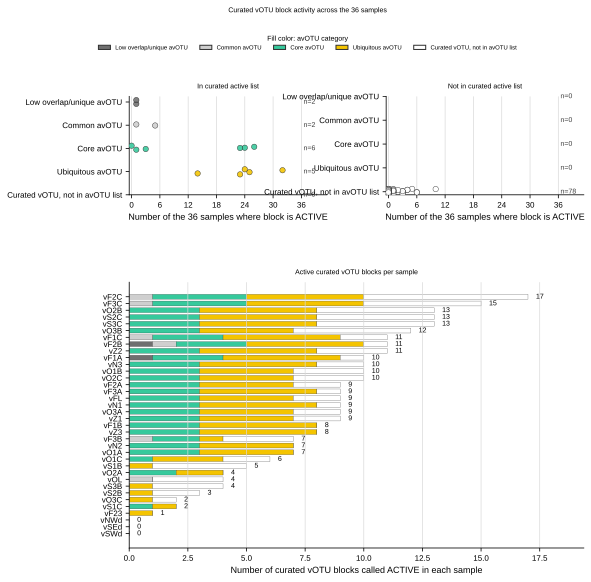

In [18]:
# Plot the selected vOTU-block activity summary
from IPython.display import SVG, display

display(SVG(filename=str(CURATED_VOTU_ACTIVITY_SUMMARY_PATH)))


## PropagAtE-Style vOTU Labels

09 selects one bacterial region per vOTU after the `>=100 kb` host-contig and
`<80%` geNomad viral-coverage filters, shared clustering, and direct reciprocal
95/85/85 support. Here, that exact selected region receives a PropagAtE-style
label from the 36 samples. A vOTU is `propagate_active` when its selected block is
ACTIVE in at least one sample.

The resulting table is the only activity-label input used in 11.


In [19]:
# Assign one PropagAtE-style label to every selected vOTU
# Write one explicit PropagAtE-style label for every vOTU selected by 09.
# The label table is the hand-off to 11; it does not use any earlier activity table.
PROPAGATE_VOTU_LABELS_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_propagate_votu_labels.csv'
PROPAGATE_VOTU_LABEL_SUMMARY_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_propagate_votu_label_summary.csv'
VOTU_RECORDS_OUTPUT_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_votu_records.csv'
VOTU_BLOCKS_OUTPUT_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_votu_blocks.csv'
VOTU_ACTIVITY_OUTPUT_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_votu_block_sample_activity.csv'

for required_path in [
    VOTU_BLOCKS_PATH,
    VOTU_RECORDS_OUTPUT_PATH,
    VOTU_BLOCKS_OUTPUT_PATH,
    VOTU_ACTIVITY_OUTPUT_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f'Missing required 09/10 activity-label input: {required_path}'
        )


def parse_boolean(series, name):
    parsed = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            'true': True, 't': True, '1': True, 'yes': True, 'y': True,
            'false': False, 'f': False, '0': False, 'no': False, 'n': False,
        })
    )
    if parsed.isna().any():
        examples = series.loc[parsed.isna()].head(5).tolist()
        raise ValueError(f'Could not parse {name} as boolean: {examples}')
    return parsed.astype(bool)


def activity_block_key(frame, active_column):
    return (
        frame['genome'].astype(str).str.strip()
        + '::' + frame['target_seq'].astype(str).str.strip()
        + '::' + pd.to_numeric(frame['block_start_1based'], errors='raise').astype(int).astype(str)
        + '-' + pd.to_numeric(frame['block_end_1based'], errors='raise').astype(int).astype(str)
        + '::' + np.where(frame[active_column].astype(bool), 'in_avotu_list', 'not_in_avotu_list')
    )


s02_selected = pd.read_csv(VOTU_BLOCKS_PATH)
records = pd.read_csv(VOTU_RECORDS_OUTPUT_PATH)
blocks = pd.read_csv(VOTU_BLOCKS_OUTPUT_PATH)
activity = pd.read_csv(VOTU_ACTIVITY_OUTPUT_PATH)

required_s02_columns = {'qseqid', 'sseqid', 'start', 'end'}
s02_length_column = next(
    (column for column in ['host_contig_length', 'sseqid_len', 'sequence_length']
     if column in s02_selected.columns),
    None,
)
s02_viral_fraction_column = next(
    (column for column in ['host_contig_geNomad_viral_fraction', 'geNomad_viral_fraction']
     if column in s02_selected.columns),
    None,
)
if s02_length_column is None or s02_viral_fraction_column is None:
    raise ValueError(
        '09 selected vOTU blocks must include host-contig length and merged '
        'geNomad viral-fraction columns.'
    )
s02_selected['host_contig_length'] = pd.to_numeric(
    s02_selected[s02_length_column], errors='raise'
)
s02_selected['host_contig_geNomad_viral_fraction'] = pd.to_numeric(
    s02_selected[s02_viral_fraction_column], errors='raise'
)

required_record_columns = {
    'qseqid', 'genome', 'sseqid', 'target_start_1based',
    'target_end_1based', 'source', 'is_active_votu',
}
required_block_columns = {
    'genome', 'target_seq', 'block_start_1based', 'block_end_1based',
    'source', 'is_active_votu',
}
required_activity_columns = {
    'genome', 'sample', 'target_seq', 'block_start_1based',
    'block_end_1based', 'source', 'is_active_votu_from_list', 'ACTIVE',
    'activity_status', 'block_mean_coverage', 'block_coverage_breadth',
    'fold_change_inside_vs_background', 'cohen_d_inside_vs_background',
}
for table_name, frame, required_columns in [
    ('09 selected vOTU blocks', s02_selected, required_s02_columns),
    ('10 vOTU records', records, required_record_columns),
    ('10 vOTU blocks', blocks, required_block_columns),
    ('10 vOTU block/sample activity', activity, required_activity_columns),
]:
    missing_columns = sorted(required_columns - set(frame.columns))
    if missing_columns:
        raise ValueError(f'{table_name} is missing required columns: {missing_columns}')

s02_selected['qseqid'] = s02_selected['qseqid'].astype(str).str.strip()
s02_selected['sseqid'] = s02_selected['sseqid'].astype(str).str.strip()
s02_selected['selected_start_1based'] = pd.to_numeric(
    s02_selected[['start', 'end']].min(axis=1), errors='raise'
).astype(int)
s02_selected['selected_end_1based'] = pd.to_numeric(
    s02_selected[['start', 'end']].max(axis=1), errors='raise'
).astype(int)
if s02_selected['qseqid'].duplicated().any():
    duplicates = s02_selected.loc[s02_selected['qseqid'].duplicated(), 'qseqid'].head(5).tolist()
    raise ValueError(f'09 must select one region per vOTU; duplicates: {duplicates}')
if (s02_selected['host_contig_length'] < MIN_REFERENCE_CONTIG_LENGTH).any():
    raise ValueError('An 09-selected vOTU region is on a host contig below the 100 kb filter.')
if (s02_selected['host_contig_geNomad_viral_fraction'] >= MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION).any():
    raise ValueError('An 09-selected vOTU region is on a host contig at or above 80% geNomad viral coverage.')

records = records.loc[records['source'].eq('curated_votu_block')].copy()
blocks = blocks.loc[blocks['source'].eq('curated_votu_block')].copy()
activity = activity.loc[
    activity['source'].eq('curated_votu_block') & activity['sample'].isin(SAMPLES_36)
].copy()
if records.empty or blocks.empty or activity.empty:
    raise ValueError('No curated 10 vOTU records, blocks, or activity rows were found.')

records['qseqid'] = records['qseqid'].astype(str).str.strip()
records['sseqid'] = records['sseqid'].astype(str).str.strip()
records['target_start_1based'] = pd.to_numeric(records['target_start_1based'], errors='raise').astype(int)
records['target_end_1based'] = pd.to_numeric(records['target_end_1based'], errors='raise').astype(int)
records['is_active_votu'] = parse_boolean(records['is_active_votu'], '10 record active-list membership')

blocks['target_seq'] = blocks['target_seq'].astype(str).str.strip()
blocks['is_active_votu'] = parse_boolean(blocks['is_active_votu'], '10 block active-list membership')
blocks['block_key'] = activity_block_key(blocks, 'is_active_votu')
if blocks['block_key'].duplicated().any():
    duplicates = blocks.loc[blocks['block_key'].duplicated(), 'block_key'].head(5).tolist()
    raise ValueError(f'10 curated display-block keys are not unique: {duplicates}')

activity['target_seq'] = activity['target_seq'].astype(str).str.strip()
activity['is_active_votu_from_list'] = parse_boolean(
    activity['is_active_votu_from_list'], '10 activity active-list membership'
)
activity['ACTIVE'] = parse_boolean(activity['ACTIVE'], '10 ACTIVE calls')
activity['block_key'] = activity_block_key(activity, 'is_active_votu_from_list')
if activity.duplicated(['block_key', 'sample']).any():
    raise ValueError('10 activity table has duplicate block/sample rows.')

observed_samples = activity.groupby('block_key')['sample'].agg(lambda values: set(values))
expected_samples = set(SAMPLES_36)
incomplete_blocks = observed_samples.loc[observed_samples.ne(expected_samples)]
if not incomplete_blocks.empty:
    raise ValueError(
        'Each curated 10 block must have one activity row for all 36 samples; '
        f'incomplete blocks include: {incomplete_blocks.index[:5].tolist()}'
    )

# First assign every selected 09 region to its exact 10 curated record.
records_for_join = records.rename(columns={
    'target_start_1based': 'selected_start_1based',
    'target_end_1based': 'selected_end_1based',
    'is_active_votu': 'in_avotu_list',
    'genome': 'record_genome',
})
record_columns = [
    'qseqid', 'sseqid', 'selected_start_1based', 'selected_end_1based',
    'record_genome', 'in_avotu_list', 'avotu_category', 'avotu_category_rank',
]
selected_records = s02_selected.merge(
    records_for_join[record_columns],
    on=['qseqid', 'sseqid', 'selected_start_1based', 'selected_end_1based'],
    how='left',
    validate='one_to_one',
)
if selected_records['record_genome'].isna().any():
    missing = selected_records.loc[selected_records['record_genome'].isna(), 'qseqid'].head(5).tolist()
    raise ValueError(f'09-selected vOTUs missing from 10 curated records: {missing}')
if not selected_records['genome'].eq(selected_records['record_genome']).all():
    mismatches = selected_records.loc[
        ~selected_records['genome'].eq(selected_records['record_genome']),
        ['qseqid', 'genome', 'record_genome'],
    ].head(5).to_dict('records')
    raise ValueError(f'09/10 genome assignments disagree: {mismatches}')

# Then assign that exact record to the display block that received the per-sample call.
block_matches = selected_records.merge(
    blocks[
        [
            'block_key', 'genome', 'target_seq', 'block_start_1based',
            'block_end_1based', 'is_active_votu',
        ]
    ],
    left_on=['genome', 'sseqid', 'in_avotu_list'],
    right_on=['genome', 'target_seq', 'is_active_votu'],
    how='left',
)
block_matches = block_matches.loc[
    (block_matches['selected_start_1based'] >= block_matches['block_start_1based'])
    & (block_matches['selected_end_1based'] <= block_matches['block_end_1based'])
].copy()
match_counts = block_matches.groupby('qseqid')['block_key'].nunique()
missing_matches = sorted(set(s02_selected['qseqid']) - set(match_counts.index))
ambiguous_matches = match_counts.loc[match_counts.ne(1)]
if missing_matches or not ambiguous_matches.empty:
    raise ValueError(
        'Every 09-selected vOTU must map to one 10 curated display block; '
        f'missing={missing_matches[:5]}, ambiguous={ambiguous_matches.head().to_dict()}'
    )
selected_to_block = selected_records.merge(
    block_matches[['qseqid', 'block_key']].drop_duplicates(),
    on='qseqid',
    how='inner',
    validate='one_to_one',
)

active_samples = (
    activity.loc[activity['ACTIVE']]
    .groupby('block_key')['sample']
    .agg(lambda values: ', '.join(sorted(values.astype(str))))
)
block_activity_summary = (
    activity.groupby('block_key', as_index=False)
    .agg(
        n_samples_evaluated=('sample', 'nunique'),
        n_samples_ACTIVE=('ACTIVE', 'sum'),
        n_samples_AMBIGUOUS=('activity_status', lambda values: values.eq('AMBIGUOUS').sum()),
        n_samples_DORMANT=('activity_status', lambda values: values.eq('DORMANT').sum()),
        n_samples_NOT_PRESENT=('activity_status', lambda values: values.eq('NOT_PRESENT').sum()),
        max_block_mean_coverage=('block_mean_coverage', 'max'),
        max_block_coverage_breadth=('block_coverage_breadth', 'max'),
        max_fold_change_inside_vs_background=('fold_change_inside_vs_background', 'max'),
        max_cohen_d_inside_vs_background=('cohen_d_inside_vs_background', 'max'),
    )
    .merge(active_samples.rename('ACTIVE_samples'), on='block_key', how='left')
)
block_activity_summary['ACTIVE_samples'] = block_activity_summary['ACTIVE_samples'].fillna('')

propagate_votu_labels = selected_to_block.merge(
    block_activity_summary,
    on='block_key',
    how='left',
    validate='many_to_one',
)
if propagate_votu_labels['n_samples_evaluated'].isna().any():
    missing = propagate_votu_labels.loc[
        propagate_votu_labels['n_samples_evaluated'].isna(), 'qseqid'
    ].head(5).tolist()
    raise ValueError(f'09-selected vOTUs missing 10 activity summaries: {missing}')
if not propagate_votu_labels['n_samples_evaluated'].eq(len(SAMPLES_36)).all():
    raise ValueError('At least one selected vOTU does not have 36 evaluated samples.')

propagate_votu_labels['propagate_active'] = propagate_votu_labels['n_samples_ACTIVE'].gt(0)
propagate_votu_labels['vOTU'] = propagate_votu_labels['qseqid']
propagate_votu_labels['activity_rule'] = (
    f'ACTIVE in >=1 of {len(SAMPLES_36)} samples: mean coverage >= '
    f'{VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE:g}, breadth >= '
    f'{VOTU_REGION_ACTIVE_MIN_BREADTH:.0%}, fold change >= '
    f'{VOTU_REGION_ACTIVE_MIN_FOLD_CHANGE:g}, Cohen d >= '
    f'{VOTU_REGION_ACTIVE_MIN_COHEN_D:g}'
)

first_columns = [
    'vOTU', 'qseqid', 'propagate_active', 'n_samples_ACTIVE', 'ACTIVE_samples',
    'n_samples_evaluated', 'n_samples_AMBIGUOUS', 'n_samples_DORMANT',
    'n_samples_NOT_PRESENT', 'genome', 'sseqid', 'selected_start_1based',
    'selected_end_1based', 'block_start_1based', 'block_end_1based',
    'in_avotu_list', 'avotu_category', 'avotu_category_rank',
    'host_contig_length', 'host_contig_geNomad_viral_fraction',
    'max_block_mean_coverage', 'max_block_coverage_breadth',
    'max_fold_change_inside_vs_background', 'max_cohen_d_inside_vs_background',
    'activity_rule',
]
first_columns = [column for column in first_columns if column in propagate_votu_labels.columns]
remaining_columns = [
    column for column in propagate_votu_labels.columns if column not in first_columns
]
propagate_votu_labels = (
    propagate_votu_labels[first_columns + remaining_columns]
    .sort_values(['propagate_active', 'n_samples_ACTIVE', 'vOTU'], ascending=[False, False, True])
    .reset_index(drop=True)
)
if propagate_votu_labels['vOTU'].duplicated().any() or len(propagate_votu_labels) != len(s02_selected):
    raise ValueError('The final Notebook 10 PropagAtE-style label table is not one row per 09-selected vOTU.')

propagate_votu_label_summary = (
    propagate_votu_labels
    .groupby(['propagate_active', 'in_avotu_list', 'avotu_category'], dropna=False, as_index=False)
    .agg(
        n_vOTUs=('vOTU', 'nunique'),
        median_ACTIVE_samples=('n_samples_ACTIVE', 'median'),
        max_ACTIVE_samples=('n_samples_ACTIVE', 'max'),
    )
    .sort_values(['propagate_active', 'avotu_category'], ascending=[False, True])
    .reset_index(drop=True)
)
propagate_votu_labels.to_csv(PROPAGATE_VOTU_LABELS_PATH, index=False)
propagate_votu_label_summary.to_csv(PROPAGATE_VOTU_LABEL_SUMMARY_PATH, index=False)

print(f'09-selected vOTUs labelled: {len(propagate_votu_labels)}')
print(f'PropagAtE-style active in >=1 sample: {int(propagate_votu_labels["propagate_active"].sum())}')
print(f'Saved PropagAtE-style label table: {PROPAGATE_VOTU_LABELS_PATH}')
print(f'Saved PropagAtE-style label summary: {PROPAGATE_VOTU_LABEL_SUMMARY_PATH}')


09-selected vOTUs labelled: 98
PropagAtE-style active in >=1 sample: 50
Saved PropagAtE-style label table: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_augmented_votu_blocks_top0_rpkm_plus_votu_block_genomes_propagate_votu_labels.csv
Saved PropagAtE-style label summary: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_augmented_votu_blocks_top0_rpkm_plus_votu_block_genomes_propagate_votu_label_summary.csv


In [20]:
# Display the PropagAtE-style label summary
display(propagate_votu_label_summary)
display(propagate_votu_labels.head(20))


,propagate_active,in_avotu_list,avotu_category,n_vOTUs,median_ACTIVE_samples,max_ACTIVE_samples
0,True,True,common,3,5.0,23
1,True,True,core,5,23.0,26
2,True,False,non_aVOTU,33,1.0,10
3,True,True,ubiquitous,7,24.0,32
4,True,True,unique,2,1.0,1
5,False,True,core,1,0.0,0
6,False,False,non_aVOTU,47,0.0,0


,vOTU,qseqid,propagate_active,n_samples_ACTIVE,ACTIVE_samples,n_samples_evaluated,n_samples_AMBIGUOUS,n_samples_DORMANT,n_samples_NOT_PRESENT,genome,...,max_host_genome_breadth,max_host_rpkm,total_host_read_count,n_host_samples,has_direct_pairwise_ani,direct_ani_support,contig_coverage_rank_within_vOTU,selection_rule,record_genome,block_key
0,E_aphidicola_Z9_3_pp3_cluster_15,E_aphidicola_Z9_3_pp3_cluster_15,True,32,"vF1A, vF1B, vF1C, vF23, vF2A, vF2B, vF2C, vF3A...",36,1,2,1,E_aphidicola_Z9_3,...,0.997794,42.200798,19053375.0,36,True,100.000000,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_Z9_3,E_aphidicola_Z9_3::E_aphidicola_Z9_3::2307249-...
1,E_aphidicola_N2_1_pp1_cluster_13,E_aphidicola_N2_1_pp1_cluster_13,True,26,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3B...",36,4,6,0,E_aphidicola_N2_3,...,0.994554,4.910838,4591065.0,36,True,99.980000,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_N2_3,E_aphidicola_N2_3::E_aphidicola_N2_3::1722203-...
2,E_aphidicola_Z9_3_pp1_cluster_4,E_aphidicola_Z9_3_pp1_cluster_4,True,25,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36,7,4,0,E_aphidicola_Z9_3,...,0.997794,42.200798,19053375.0,36,True,100.000000,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_Z9_3,E_aphidicola_Z9_3::E_aphidicola_Z9_3::1293869-...
3,E_aphidicola_B01_10_pp1_cluster_1,E_aphidicola_B01_10_pp1_cluster_1,True,24,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36,6,6,0,E_aphidicola_B03_2,...,0.997529,5.509296,5586583.0,36,True,99.790000,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_B03_2,E_aphidicola_B03_2::E_aphidicola_B03_2::126846...
4,E_aphidicola_B01_5_pp1_cluster_3,E_aphidicola_B01_5_pp1_cluster_3,True,24,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36,6,6,0,E_aphidicola_B03_2,...,0.997529,5.509296,5586583.0,36,True,92.889087,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_B03_2,E_aphidicola_B03_2::E_aphidicola_B03_2::126846...
5,E_aphidicola_B01_5_pp3_cluster_2,E_aphidicola_B01_5_pp3_cluster_2,True,24,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36,6,6,0,E_aphidicola_W04_1,...,0.997830,4.797286,3710925.0,36,True,99.980000,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_W04_1,E_aphidicola_W04_1::E_aphidicola_W04_1::268348...
6,E_aphidicola_W04_1_pp2_cluster_8,E_aphidicola_W04_1_pp2_cluster_8,True,23,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36,9,4,0,E_aphidicola_W04_1,...,0.997830,4.797286,3710925.0,36,True,100.000000,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_W04_1,E_aphidicola_W04_1::E_aphidicola_W04_1::317129...
7,vS2C_40_NODE_98_length_11292_cov_146.386402,vS2C_40_NODE_98_length_11292_cov_146.386402,True,23,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36,9,4,0,E_aphidicola_B03_6,...,0.990967,3.532745,3020670.0,36,True,99.110000,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_B03_6,E_aphidicola_B03_6::E_aphidicola_B03_6::268924...
8,vZ1_T_50_NODE_2_length_14615_cov_5.403365,vZ1_T_50_NODE_2_length_14615_cov_5.403365,True,23,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36,9,4,0,E_aphidicola_B03_6,...,0.990967,3.532745,3020670.0,36,True,97.691152,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_B03_6,E_aphidicola_B03_6::E_aphidicola_B03_6::268924...
9,E_aphidicola_W09_2_pp1_cluster_11,E_aphidicola_W09_2_pp1_cluster_11,True,14,"vF1A, vF1B, vF1C, vF2B, vF2C, vF3A, vF3C, vN1,...",36,16,6,0,E_aphidicola_W09_2,...,0.983347,2.517529,3427537.0,36,True,100.000000,1,"eligible host contig >= 100,000 bp with geNoma...",E_aphidicola_W09_2,E_aphidicola_W09_2::E_aphidicola_W09_2::133362...


## vOTU-Block Input Summary


In [21]:
# Summarize the vOTU-block input set
from IPython.display import display

s02_blocks = pd.read_csv(VOTU_BLOCKS_PATH)
s02_input_summary = pd.DataFrame([{
    'selected vOTU blocks': len(s02_blocks),
    'vOTUs': s02_blocks['qseqid'].nunique(),
    'bacterial reference genomes': s02_blocks['genome'].nunique(),
    'median maximum host breadth (%)': 100 * s02_blocks['max_host_genome_breadth'].median(),
}]).round(1)
display(s02_input_summary)
display(s02_blocks.head())


,selected vOTU blocks,vOTUs,bacterial reference genomes,median maximum host breadth (%)
0,98,98,71,89.5


,qseqid,sseqid_long,cluster_representative,cluster_member_count,selection_evidence,sseqid,start,end,len,n_source_vOTUs,...,total_contig_read_count,n_contig_samples_with_reads,max_host_genome_breadth,max_host_rpkm,total_host_read_count,n_host_samples,has_direct_pairwise_ani,direct_ani_support,contig_coverage_rank_within_vOTU,selection_rule
0,E_aphidicola_B01_10_pp1_cluster_1,E_aphidicola_B03_2_1308566_1353654,E_aphidicola_W11_1_1261082_1306180,10,full vOTU and bacterial region in the same vOT...,E_aphidicola_B03_2,1308566,1353654,45089,1,...,5586583.0,36,0.997529,5.509296,5586583.0,36,True,99.790000,1,"eligible host contig >= 100,000 bp with geNoma..."
1,E_aphidicola_B01_5_pp1_cluster_3,E_aphidicola_B03_2_1268464_1313081,E_aphidicola_B01_5_pp1_cluster_3,21,full vOTU and bacterial region in the same vOT...,E_aphidicola_B03_2,1268464,1313081,44618,1,...,5586583.0,36,0.997529,5.509296,5586583.0,36,True,92.889087,1,"eligible host contig >= 100,000 bp with geNoma..."
2,E_aphidicola_B01_5_pp3_cluster_2,E_aphidicola_W04_1_2683480_2724478,E_aphidicola_B01_5_pp3_cluster_2,33,full vOTU and bacterial region in the same vOT...,E_aphidicola_W04_1,2683480,2724478,40999,1,...,3710925.0,36,0.997830,4.797286,3710925.0,36,True,99.980000,1,"eligible host contig >= 100,000 bp with geNoma..."
3,E_aphidicola_B03_6_pp2_cluster_7,E_aphidicola_B03_6_4358997_4390622,E_aphidicola_B03_6_pp2_cluster_7,2,full vOTU and bacterial region in the same vOT...,E_aphidicola_B03_6,4358997,4390622,31626,1,...,3020670.0,36,0.990967,3.532745,3020670.0,36,True,100.000000,1,"eligible host contig >= 100,000 bp with geNoma..."
4,E_aphidicola_N2_1_pp1_cluster_13,E_aphidicola_N2_3_1722203_1762215,E_aphidicola_N2_3_1722203_1762215,4,full vOTU and bacterial region in the same vOT...,E_aphidicola_N2_3,1722203,1762215,40013,1,...,4591065.0,36,0.994554,4.910838,4591065.0,36,True,99.980000,1,"eligible host contig >= 100,000 bp with geNoma..."


## Ubiquitous avOTU Activity Table


In [22]:
# Summarize activity for all 13 ubiquitous avOTUs
# Targeted table for the 13 ubiquitous avOTUs, including block-negative cases.
prevalence = pd.read_csv(VOTU_PREVALENCE_METADATA_PATH)
prevalence_category_column = next(
    column for column in ["category", "prevalence_class"]
    if column in prevalence.columns
)
ubiquitous_votus = (
    prevalence.loc[
        prevalence[prevalence_category_column].astype(str).str.lower().eq("ubiquitous"),
        ["vOTU"],
    ]
    .drop_duplicates()
    .rename(columns={"vOTU": "vOTU"})
)

name_columns = [
    column for column in [
        "vOTU", "vOTU_number", "vOTU_name_final", "prophage",
        "widespread_name", "isolate_host_genus",
    ] if column in pd.read_csv(VOTU_METADATA_PATH, nrows=0).columns
]
votu_names = pd.read_csv(VOTU_METADATA_PATH, usecols=name_columns, low_memory=False)
votu_names = votu_names.drop_duplicates("vOTU")

label_columns = [
    column for column in [
        "vOTU", "propagate_active", "n_samples_ACTIVE", "ACTIVE_samples",
        "n_samples_evaluated", "n_samples_AMBIGUOUS", "n_samples_DORMANT",
        "n_samples_NOT_PRESENT", "genome", "sseqid",
        "selected_start_1based", "selected_end_1based", "reference_origin",
        "max_host_genome_breadth", "max_contig_breadth",
        "max_block_mean_coverage", "max_block_coverage_breadth",
        "max_fold_change_inside_vs_background", "max_cohen_d_inside_vs_background",
    ] if column in propagate_votu_labels.columns
]
ubiquitous_votu_activity = (
    ubiquitous_votus
    .merge(votu_names, on="vOTU", how="left", validate="one_to_one")
    .merge(
        propagate_votu_labels[label_columns],
        on="vOTU",
        how="left",
        validate="one_to_one",
    )
)
ubiquitous_votu_activity["block_found"] = ubiquitous_votu_activity["sseqid"].notna()
ubiquitous_votu_activity["n_samples_present"] = (
    ubiquitous_votu_activity.get("n_samples_evaluated", 0).fillna(0)
    - ubiquitous_votu_activity.get("n_samples_NOT_PRESENT", 0).fillna(0)
).astype(int)
ubiquitous_votu_activity["is_Erwinia_associated"] = (
    ubiquitous_votu_activity.get("isolate_host_genus", pd.Series(index=ubiquitous_votu_activity.index, dtype=object))
    .fillna("").astype(str).eq("Erwinia")
    | ubiquitous_votu_activity.get("genome", pd.Series(index=ubiquitous_votu_activity.index, dtype=object))
    .fillna("").astype(str).str.match(r"^(E_|Erwinia_)")
)
ubiquitous_votu_activity = ubiquitous_votu_activity.sort_values(
    ["is_Erwinia_associated", "block_found", "n_samples_ACTIVE", "vOTU"],
    ascending=[False, False, False, True],
    kind="stable",
).reset_index(drop=True)

UBIQUITOUS_VOTU_ACTIVITY_PATH = (
    OUTPUT_DIR / f"{OUTPUT_PREFIX}_ubiquitous_vOTU_activity_summary.csv"
)
ubiquitous_votu_activity.to_csv(UBIQUITOUS_VOTU_ACTIVITY_PATH, index=False)
print(
    f"Ubiquitous avOTUs: {len(ubiquitous_votu_activity)}; "
    f"blocks found: {int(ubiquitous_votu_activity['block_found'].sum())}; "
    f"Erwinia-associated: {int(ubiquitous_votu_activity['is_Erwinia_associated'].sum())}"
)
print(f"Saved ubiquitous-vOTU activity table: {UBIQUITOUS_VOTU_ACTIVITY_PATH}")
display(ubiquitous_votu_activity)


Ubiquitous avOTUs: 13; blocks found: 7; Erwinia-associated: 7
Saved ubiquitous-vOTU activity table: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_augmented_votu_blocks_top0_rpkm_plus_votu_block_genomes_ubiquitous_vOTU_activity_summary.csv


,vOTU,vOTU_number,vOTU_name_final,prophage,widespread_name,isolate_host_genus,propagate_active,n_samples_ACTIVE,ACTIVE_samples,n_samples_evaluated,...,reference_origin,max_host_genome_breadth,max_contig_breadth,max_block_mean_coverage,max_block_coverage_breadth,max_fold_change_inside_vs_background,max_cohen_d_inside_vs_background,block_found,n_samples_present,is_Erwinia_associated
0,E_aphidicola_Z9_3_pp3_cluster_15,vOTU_0002,Erwinia virus Trolltunga,E_aphidicola_Z9_3_pp3,Erwinia virus Trolltunga,Erwinia,True,32.0,"vF1A, vF1B, vF1C, vF23, vF2A, vF2B, vF2C, vF3A...",36.0,...,source_isolate_added,0.997794,0.997794,21683.706584,1.00000,1.218803e+05,25.594459,True,35,True
1,E_aphidicola_Z9_3_pp1_cluster_4,vOTU_0014,Erwinia virus Skarstind,E_aphidicola_Z9_3_pp1,Erwinia virus Skarstind,Erwinia,True,25.0,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36.0,...,source_isolate_added,0.997794,0.997794,2039.392736,1.00000,7.784278e+03,27.395926,True,36,True
2,E_aphidicola_B01_10_pp1_cluster_1,vOTU_0013,Erwinia virus Galdhoepiggen,E_aphidicola_B01_10_pp1,Erwinia virus Galdhoepiggen,Erwinia,True,24.0,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36.0,...,source_isolate_added,0.997529,0.997529,638.018007,1.00000,5.525316e+03,18.010013,True,36,True
3,E_aphidicola_B01_5_pp1_cluster_3,vOTU_0551,Erwinia virus Glittertind,E_aphidicola_B01_5_pp1,Erwinia virus Glittertind,Erwinia,True,24.0,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36.0,...,source_isolate_added,0.997529,0.997529,638.018007,1.00000,5.525316e+03,18.010013,True,36,True
4,E_aphidicola_W04_1_pp2_cluster_8,vOTU_0068,Erwinia virus Jervasstind,E_aphidicola_W04_1_pp2,Erwinia virus Jervasstind,Erwinia,True,23.0,"vF1A, vF1B, vF1C, vF2A, vF2B, vF2C, vF3A, vF3C...",36.0,...,source_isolate_added,0.997830,0.997830,389.453732,1.00000,1.042035e+11,17.017494,True,36,True
5,E_aphidicola_W09_2_pp1_cluster_11,vOTU_0103,Erwinia virus Rondeslottet,E_aphidicola_W09_2_pp1,Erwinia virus Rondeslottet,Erwinia,True,14.0,"vF1A, vF1B, vF1C, vF2B, vF2C, vF3A, vF3C, vN1,...",36.0,...,source_isolate_added,0.983347,0.983347,332.207674,0.99935,2.903699e+03,7.227566,True,36,True
6,E_aphidicola_W09_5_pp2_cluster_12,vOTU_0072,Erwinia virus Gaustatoppen,E_aphidicola_W09_5_pp2,Erwinia virus Gaustatoppen,Erwinia,True,14.0,"vF1A, vF1B, vF1C, vF2B, vF2C, vF3A, vF3C, vN1,...",36.0,...,source_isolate_added,0.983347,0.983347,332.207674,0.99935,2.903699e+03,7.227566,True,36,True
7,APSE_wheat,vOTU_0001,APSE_wheat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0,False
8,vN2_10_NODE_2_length_39732_cov_172.456511,vOTU_0003,vOTU_0003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0,False
9,vO2C_NODE_54_length_77920_cov_109.386798,vOTU_0030,vOTU_0030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0,False
